# Loading Historic NBI Values

In [1]:
import pandas as pd
import math

test_bridge_sfn = "2701464"

NBI_df = pd.read_csv(
    r"C:\Users\dparks1\PycharmProjects\civilpy-legacy\res\2022AllRecordsDelimitedAllStates.txt",
    low_memory=False,
)

ohio_bridges = NBI_df[NBI_df["STATE_CODE_001"] == 39]
first_bridge_NBI = ohio_bridges[
    ohio_bridges["STRUCTURE_NUMBER_008"] == test_bridge_sfn.rjust(15, " ")
]

In [2]:
from civilpy.state.ohio.DOT.TIMS import TIMSBridge

first_bridge = TIMSBridge(int(test_bridge_sfn))
first_bridge

<TIMSBridge SFN: '2701464'>
  Route Carried: US 35-SILVER MEMOR
  NLFID:         SGALUS00035**C
  Location:      GAL County, District 10
  Location Map:  https://www.google.com/maps?q=38.835555,-82.148911

  -- Characteristics --
  Lanes On:      4
  Year Built:    1969
  Material/Type: Steel / Truss - Thru (3/10) (Main Span)

  -- Condition Ratings --
  Sufficiency:   066.0
  Deck:          7
  Superstructure:5
  Substructure:  7

For a full list of available attributes, use help(TIMSBridge).

# Description of Notebook

The above code imports the civilpy package for use in exploring bridge objects. The list of test bridges are randomly selected for testing functions throughout, but any bridge can be specified by changing the SFN used to initate the `first_bridge` object above. Each function ideally takes in the old value and returns an updated, converted value if possible. Sections are defined by their SNBI ID and Item Name. For data types, AN means "AlphaNumeric".

## Comprehensive Example

[From FHWA](https://www.fhwa.dot.gov/bridge/snbi/snbi_march_2022_publication.pdf)

These specifications include a comprehensive example to illustrate the proper recording of data items as well as the relationship between data items in each subsection and the full set of data required for a bridge.  The bridge in the comprehensive example is Bridge Number 15558X in St. Louis County, Missouri.  The characteristics of this bridge serve to illustrate the relational nature of the data collected for many of the subsections; the bridge crosses several features of differing types (waterway, highway, and railroad), is comprised of several material and structure types, and is posted for various vehicle loads.  When possible, inventory information for this bridge is taken from existing inventory data for Missouri Bridge Number 15558, but with modifications made as necessary for illustrative purposes.
<center>
    <img src='img/image5_1.png'><br>
    Figure 2. Elevation view of Bridge Number 15558X, looking east.</figcaption>
</center>


<center>
    <img src='img/fig_3.png'><br>
    Figure 3. Plan view of Bridge Number 15558X.
</center>

<center>
    <img src='img/image6_1.png'><br>
    Figure 4. Approach view to Bridge Number 15558X, looking south.
</center>

<center>
    <img src='img/fig_5.png'><br>
    Figure 5. Typical section views for Bridge Number 15558X.
</center>

The end of each subsection presents relevant background information and a completed table of the data items in that subsection for Bridge Number 15558X.  Appendix A presents the complete data set for the 
bridge.

## Quantification of Effort

There are 7 sections broken down further into numerous sub-sections.

To visualize the amount of effort, here is a breakdown of the sections and  
components. They are colored by whether the transition from the existing  
format is Clean "C", Partially "C", or Difficult "D".

Each section of the notebook includes a color coded transition difficulty

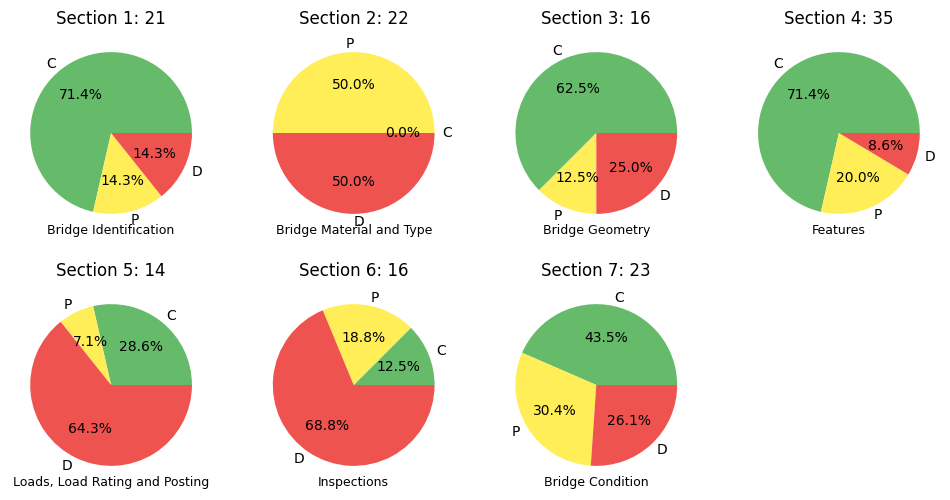

In [3]:
from civilpy.transportation.FHWA.snbi import snbi_data_crosswalk

The difficulty in updating each field ranges from reformating a value to  
load rating a bridge.

In [4]:
from civilpy.state.ohio.DOT.legacy import TimsBridge

test_bridge_list = ["2701464", "6500609", "7704232"]
leading_zeros_user_input = 0  # Affects multiple conversions (BID01, BID03, ...)
state_user_input = "Ohio"

# first_bridge = TimsBridge(int(test_bridge_sfn))

# Retrieving Values from Assetwise


In [5]:
from civilpy.state.ohio.DOT.AssetWise import (
    get_bridge_by_sfn,
    get_elements_for_asset,
    get_all_approved_inspections,
    get_all_odot_snbi_data,
    format_assetwise_output,
    get_asset_cover_image,
    base_url, username, password, aw_fields
)

import re
import requests
from requests.auth import HTTPBasicAuth
from types import SimpleNamespace
from typing import Dict, Union, List, Optional
from IPython.display import Image as IPImage, display

In [6]:
class AssetWiseBridge:
    def __init__(self, sfn: str):
        self.sfn = sfn

        # Fetch Core Asset Identity
        raw_data = get_bridge_by_sfn(sfn, include_coordinates=True)
        if not raw_data:
            raise ValueError(f"No AssetWise asset found for SFN '{sfn}'")

        # Dynamically assign core attributes, converting dicts to SimpleNamespace where possible
        for key, value in raw_data.items():
            if isinstance(value, dict):
                try:
                    value = SimpleNamespace(**value)
                except TypeError:
                    pass
            setattr(self, key, value)

        # Initialize placeholders
        self._elements = None
        self._inspections = None
        self._snbi_data = None
        self._decoded_attributes = None

    @property
    def attributes(self) -> Dict[str, Union[str, int, float]]:
        """Lazy-loads and maps 'fe_id' to human-readable names."""
        if self._decoded_attributes is None:
            self._decoded_attributes = self._fetch_and_decode_values()
        return self._decoded_attributes

    @property
    def elements(self) -> List[Dict]:
        if self._elements is None:
            self._elements = get_elements_for_asset(base_url, username, password, self.as_id)
        return self._elements

    @property
    def inspections(self) -> List[Dict]:
        if self._inspections is None:
            self._inspections = get_all_approved_inspections(self.as_id)
        return self._inspections

    @property
    def snbi_data(self) -> Dict[str, Optional[str]]:
        """Returns a flattened dictionary keyed by SNBI label."""
        if self._snbi_data is None:
            raw = get_all_odot_snbi_data(self.as_id)
            # Flatten the nested list-of-dicts structure into a single K:V dict
            self._snbi_data = {
                entry['label']: entry.get('value')
                for entries in format_assetwise_output(raw).values()
                for entry in entries if entry.get('label')
            }
            
            # Inject defaults if missing from report
            defaults = {
                'B.ID.01: Bridge Number': self.sfn,
                'B.ID.02: Bridge Name': getattr(self, 'as_name', None),
                'NBI 009: Location': getattr(self, 'location', None)
            }
            for k, v in defaults.items():
                if k not in self._snbi_data and v: self._snbi_data[k] = v

        return self._snbi_data

    def _fetch_and_decode_values(self) -> Dict[str, Union[str, int, float]]:
        """Internal helper to fetch and map CurrentValues."""
        api_url = f"{base_url}/api/CurrentValue/GetCurrentValuesByAssetId/{self.as_id}"
        try:
            response = requests.get(api_url, auth=HTTPBasicAuth(username, password))
            response.raise_for_status()
            raw_rows = response.json().get('data', [])
        except Exception as e:
            print(f"Error fetching attributes: {e}")
            return {}

        decoded_data = {}
        for row in raw_rows:
            fid = row.get('fe_id')
            if not fid: continue

            val = row.get('cv_plain_text') or row.get('cv_value')
            if not val: continue

            # Map ID to Name
            field_name = aw_fields.get(str(fid), f"Field_{fid}")
            decoded_data[field_name] = val
            
        return decoded_data

    def find(self, pattern: str) -> Dict[str, Union[str, int, float]]:
        """Search keys in SNBI Data and Attributes using regex."""
        combined = {**self.snbi_data, **self.attributes}
        return {k: v for k, v in combined.items() if re.search(pattern, str(k), re.IGNORECASE)}

    def get_cover_photo(self, display_photo: bool = True):
        try:
            img = get_asset_cover_image(self.as_id)
            if img and display_photo and IPImage: display(IPImage(data=img))
            return img
        except Exception: return None

    def __repr__(self) -> str:
        return f"<AssetWiseBridge SFN: '{self.sfn}' ID: {getattr(self, 'as_id', '?')}>"

In [7]:
bridge_object = AssetWiseBridge(test_bridge_sfn)

<div style="page-break-after: always;"></div>

# In-Depth Descriptions of Fields

# Section 1: Bridge Identification

This section has data items that have been grouped by the following three  
subsections: Identification, Location, and Classification.  The data items  
in these subsections identify, locate, and classify bridges and are  
considered part of the Primary Data Set.  These data items have a  
one-to-one relationship with a bridge.  The data for these items typically  
remain static once a bridge has been inventoried.

The following data items are included in this section.

SUBSECTION 1.1: IDENTIFICATION 

| Item ID | Data Item                                                   |
|:-------:|:-----------------------------------------------------------:|
| B.ID.01 | [Bridge Number](#B.ID.01---Bridge-Number)                   |
| B.ID.02 | [Bridge Name](#B.ID.02---Bridge-Name)                       |
| B.ID.03 | [Previous Bridge Number](#B.ID.03---Previous-Bridge-Number) |

SUBSECTION 1.2: LOCATION 

| Item ID | Data Item                                                                                     |
|:-------:|:---------------------------------------------------------------------------------------------:|
| B.L.01  | [State Code](#B.L.01---State-Code)                                                            |
| B.L.02  | [County Code](#B.L.02---County-Code)                                                          |
| B.L.03  | [Place Code](#B.L.03---Place-Code)                                                            |
| B.L.04  | [Highway Agency District](#B.L.04---Highway-Agency-District)                                  |
| B.L.05  | [Latitude](#B.L.05---Latitude)                                                                |
| B.L.06  | [Longitude](#B.L.06---Longitude)                                                              |
| B.L.07  | [Border Bridge Number](#B.L.07---Border-Bridge-Number)                                        |
| B.L.08  | [Border Bridge State or Country Code](#B.L.08---Border-Bridge-State-or-Country-Code)          |
| B.L.09  | [Border Bridge Inspection Responsibility](#B.L.09---Border-Bridge-Inspection-Responsibility)  |
| B.L.10  | [Border Bridge Designated Lead State](#B.L.10---Border-Bridge-Designated-Lead-State)          |
| B.L.11  | [Bridge Location](#B.L.11---Bridge-Location)                                                  |
| B.L.12  | [Metropolitan Planning Organization](#B.L.12---Metropolitan-Planning-Organization)            |

SUBSECTION 1.3: CLASSIFICATION 

| Item ID | Data Item                                                                       |
|:-------:|:-------------------------------------------------------------------------------:|
| B.CL.01 | [Owner](#B.CL.01---Owner)                                                       |
| B.CL.02 | [Maintenance Responsibility](#B.CL.02---Maintenance-Responsibility)             |
| B.CL.03 | [Federal or Tribal Land Access](#B.CL.03--Federal-or-Tribal-Land-Access)        |
| B.CL.04 | [Historic Significance](#B.CL.04--Historic-Significance)                        |
| B.CL.05 | [Toll](#B.CL.05---Toll)                                                         |
| B.CL.06 | [Emergency Evacuation Designation](#B.CL.06---Emergency-Evacuation-Designation) |

## Subsection 1.1: Bridge Identification

The data items in this subsection uniquely identify the bridge and are considered part of the Primary Data Set.  These data items have a one-to-one relationship with a bridge.  The data for these items 
typically remain static once a bridge has been inventoried.   

The following data items are included in this subsection.

| Item ID | Data Item |
|:--:|:--:|
| B.ID.01 | Bridge Number  |
| B.ID.02 | Bridge Name |
| B.ID.03 | Previous Bridge Number |

<a id='B.ID.01'></a>


### B.ID.01 - Bridge Number

<div class="alert alert-block alert-success">
<b>Clean</b> 
</div>

Format: AN (15)

|  SNBI Format |  1995 Format |  Comments                      |
|:------------:|:------------:|:------------------------------:|
| AN (15)      |  AN (15)     | Trim leading and trailing spaces.  For Transition Tool, provide option to trim or not trim leading zeroes, or to trim all but one leading zero; do not provide a default selection.  Ask user whether to apply this selection to transitioned legacy (historical) data for that State/Agency.  (Add a note stating that all legacy data will also be preserved in its original form.)  For those who do not use the Transition Tool, we will need to survey. |

**Specification**:

Report the unique bridge number assigned according to agency policy for each bridge meeting the NBIS bridge definition that is fully or partially located within the State’s boundaries, Federal agency’s responsibility or jurisdiction, or Tribal government’s responsibility or jurisdiction; regardless of inspection or financial responsibility.Do not change the bridge number once it has been assigned and recorded, except for a rare or unusual circumstance that requires a onetime change.When a bridge number is changed, report the previous bridge number under B.ID.03. Report all spans from abutment to abutment as one bridge.

**Commentary**:

There are no national policies established for assigning unique bridge numbers. Therefore, each State transportation department, Federal agency, or Tribal government develops policy for assigning unique bridge numbers.It is preferable that a new and unique bridge number be assigned when a bridge is replaced. When any portion of the existing bridge is retained for a rehabilitated or partially replaced bridge, it is preferable to retain the existing bridge number. It is expected that all spans of a superstructure spanning from one abutment to another be recorded as one bridge, per the NBIS bridge definition, not as multiple bridges.

For border bridges, the Neighboring State reports this item as part of their abbreviated bridge record. For more information, see the Border Bridges section of this document.It is preferable that one bridge number be assigned to a bridge that supports multiple features.It is preferable that any bridge or bridges with a closed median, where the area between the two roadways on the bridge is bridged over and can support traffic, be reported as one bridge. Closed medians may have either mountable or non-mountable curbs or barriers. It is preferable that separate superstructures with an open median (not meeting the closed median criteria above) sharing a common substructure unit or units be reported as two bridges.It is preferable that separate bridge numbers be reported for each mainline bridge and the ramp that connects to the mainline bridge, when the ramp has at least one distinct abutment and is greater than 20 feet in length. It is also preferable that separate bridge numbers be reported for a bridge that divides into two or more separate bridges, or two or more bridges that merge into one single bridge. In both cases, the separating point between bridges should be the closest deck joint, or substructure unit to the separating point, or other logical and reasonable location as determined by the bridge owner.Double deck bridges may be reported as one or two bridges. However, all related data items need to be compatible with the method selected.Consult with the local FHWA division office contact for questions concerning assigning bridge numbers to unique or complex bridges.

In [8]:
# Example of how to find a code with built in regex
bridge_object.find(r'^B\.ID\.01')

--- Starting Dynamic SNBI Data Discovery for Asset 22989 ---
--- Discovery Complete. Retrieved 4 forms. ---


{'B.ID.01: Bridge Number': '2701464',
 'B.ID.01.01': '09/24/2012',
 'B.ID.01.03 Date Built': '07/01/1969',
 'B.ID.01.04 Date Open to Traffic': '07/01/1969'}

In [9]:
# Current Value in Assetwise;
bridge_object.snbi_data['B.ID.01: Bridge Number']

'2701464'

In [10]:
bridge_object.attributes['B.ID.01: Bridge Number']

'2701464'

In [11]:
# name_length = (
#     len(str(first_bridge.sfn)) + 1
# )  # Gets the length of the original bridge id

# print(f'Former NBI value: [{first_bridge_NBI["STRUCTURE_NUMBER_008"].iloc[0]}]')


# def bridge_number_conversion(bridge_number: int, leading_zeros: int = 0):
#     """
#     Takes in a bridge number and config value:

#     0 - Do not Pad (default)
#     1 - Pad number w/ single zero?
#     2 - Pad w/ 0s to 15

#     returns converted value
#     """

#     if leading_zeros == 0:
#         updated_value = f"{bridge_number}"
#     elif leading_zeros == 1:
#         updated_value = f"{str(bridge_number).zfill(name_length)}"
#     elif leading_zeros == 2:
#         updated_value = f"{str(bridge_number).zfill(15)}"

#     return updated_value


# print(
#     f"Converted  value: [{bridge_number_conversion(first_bridge.sfn, leading_zeros_user_input)}]"
# )

`# //TODO - Assetwise currently stores multiple values labeled as being for B.ID`

    AssetWise Field ID: B.ID.01
    MULTIPLE FIELDS FOUND!!!!!
      Description: (2300001, 'B.ID.01: Bridge Number')
      Description: (6000734, 'B.ID.01.02 New SFN Replacing the Retired Bridge')
      Description: (6000736, 'B.ID.01.06 SFN Retiring Reason')
      Description: (6000737, 'B.ID.01.01')
      Description: (6000738, 'B.ID.01.06 SFN Retire Date')
      Description: (6000740, 'B.ID.01.03 Date Built')
      Description: (6001230, 'B.ID.01.04 Date Open to Traffic')

### B.ID.02 - Bridge Name

<div class="alert alert-block alert-danger">
<b>No Current Eqv.</b> 
</div>

|  SNBI Format |  1995 Format |  Comments                      |
|:------------:|:------------:|:------------------------------:|
| AN (300)      |  N/A        |   New Value                    |

**Specification**:

Report the commonly known name(s) for the bridge.  For more than one name, report all names with the most common (Ohio = CTY-RTE-SEC) name first. 
 
Report multiple names separated by pipe (|) delimiters.

**Commentary**:

There are no national policies established for assigning unique bridge names.  Therefore, each State transportation department, Federal agency, or Tribal government develops their own policy for assigning unique bridge names.  
 
If the bridge has no commonly known name, it is optional to report this item, but it is preferable to enter a general description.

**Examples**:

Bridge Number A4231 has a commonly known name of O’Donnell Memorial Bridge.  Report O’Donnell Memorial Bridge. 
 
Bridge Number 8675S that carries SR 15 over Goose Creek has a commonly known name of Goose Creek Bridge.  Report Goose Creek Bridge. 
 
Bridge Number 3555C that carries Harlem Avenue over I-80 is commonly known by the names Harlem Bridge and State Route 43 Bridge.  Report Harlem Bridge|State Route 43 Bridge. 

In [12]:
bridge_object.find(r'^B\.ID\.02')

{'B.ID.02: Bridge Name': 'GAL-00035-1787 | SILVER MEMORIAL BRIDGE'}

In [13]:
# Current Value in Assetwise;
bridge_object.snbi_data['B.ID.02: Bridge Name']

'GAL-00035-1787 _(2701464)'

<a id='B.ID.03'></a>

### B.ID.03 - Previous Bridge Number

<div class="alert alert-block alert-success">
<b>Clean</b> 
</div>

|  SNBI Format |  1995 Format |  Comments                      |
|:------------:|:------------:|:------------------------------:|
| AN (15)      |  AN (15)     | Populate this field using the history of structure number changes that resides in the NBI from Structure Number Change submittals.  Trim leading and trailing spaces and leading zeroes in accordance with the user's selection for Item B.ID.01 |

//TODO - Depends on structure change submittal histories, not sure where existing values are kept.

**Specification**

Report the bridge number previously associated with the bridge that has been replaced by the inventoried bridge, or when the inventoried bridge number has changed. 
 
Report 0 if no previous bridge number.

**Commentary**

The purpose of this item is to retain a link to data for previous bridge numbers associated with this bridge in the NBI. 
 
For border bridges, the Neighboring State reports this item as part of their abbreviated bridge record.  For more information, see the Border Bridges section of this document.

//TODO - Add Hyperlink to "Border Bridges" Section

**Examples**

Bridge Number 024657 is constructed adjacent to Bridge Number 000123 as a planned replacement project.  When the roadway is connected to the new bridge and it is opened, Bridge Number 000123 is closed and demolished.  Report 000123. 
 
Separate parallel bridges with unique bridge numbers (Bridge Number 234 and Bridge Number 567) are reconstructed to form one bridge.  The reconstructed bridge is inventoried as Bridge Number 234.  Report 567.

<center><img src='img/image12_1.png'><br>
Figure 6.  Elevation view of the North Hanley Road Bridge, looking east. 
</center>

The North Hanley Road Bridge has been assigned Bridge Number 15558X by the State.  There was no 
previous bridge for this crossing. 
 
Table 1.  Identification data items in the Primary Data Set for Bridge Number 15558X. 
| Item ID | Data Item       | Value                    |
|:-------:|:---------------:|:------------------------:|
| B.ID.01 | Bridge Number   | 15558X                   |
| B.ID.02 | Bridge Name     | North Hanley Road Bridge |
| B.ID.03 | Previous Bridge | Number 0                 |

In [14]:
bridge_object.find(r'^B\.ID\.03')

{}

<div style="page-break-after: always;"></div>

## Subsection 1.2: Location

The data items in this subsection uniquely locate the bridge and are considered part of the Primary Data Set.  These data items have a one-to-one relationship with a bridge.  The data for these items typically remain static once a bridge has been inventoried.

The following data items are included in this subsection.

| Item ID |  Data Item |
|:-------:|:----------:|
| B.L.01  | State Code |
| B.L.02  | County Code |
| B.L.03  | Place Code |
| B.L.04  | Highway Agency District |
| B.L.05  | Latitude |
| B.L.06  | Longitude |
| B.L.07  | Border Bridge Number |
| B.L.08  | Border Bridge State or Country Code |
| B.L.09  | Border Bridge Inspection Responsibility  |
| B.L.10  | Border Bridge Designated Lead State |
| B.L.11  | Bridge Location |
| B.L.12  | Metropolitan Planning Organization|

### B.L.01 - State Code

<div class="alert alert-block alert-success">
<b>Clean</b> 
</div>

|  SNBI Format |  1995 Format |  Comments                      |
|:------------:|:------------:|:------------------------------:|
| N (2, 0)     |  3/N         | Trim leading zero, drop 3rd digit |

**Specification**

Report the State code where the bridge is located using one of the codes listed below.

Code Description Code Description Code Description 

|                    |     State Codes                      |                                                 |
|:------------------:|:------------------------------------:|:-----------------------------------------------:|
| 1  - Alabama       | 54 - West Virginia                   | 38 - North Dakota                               |
| 25 - Massachusetts | 10 - Delaware                        | 69 Commonwealth of the Northern Mariana Islands |
| 47 - Tennessee     | 32 - Nevada                          | 18 Indiana                                      |
| 2  - Alaska        | 55 - Wisconsin                       | 39 Ohio                                         |
| 26 - Michigan      | 11 - District of Columbia            | 70 Palau                                        |
| 48 - Texas         | 33 - New Hampshire                   | 19 Iowa                                         |
| 4  - Arizona       | 56 - Wyoming                         | 40 Oklahoma                                     |
| 27 - Minnesota     | 12 - Florida                         | 72 Puerto Rico                                  |
| 49 - Utah          | 34 - New Jersey                      | 20 Kansas                                       |
| 5  - Arkansas      | 60 - American Samoa                  | 41 Oregon                                       |
| 28 - Mississippi   | 13 - Georgia                         | 74 U.S. Minor Outlying Islands                  |
| 50 - Vermont       | 35 - New Mexico                      | 21 Kentucky                                     |
| 6  - California    | 64 - Federated States of Micronesia  | 42 Pennsylvania                                 |
| 29 - Missouri      | 15 - Hawaii                          | 78 U.S. Virgin Islands                          |
| 51 - Virginia      | 36 - New York                        | 22 Louisiana                                    |
| 8  - Colorado      | 66 - Guam                            | 44 Rhode Island                                 |
| 30 - Montana       | 16 - Idaho                           | 23 Maine                                        |
| 53 - Washington    | 37 - North Carolina                  | 45 South Carolina                               |
| 9  - Connecticut   | 68 - Marshall Islands                | 24 Maryland                                     |
| 31 - Nebraska      | 17 - Illinois                        | 46 South Dakota                                 |

**Commentary**

State codes are derived from the FIPS, Standard Codes for States (FIPS PUB 5-2). Federal agency or Tribal governments that own bridges which cross State borders need to choose a State code to report here and the bordering State’s code in Item B.L.08 (Border Bridge State or Country Code). For border bridges, the Neighboring State reports this item as part of their abbreviated bridge record.  For more information, see the Border Bridges section of this document.

In [15]:
bridge_object.find(r'^B\.L\.01')

{'B.L.01: State Code': '39'}

In [16]:
from civilpy.state.ohio.DOT.legacy import NBIS_state_codes

print(f'Former NBI value: [{first_bridge_NBI["STATE_CODE_001"].iloc[0]}]')


def get_3_digit_st_cd_from_2(code):
    for key, value in NBIS_state_codes.items():
        if key[:-1] == str(code):
            return key
        else:
            pass


def state_code_conversion(code):
    """
    Takes in a bridge number, returns converted state code from index lookup

    returns converted value, since this is written for Ohio, 39
    """
    if len(str(code)) == 2:
        state_code = NBIS_state_codes[get_3_digit_st_cd_from_2(code)]
    else:
        state_code = NBIS_state_codes[code]

    return state_code


print(
    f'Converted  value: [{state_code_conversion(get_3_digit_st_cd_from_2(first_bridge_NBI["STATE_CODE_001"].iloc[0]))}]'
)

# note -Bentley database doesn't seem to have a 'state' field

Former NBI value: [39]
Converted  value: [Ohio]


### B.L.02 - County Code

<div class="alert alert-block alert-success">
<b>Clean</b> 
</div>

|  SNBI Format |  1995 Format |  Comments                      |
|:------------:|:------------:|:------------------------------:|
| N (3,0)      |  3/N         |  Direct Transition             |

**Specification**

Report the FIPS code for the county, parish, or borough in which the bridge is located. 

**Commentary**

Use the FIPS codes in the current version of the Census of Population and Housing - Geographic Identification Code Scheme to determine the appropriate code. 
 
County and county equivalent entity codes can be found through a link at the following web site: 
http://www.fhwa.dot.gov/bridge/nbi.cfm

For border bridges, the Neighboring State reports this item as part of their abbreviated bridge record.  For more information, see the Border Bridges section of this document.

**Examples**

Lincoln County, Nebraska, code 111.  Report 111.   
Queens, New York, code 81.  Report 81.   
Orleans Parish, Louisiana, code 71.  Report 71.  

In [17]:
bridge_object.find(r'^B\.L\.02')

{'B.L.02: County Code': '53'}

In [18]:
# //TODO - There's gotta be a better way to handle fips codes, was using a csv
#fips_codes

In [19]:
# print(f'Former NBI value: [{first_bridge_NBI["COUNTY_CODE_003"].iloc[0]}]')


# def get_cty_from_code(cty_code, st_code):
#     """

#     //TODO - Use geocoding spatial joints with GPS coords to verify bentley value against
#     result from geocoding library (verify county codes)

#     //TODO - Make function not specific to Ohio by replacing "OH" below with appropriate dict

#     returns: 3 character numeric county code
#     """
#     # Uses a list comprehesion to go through counties and match full name with county code in database
#     county_cd = f"{int(cty_code)}".rjust(3, "0")
#     lookup_cd = str(st_code) + county_cd

#     county_name = fips_codes[fips_codes["fips"] == int(lookup_cd)]["county_name"].values[0]

#     return county_name


# print(
#     f'Converted  value: [{get_cty_from_code(first_bridge_NBI["COUNTY_CODE_003"].iloc[0], first_bridge_NBI["STATE_CODE_001"].iloc[0])}]'
# )
# print(f"Current value: [{first_bridge.county_cd}]")

### B.L.03 - Place Code

<div class="alert alert-block alert-success">
<b>Clean</b> 
</div>

[Place Code Data Download](https://www.census.gov/library/reference/code-lists/ansi.html#place)

|  SNBI Format |  1995 Format |  Comments                      |
|:------------:|:------------:|:------------------------------:|
| N (5,0)      |  5/N         |                                |

**Specification**:

Report the FIPS place code for the city, town, township, village, and other census-designated place where the bridge is located. 
 
Report 0 if there is no FIPS place code where the bridge is located.

**Commentary**:

Use the FIPS codes in the current version of the Census of Population and Housing - Geographic Identification Code Scheme to determine the city, town, township, village, or other census-designated place code, regardless of ownership. 
 
FIPS place codes can be found through a link at the following web site: 
http://www.fhwa.dot.gov/bridge/nbi.cfm. 
 
For border bridges, the Neighboring State reports this item as part of their abbreviated bridge record.  For more information, see the Border Bridges section of this document.

**Examples**:

Washington, DC, code 50000.  Report 50000.   
Tallahassee, FL, code 70600.  Report 70600.   
North Platte, NE, code 35000.  Report 35000.  
Unincorporated area with no FIPS code.  Report 0.

In [20]:
bridge_object.find(r'^B\.L\.03')

{'B.L.03: Place Code': '29218'}

In [21]:
# from civilpy.state.ohio.DOT.legacy import ohio_counties

# print(f'Former NBI value: [{first_bridge_NBI["PLACE_CODE_004"].iloc[0]}]')


# def convert_place_code():
#     """
#     NOTE: There is no coversion here, the SNBI update still uses FIPS Place codes, but those aren't readable
#     so here's how to convert them, it also checks for bad values.

#     Takes in bridge SFN, returns FIPS County Code location conversion,

#     //TODO - Download FIPS definitions for various states, currently configured for only Ohio

#     returns: Human readable version of 5 digit fips code
#     """
#     # //TODO - Find a better way to convert these values
#     url = "https://raw.githubusercontent.com/kjhealy/fips-codes/master/county_fips_master.csv"
#     place_codes = pd.read_csv(url, encoding="ISO-8859-1", sep=",")

#     # Searches ohio fips results and converts the township and county to readable values
#     results_df = ohio_fips[ohio_fips["FIPS CODE"] == int(first_bridge.fips_cd)][
#         ["COUNTY CODE", "TOWNSHIP"]
#     ]
#     cty_cd = [i for i in ohio_counties if ohio_counties[i] == results_df.values[0][0]][
#         0
#     ]
#     twn_nme = results_df.values[0][1]

#     readable_name = f"County: {cty_cd}   Township: {twn_nme}"

#     if ohio_fips[ohio_fips["FIPS CODE"] == int(first_bridge.fips_cd)].empty:
#         print(
#             "\nError, Place value not found in conversion data, double check the value"
#         )
#         print("Is a legitimate entry in the FIPS 'place code' system\n")
#     else:
#         return readable_name


# print(f"Converted  value: [{convert_place_code()}]")
# print(f"Current value: [{first_bridge.fips_cd}]")

### B.L.04 - Highway Agency District

<div class="alert alert-block alert-success">
<b>Clean</b> 
</div>

|  SNBI Format |  1995 Format |  Comments                      |
|:------------:|:------------:|:------------------------------:|
| AN (2)       |  2/AN        |      Trim leading zeroes.      |

**Specification**

Report the State transportation department’s district or region code where the bridge is located. 
 
Where districts or regions are identified by number, report that number. 
 
Where districts or regions are identified by name, report a number based on an alphabetical or organizational listing of the districts or regions, or use an abbreviation.

**Commentary**

Federal agencies and Tribal governments may report their district or region code where the bridge is located, or use the State transportation department’s district or region code. 
 
Consult with the local FHWA division office contact for questions concerning State transportation department districts or regions. 
 
Current staff listings can be found at: 
http://www.fhwa.dot.gov/about/field.cfm. 
 
For border bridges, the Neighboring State reports this item as part of their abbreviated bridge record.  For more information, see the Border Bridges section of this document.

**Examples**

District Six.  Report 6.  
Region Two.  Report 2.  
Northwest Region.  Report NW.


In [22]:
bridge_object.find(r'^B\.L\.04')

{'B.L.04: Highway Agency District': '10'}

In [23]:
print(f'Former NBI value: [{first_bridge_NBI["HIGHWAY_DISTRICT_002"].iloc[0]}]')
print(
    f'Converted  value: [{first_bridge_NBI["HIGHWAY_DISTRICT_002"].iloc[0]}] (No Change)'
)  # //TODO - def translation
print(f"Current value: [{first_bridge.district}]")

Former NBI value: [10]
Converted  value: [10] (No Change)
Current value: [10]


### B.L.05 - Latitude

<div class="alert alert-block alert-success">
<b>Clean</b> 
</div>

|  SNBI Format |  1995 Format |  Comments                      |
|:------------:|:------------:|:------------------------------:|
| N(9,6)       |  8/N        | Convert to decimal degrees  from degrees/minutes/seconds.  Add negative if Item 1 = 60. Jarvis Island in the U.S. Minor Outlying Islands also has a negative latitude, but there are currently no bridges for that island in the NBI. |

**Specification**

Report the latitude of the bridge in decimal degrees. 
 
Report the latitude at the same location as the LRS mile point reported for Item B.H.07 (LRS Mile Point).  If the location of the LRS mile point is not known, report the latitude at the location of the bridge following agency procedures.

**Commentary**

Values reported are assumed to be for the appropriate hemisphere and are to be consistent with LRS data that uses the North American Datum of 1983. 
 
When available, HPMS data should be used to update NBI items values.

**Examples**

Latitude is 50º 10’ 00.00” N.  Report 50.166667.   
Latitude is 53º 52.457' N.  Report 53.874285.  
Latitude is 14.291368º S.  Report -14.291368.

In [24]:
bridge_object.find(r'^B\.L\.05')

{'B.L.05: Latitude': '38.835561'}

In [25]:
print(f'Former NBI value: [{first_bridge_NBI["LAT_016"].iloc[0]}]')


def convert_latitudinal_values(latitude):
    """
    Takes a Longitude in degree minutes seconds, converts it to decimal, prints an error if it's not in North
    America

    return: converted value
    """
    latitude_deg = int(str(latitude)[:2])
    latitude_min = int(str(latitude)[2:4]) / 60
    latitude_sec = (int(str(round(latitude))[4:]) / 100) / 3600

    converted_value = latitude_deg + latitude_min + latitude_sec

    if latitude_deg > 55 or latitude_deg < 16:
        print("Latitude outside the range of continental US, check values")

    return f"{converted_value:.6f}"


print(
    f'Converted value: [{convert_latitudinal_values(first_bridge_NBI["LAT_016"].iloc[0])}]'
)
print(f"Current value: [{first_bridge.latitude_dd:.6f}]")

Former NBI value: [38500802.0]
Converted value: [38.835561]
Current value: [38.835555]


### B.L.06 - Longitude

<div class="alert alert-block alert-success">
<b>Clean</b> 
</div>

|  SNBI Format |  1995 Format |  Comments                      |
|:------------:|:------------:|:------------------------------:|
| N(10,6)      |  9/N        | Convert to decimal degrees  from degrees/minutes/seconds.  Add negative for all records except if Item 1 = 64, 66, 68, 69, or 70.	Wake Island in the U.S. Minor Outlying Islands also has a positive longitude, but there are currently no bridges for that island in the NBI.  Additionally, some portions of Alaska have a positive longitude, but there are currently no bridges for those areas in the NBI. |

**Specification**

Report the longitude of the bridge in decimal degrees. 
 
Report the longitude at the same location as the LRS mile point reported for Item B.H.07 (LRS Mile Point).  If the location of the LRS mile point is not known, report the longitude at the location of the bridge following agency procedures.

**Commentary**

Values reported are assumed to be for the appropriate hemisphere and are to be consistent with LRS data that uses the North American Datum of 1983.  
 
When available, HPMS data should be used to update NBI items values.

**Examples**

Longitude is 125º 10’ 00.00” W.  Report -125.166667.  
Longitude is 166º 32.784333' W.  Report -166.546406.  
Longitude is 144.677519º E.  Report 144.677519.

In [26]:
bridge_object.find(r'^B\.L\.06')

{'B.L.06: Longitude': '-82.148911'}

In [27]:
print(
    f'Former NBI value: [{first_bridge_NBI["LONG_017"].iloc[0]}]'
)  # Currently in DD°MM'SS.SS"


def convert_longitudinal_values(longitude):
    """
    Takes a Longitude in degree minutes seconds, converts it to decimal, prints an error if it's not in North
    America

    return: converted value
    """

    longitude_deg = int(str(longitude)[:2])
    longitude_min = int(str(longitude)[2:4]) / 60
    longitude_sec = (int(str(round(longitude))[4:]) / 100) / 3600

    if longitude_deg + longitude_min + longitude_sec > 0:
        print(
            "\nValues are supposed to be negative, performing conversion, but database potentially needs corrected\n"
        )
        converted_value = -1 * (longitude_deg + longitude_min + longitude_sec)
    else:
        converted_value = longitude_deg + longitude_min + longitude_sec

    if converted_value > 0 or converted_value < -180:
        print(
            "\nLongitude outside the range of continental US, check values, should be negative\n"
        )

    return f"{converted_value:.6f}"


print(
    f'Converted value: [{convert_longitudinal_values(first_bridge_NBI["LONG_017"].iloc[0])}]'
)
print(f"Updated value: [{first_bridge.longitude_dd:.6f}]")

Former NBI value: [82085608.0]

Values are supposed to be negative, performing conversion, but database potentially needs corrected

Converted value: [-82.148911]
Updated value: [-82.148911]


### B.L.07 - Border Bridge Number

<div class="alert alert-block alert-success">
<b>Clean</b> 
</div>

|  SNBI Format |  1995 Format |  Comments                      |
|:------------:|:------------:|:------------------------------:|
| AN (15)      |  (15)/AN     | Trim leading and trailing spaces and leading zeroes. |

**Specification**

Report the neighboring State's exact bridge number as used in their Item B.ID.01 (Bridge Number). 
 
Report N when the bridge does not cross a border with another State or Country. 
 
Report 0 when the bordering country does not have a bridge number.

**Commentary**

For the purposes of the NBI, only bridges that cross a State or international border are considered border bridges. 
 
The Neighboring State reports this item as part of their abbreviated bridge record. For more information, see the Border Bridges section of this document.

**Examples**

I-8 westbound over the Colorado River between California and Arizona.  California and Arizona have shared responsibility.  California’s bridge number is 58 0312L and Arizona’s is 000000000001701.  
California reports 000000000001701.  
Arizona reports 58 0312L. 
 
I-95 northbound over the St. Mary’s River between Florida and Georgia.  Florida assumes 100% responsibility.  
Florida reports Georgia’s bridge number.  
Georgia reports Florida’s bridge number.

In [28]:
bridge_object.find(r'^B\.L\.07')

{}

In [29]:
print(f'Former NBI value: [{first_bridge_NBI["OTHR_STATE_STRUC_NO_099"].iloc[0]}]')

# //TODO - Determine correct value for translation for this
print(
    f"Updated value: [{first_bridge.brdr_brg_sfn}]"
)  # Verify this is the right field, potentially clean transition if so

Former NBI value: [00000000027A063]
Updated value: [00000000027A063]


### B.L.08 - Border Bridge State or Country Code

<div class="alert alert-block alert-success">
<b>Clean</b> 
</div>

|  SNBI Format |  1995 Format |  Comments                      |
|:------------:|:------------:|:------------------------------:|
| AN (2)       |  3/AN        | Trim leading zero, drop 3rd digit, change CAN to CA, MEX to MX. |

//TODO - Wasn't immediately clear where this was in Bentley's System

**Specification**

Report the neighboring State code using the codes listed in Item B.L.01 (State Code). 
 
Report CA for Canada or MX for Mexico when the bridge crosses those borders. 
 
Do not report this item when the bridge does not cross a border with another State or Country.

**Commentary**

Use this item to indicate bridges crossing borders of States or countries. 
 
The Neighboring State reports this item as part of their abbreviated bridge record. For more information, see the Border Bridges section of this document.

**Examples**

A bridge crosses the border between California and Arizona.  
California reports 4.  
Arizona reports 6. 
 
A bridge crosses the border between California and Mexico.  California reports MX. 
 
The National Park Service (Federal agency) is the bridge owner for a bridge that crosses the borders of Virginia and the District of Columbia.  The National Park Service reports 51 when Item B.L.01 (State Code) is 11, and reports 11 when Item B.L.01 (State Code) is 51.

In [30]:
bridge_object.find(r'^B\.L\.08')

{}

In [31]:
print(f'Former NBI value: [{first_bridge_NBI["OTHER_STATE_CODE_098A"].iloc[0]}]')
# //TODO - Determine Correct value for this field


def convert_nbis_state_code(code):
    value = NBIS_state_codes[code]
    return value


print(
    f'Converted value: [{convert_nbis_state_code(first_bridge_NBI["OTHER_STATE_CODE_098A"].iloc[0])}]'
)
print(
    f"Updated value: [{first_bridge.brdr_brg_state}]"
)  # Verify this is the right field, potentially clean transition if so

Former NBI value: [543]
Converted value: [West Virginia]
Updated value: [543]


### B.L.09 - Border Bridge Inspection Responsibility

<div class="alert alert-block alert-warning">
<b>Partial</b> 
</div>

|  SNBI Format |  1995 Format |  Comments                      |
|:------------:|:------------:|:------------------------------:|
| AN (1)       |  2/N         | See tab.  Coding Guide uses FUNDING responsibility.	Transition assumes that funding responsibility and inspection responsibility are the same.  Agencies will need to update in accordance with FHWA implementation timeline. |


**Specification**

Report the border bridge inspection responsibility for any entity within the State geographical boundaries, regardless of ownership, using one of the following codes. 
 
| Code | Description         |
|:----:|:-------------------:|
| 0    | No responsibility   |
| 1    | Shared responsibility with bordering State or country |
| 2    | Full responsibility |
 
Do not report this item when the bridge does not cross a border with another State or Country. 

**Commentary**

The intent of this item is to capture the border bridge inspection responsibility for any entity within the State geographical boundaries, for all inspection types, regardless of ownership (Federal, State, city, county, toll authority etc.). 
 
Agency inspection responsibility should be documented in interagency agreements or memorandums of understanding and included as part of the bridge file or record. 
 
The Neighboring State reports this item as part of their abbreviated bridge record.  For more information, see the Border Bridges section of this document.

**Examples**

Border bridge between California and Arizona with shared inspection responsibility.  California is responsible for underwater inspection and Arizona is responsible for routine inspection.  
Arizona reports 1.  
California reports 1. 
 
Border bridge between Florida and Georgia.  Florida is responsible for inspections and has 100% responsibility.  
Florida reports 2.  
Georgia reports 0.  
 
Border bridge between Illinois and Missouri with shared maintenance responsibility.  Missouri has responsibility for inspection.  
Missouri reports 2.  
Illinois reports 0.  

//TODO Need to determine exactly how these values are coded, old values can be brought forward, but not sure how they're related to the values currently in the database

```
'Maintenance Responsibility Code': 1.0,
'Maintenance Responsibility Description calc': 'Unknown',
'Maintenance Responsibility plus Null calc': 1.0,
```

In [32]:
bridge_object.find(r'^B\.L\.09')

{}

In [33]:
print(f'Former NBI value: [{first_bridge_NBI["OTHER_STATE_PCNT_098B"].iloc[0]}]')


def convert_percent_resp(code):
    value = f"Percent Responsibility: {code}%"
    return value


print(
    f'Converted value: [{convert_percent_resp(first_bridge_NBI["OTHER_STATE_PCNT_098B"].iloc[0])}]'
)

print(f"Updated value: [{first_bridge.brdr_brg_pct_resp}]\n")
print(
    f"Unknown_Coding: [{first_bridge.insp_resp_cd}]"
)  # //TODO - Need Translations for this coding
print(f"Unknown_Coding: [{first_bridge.insp_resp_cd_2}]")

Former NBI value: [79.0]
Converted value: [Percent Responsibility: 79.0%]
Updated value: [79]

Unknown_Coding: [01]
Unknown_Coding: [01]


### B.L.10 - Border Bridge Designated Lead State

<div class="alert alert-block alert-success">
<b>Clean</b> 
</div>

|  SNBI Format |  1995 Format |  Comments                      |
|:------------:|:------------:|:------------------------------:|
| N (2,0)      |  3/N         | Trim leading zero, drop 3rd digit.	Both bordering States are designated as Lead States for transition.  Agencies will need to update in accordance with FHWA implementation timeline. |

**Specification**

Report the State code for the State that has been determined to be the Designated Lead State for reporting the border bridge full record using one of the State codes listed in Item B.L.01 (State Code). 
 
Do not report this item when the bridge does not cross a border with another State or Country.

**Commentary**

The intent of this item is to capture the State which has been designated by agreement between the two bordering states to report a full bridge record for the border bridge.  For more information, see the Border Bridges section of this document. 
 
The Neighboring State reports this item as part of their abbreviated bridge record.

**Examples**

Border bridge between California and Arizona with shared inspection responsibility.  Through agreement, California is determined to be the Designated Lead State.  California and Arizona report 6. 
 
Border bridge between Florida and Georgia.  Florida is responsible for inspections and has 100% responsibility.  Through agreement, Florida is determined to be the Designated Lead State.  Florida and Georgia report 12. 
 
Border bridge between Illinois and Missouri with shared maintenance responsibility.  Missouri has responsibility for inspection.  Through agreement, Missouri is determined to be the Designated Lead State.  Illinois and Missouri report 29.

In [34]:
bridge_object.find(r'^B\.L\.10')

{}

In [35]:
print(f'Former NBI value: [{first_bridge_NBI["STATE_CODE_001"].iloc[0]}]')

print(
    f'Converted  value: [{state_code_conversion(first_bridge_NBI["STATE_CODE_001"].iloc[0])}]'
)
print(f'Updated value: [{first_bridge_NBI["STATE_CODE_001"].iloc[0]}]')
# //TODO - Determine course of action for this field; Assume Ohio?

Former NBI value: [39]
Converted  value: [Ohio]
Updated value: [39]


### B.L.11 - Bridge Location

<div class="alert alert-block alert-success">
<b>Clean</b> 
</div>

|  SNBI Format |  1995 Format |  Comments                      |
|:------------:|:------------:|:------------------------------:|
| AN (300)     |  25/AN       | Direct transition.             |

**Specification**

Report a narrative description of the bridge location.

**Commentary**

It is preferred that the narrative describe the location and distance of the bridge from a distinguishable feature along the same route the bridge carries.  Include additional information as needed to locate the bridge. 
 
Distinguishable features should be on official highway department, State, local, or Federal agency maps.

**Examples**

Report 3.2 mi. south of the junction of SR 35.  
Report 0.2 miles south of I-80 middle-tier of 3 ramps ramp to southbound State Route 15.  
Report 5.7 miles north of State Route 10 on State Route 15, then 1.8 miles east on Buckingham Road.  Bear right at the unmarked fork at the 1.1-mile point of Buckingham Road.  
Report At the entrance to the Veterans Affairs facility in Bath, NY.  

In [36]:
bridge_object.find(r'^B\.L\.11')

{'B.L.11: Bridge Location': 'JUST N OF GALLIPOLIS'}

In [37]:
print(f"Former NBI value: [{first_bridge_NBI['LOCATION_009'].iloc[0]}]")
print(f"Updated value: [{first_bridge.str_loc}]")

Former NBI value: ['JUST N OF GALLIPOLIS']
Updated value: [JUST N OF GALLIPOLIS]


### B.L.12 - Metropolitan Planning Organization

<div class="alert alert-block alert-danger">
<b>No Current Eqv.</b> 
</div>

|  SNBI Format |  1995 Format |  Comments                      |
|:------------:|:------------:|:------------------------------:|
| AN (300)     |  NA          | Didn't Previously exist        |

Previously non-existing entry, # //TODO potentially an easy FME lookup

**Specification**

Report the name(s) of the Metropolitan Planning Organization(s) in which the bridge is located, regardless of bridge owner or maintenance responsibility.   
 
Report each MPO when the bridge is located on a boundary between MPOs.  Report multiple MPOs separated by pipe (|) delimiters. 
 
Report N if Bridge is not located in an MPO.

**Commentary**

This item only needs to be reported if a highway carried by the bridge is on the National Highway System, as indicated in Item B.H.03 (NHS Designation).   
 
If the State transportation department and its MPOs have established a numeric or alphanumeric identification system for MPOs, that identifier can be used to report this item if it is used consistently. 
 
This item can be used to assist in calculating MPO performance measures and targets required by the National Performance Management Measures regulation. 
 
The names of Regional Planning Organizations (RPOs) or single county planning organizations do not need to be reported for this item. The National Performance Management Measures regulation only applies to MPOs and not RPOs. 
 
For border bridges, the Neighboring State reports this item as part of their abbreviated bridge record.  For more information, see the Border Bridges section of this document.

**Examples**

Bridge is located within the boundary of the Des Moines Area MPO.  Report Des Moines Area MPO. 
 
Bridge is located on the boundary of two MPOs, the Delaware Valley Regional Planning 
Commission and North Jersey Transportation Planning Authority.  Report Delaware Valley 
Regional Planning Commission|North Jersey Transportation Planning Authority or report: 
DVRPC|NJTPA. 
 
Bridge is partially located within the boundary of the Southeast Texas Regional Planning 
Commission MPO.  Report Southeast Texas Regional Planning Commission MPO or report 
SETRPC MPO. 
 
Bridge is not located within the boundary of an MPO.  Report N.

<center>
    <img src='img/image26_1.png'><br>
    Figure 7.  Location map for Bridge Number 15558X. (Source: Google Earth)
</center>

The bridge is in the city of Berkeley, Missouri, an inner-ring suburb of St. Louis, located in St. Louis County and within the boundaries of the East-West Gateway Council of Governments MPO.  It does not cross a border with another State or country.  It is located at 38 degrees, 45 minutes, 19.28 seconds north, and 90 degrees, 20 minutes, 4.15 seconds west.  It is located within the boundaries of MoDOT District 5.  It carries North Hanley Road and is located 0.4 miles north from the intersection with Airport Road. 
 
Data are not reported for Items B.L.08 (Border Bridge State or Country Code), B.L.09 (Border Bridge Inspection Responsibility) and B.L.10 (Border Bridge Inspection Responsibility) since the bridge does not cross a border with another State or country. 
 
Table 2.  Location data items in the Primary Data Set for Bridge Number 15558X.

| Item ID | Data Item                               | Value                                                            |
|:-------:|:---------------------------------------:|:----------------------------------------------------------------:|
| B.L.01  | State Code                              | 29                                                               |
| B.L.02  | County Code                             | 189                                                              |
| B.L.03  | Place Code                              | 4906                                                             |
| B.L.04  | Highway Agency District                 | 5                                                                |
| B.L.05  | Latitude                                | 38.755356                                                        |
| B.L.06  | Longitude                               | -90.334486                                                       |
| B.L.07  | Border Bridge Number                    | N                                                                |
| B.L.08  | Border Bridge State or Country Code     |                                                                  |
| B.L.09  | Border Bridge Inspection Responsibility |                                                                  |
| B.L.10  | Border Bridge Designated Lead State     |                                                                  |
| B.L.11  | Bridge Location                         | 0.4 miles north on N Hanley Rd from intersection with Airport Rd |
| B.L.12  | Metropolitan Planning Organization      | East-West Gateway Council of Governments                         |

In [38]:
bridge_object.find(r'^B\.L\.12')

{'B.L.12: Metropolitan Planning Organization': 'N'}

<div style="page-break-after: always;"></div>

## Subsection 1.3: Classification

The data items in this subsection provide classification data for the bridge and are considered part of the Primary Data Set.  These data items have a one-to-one relationship with a bridge.  The data for these items typically remain static once a bridge has been inventoried. 
 
The following data items are included in this subsection.

| Item ID | Data Item                        |
|:-------:|:--------------------------------:|
| B.CL.01 | Owner                            |
| B.CL.02 | Maintenance Responsibility       |
| B.CL.03 | Federal or Tribal Land Access    |
| B.CL.04 | Historic Significance            |
| B.CL.05 | Toll                             |
| B.CL.06 | Emergency Evacuation Designation |

### B.CL.01 - Owner

<div class="alert alert-block alert-success">
<b>Clean</b> 
</div>

|  SNBI Format |  1995 Format |  Comments                      |
|:------------:|:------------:|:------------------------------:|
| AN (4)       |  2/N         |  See tab.                      |

    22 Owner

// TODO - Lots of these comments have "See Tab" on them, what exactly is the tab?

**Specification**

Report the agency that has ownership of the bridge using one of the following codes. 

//TODO - Reformat this table - 6 Columns Wide

| Code | Description                                                                  |
|:----:|:----------------------------------------------------------------------------:|
| S01  | State transportation department                                              |
| S02  | State park, forest, or reservation agency                                    |
| S03  | State toll authority                                                         |
| SX   | Other State agency                                                           |
| ---- | ---------------------------------------------------------------------------- |
| L01  | County highway agency                                                        |
| L02  | Town or township highway agency                                              |
| L03  | City or municipal highway agency                                             |
| L04  | Local park, forest, or reservation agency                                    |
| L05  | Local toll authority                                                         |
| LX   | Other local agency                                                           |
| ---- | ---------------------------------------------------------------------------- |
| F01  | Agriculture Research Service (ARS)                                           |
| F02  | Department of Energy (DOE)                                                   |
| F03  | General Services Administration (GSA)                                        |
| F04  | National Aeronautics and Space Administration (NASA)                         |
| F05  | Smithsonian – National Zoo                                                   |
| F06  | Tennessee Valley Authority (TVA)                                             |
| F07  | U.S. Department of Veterans Affairs                                          |
| F08  | Federal Emergency Management Agency (FEMA)                                   |
| F09  | International Boundary and Water Commission, United States Section (USIBWC)  |
| FX   | Other Federal agency                                                         |
| ---- | ---------------------------------------------------------------------------- |
| FL01 | Bureau of Indian Affairs (BIA)                                               |
| FL02 | Bureau of Land Management (BLM)                                              |
| FL03 | Bureau of Reclamation (USBR)                                                 |
| FL04 | U.S. Fish and Wildlife Service (FWS)                                         |
| FL05 | National Park Service (NPS)                                                  |
| FL06 | U.S. Army Corps of Engineers (USACE)                                         |
| FL07 | U.S. Forest Service (USFS)                                                   |
| FL0X | Other Federal Lands Management Agency                                        |
| ---- | ---------------------------------------------------------------------------- |
| I    | Indian Tribal Government                                                     |
| ---- | ---------------------------------------------------------------------------- |
| D01  | Air Force                                                                    |
| D02  | Army                                                                         |
| D03  | Navy/Marines                                                                 |
| D04  | Pentagon                                                                     |
| D05  | National Security Agency (NSA)                                               |
| DX   | Other Department of Defense                                                  |
| ---- | ---------------------------------------------------------------------------- |
| T    | Transit agency/authority                                                     |
| ---- | ---------------------------------------------------------------------------- |
| P    | Private                                                                      |
| ---- | ---------------------------------------------------------------------------- |
| R    | Railroad                                                                     |
| ---- | ---------------------------------------------------------------------------- |
| U    | Unknown                                                                      |
| ---- | ---------------------------------------------------------------------------- |
| X    | Other                                                                        |

**Commentary**

Use the hierarchy of State, Federal, county, city, railroad, transit, and other private entity for multiple owners of a bridge.  
Use code S01 for District of Columbia, Puerto Rico, and U.S. Territories (Guam, American Samoa, Northern Mariana Islands, and Virgin Islands)  
Use codes FL01 through FLX for Federal Lands Management agencies identified at the following FHWA website:  
https://flh.fhwa.dot.gov/programs/fltp/

Use codes D01 through DX for bridges owned by the Department of Defense.  
Use code T for transit agency or authority for air, bus, light rail, and port regardless of whether the entity is considered State, local, or private.  
Use code P for private owners other than railroad or transit.  
Use code R for highway bridges owned by railroad entities that are not considered a transit agency or authority.

In [39]:
bridge_object.find(r'^B\.CL\.01')

{'B.CL.01: Owner': 'S01', 'B.CL.01.02 GASB': 'Y'}

In [40]:
print(f"Former NBI value: [{first_bridge_NBI['OWNER_022'].iloc[0]}]")

# //TODO - Assume Ohio since we're only doing ODOT Structures?
print(f"Updated value: [{first_bridge.maintenance_authority}]")

Former NBI value: [1.0]
Updated value: [None]


### B.CL.02 - Maintenance Responsibility

<div class="alert alert-block alert-success">
<b>Clean</b> 
</div>

|  SNBI Format |  1995 Format |  Comments                      |
|:------------:|:------------:|:------------------------------:|
| AN (4)       |  2/N         |  See tab.                      |

    21	Maintenance Responsibility

**Specification**

Report the agency that has primary maintenance responsibility for the bridge using one of the codes listed in Item B.CL.01 (Owner).

**Commentary**

Use the hierarchy of State, Federal, county, city, railroad, and other private entity for determining primary responsibility for maintenance of a bridge. 
 
Use code S01 for District of Columbia, Puerto Rico, and U.S. Territories (Guam, American Samoa, Northern Mariana Islands, and Virgin Islands). 
 
Use codes FL01 through FLX for Federal Lands Management agencies identified at the following FHWA website:
https://flh.fhwa.dot.gov/programs/fltp/
 
Use codes D01 through DX for bridges maintained by the Department of Defense. 
 
Use code T for transit agency or authority for air, bus, light rail, and port regardless of whether the entity is considered State, local, or private. 
 
Use code P for private entities other than railroad or transit. 
 
Use code R for highway bridges maintained by railroad entities that are not considered a transit agency or authority.

In [41]:
bridge_object.find(r'^B\.CL\.02')

{'B.CL.02: Major Maintenance Responsibility': 'S01',
 'B.CL.02.03(A) Inspection Program Responsibility A': '01',
 'B.CL.02.02(A) Routine Maintenance Responsibility A': '01'}

In [42]:
print(f"Former NBI value: [{first_bridge_NBI['MAINTENANCE_021'].iloc[0]}]")
print(f"Updated value: [{first_bridge.maintenance_authority}]")
print(f"Updated value: [{first_bridge.brdr_brg_pct_resp}]")

Former NBI value: [1.0]
Updated value: [None]
Updated value: [79]


### B.CL.03	- Federal or Tribal Land Access

<div class="alert alert-block alert-warning">
<b>Partial</b> 
</div>

|  SNBI Format |  1995 Format |  Comments                      |
|:------------:|:------------:|:------------------------------:|
| AN (5)       |  1/N	      |  See tab.                      |

    105 Federal Lands Highway

**Specification**

Report the Federally managed and/or Indian Tribal Government lands using one or more of the following codes, for the bridge owned by a State or local agency and carrying a highway that leads to or traverses through the Federal or Tribal lands. 
 
Report multiple codes separated by pipe (|) delimiters. 
 
Code Description 
| N     | Not applicable                                       |
| BIA   | Indian Tribal Government or Bureau of Indian Affairs |
| BLM   | Bureau of Land Management |
| NPS   | National Park Service |
| USACE | U.S. Army Corps of Engineers  |
| USBR  | Bureau of Reclamation |
| USFS  | U.S. Forest Service  |
| USFWS | U.S. Fish and Wildlife Service  |
| X     | Other |
 
Report N when the highway carried by the 
bridge is not owned by a State or local agency 
and/or does not lead to or traverse through 
Federal or Tribal lands. 


In [43]:
bridge_object.find(r'^B\.CL\.03')

{'B.CL.03: Federal or Tribal Land Access': 'N'}

In [44]:
print(f"Former NBI value: [{first_bridge_NBI['FEDERAL_LANDS_105'].iloc[0]}]")
# //TODO - No Value?

Former NBI value: [0.0]


<!-- # //TODO - Add the specification and commentary here. -->

### B.CL.04	- Historic Significance

<div class="alert alert-block alert-warning">
<b>Partial</b> 
</div>

|  SNBI Format |  1995 Format |  Comments                      |
|:------------:|:------------:|:------------------------------:|
| AN (1)       |  1/N	      |  Partial	See tab.	Contains temporary codes to be phased out.                     |

    37	Historical Significance

In [45]:
bridge_object.find(r'^B\.CL\.04')

{'B.CL.04: Historic Significance': 'N'}

In [46]:
print(f"Former NBI value: [{first_bridge_NBI['HISTORY_037'].iloc[0]}]")
print(f"Updated value: [{first_bridge.hist_sgn_cd}]")  # //TODO - Define Codings

Former NBI value: [5.0]
Updated value: [5]


### B.CL.05 - Toll

<div class="alert alert-block alert-success">
<b>Clean</b> 
</div>

|  SNBI Format |  1995 Format |  Comments                      |
|:------------:|:------------:|:------------------------------:|
| AN (1)       |  1/N	      |  See tab.                      |

	20	Toll		

In [47]:
bridge_object.find(r'^B\.CL\.05')

{'B.CL.05: Toll': 'N'}

In [48]:
print(f"Former NBI value: [{first_bridge_NBI['TOLL_020'].iloc[0]}]")
print(f"Updated value: [{first_bridge.toll_cd}]")  # //TODO - Define Codings

Former NBI value: [3.0]
Updated value: [3]


### B.CL.06 - Emergency Evacuation Designation

<div class="alert alert-block alert-danger">
<b>No Current Eqv.</b> 
</div>

|  SNBI Format |  1995 Format |  Comments                      |
|:------------:|:------------:|:------------------------------:|
| AN (1)       |  N/A	      |  Vague, no comments just says "not a clean transition" |

In [49]:
bridge_object.find(r'^B\.CL\.06')

{'B.CL.06: Emergency Evacuation Designation': 'N'}

In [50]:
# //TODO - Determine what to do with this value

<div style="page-break-after: always;"></div>

# Section 2: Bridge Material and Type

SUBSECTION 2.1: Span Material and Type

| Item ID | Data Item                                                                           |
|:-------:|:-----------------------------------------------------------------------------------:|
| B.SP.01 | [Span Configuration Designation](#B.SP.01---Span-Configuration-Designation)         |
| B.SP.02 | [Number of Spans](#B.SP.02---Number-of-Spans)                                       |
| B.SP.03 | [Number of Beam Lines](#B.SP.03---Number-of-Beam-Lines)                             |
| B.SP.04 | [Span Material](#B.SP.04---Span-Material)                                           |
| B.SP.05 | [Span Continuity](#B.SP.05---Span-Continuity)                                       |
| B.SP.06 | [Span Type](#B.SP.06---Span-Type)                                                   |
| B.SP.07 | [Span Protective System](#B.SP.07---Span-Protective-System)                         |
| B.SP.08 | [Deck Interaction](#B.SP.08---Deck-Interaction)                                     |
| B.SP.09 | [Deck Material and Type](#B.SP.09---Deck-Material-and-Type)                         |
| B.SP.10 | [Wearing Surface](#B.SP.10---Wearing-Surface)                                       |
| B.SP.11 | [Deck Protective System](#B.SP.11---Deck-Protective-System)                         |
| B.SP.12 | [Deck Reinforcing Protective System](#B.SP.12---Deck-Reinforcing-Protective-System) |
| B.SP.13 | [Deck Stay-In-Place Forms](#B.SP.13---Deck-Stay-In-Place-Forms)                     |

SUBSECTION 2.2: Substructure Material and Type

| Item ID | Data Item                                                                                    |
|:-------:|:--------------------------------------------------------------------------------------------:|
| B.SB.01  | [Substructure Configuration Designation](#B.SB.01---Substructure-Configuration-Designation) |
| B.SB.02  | [Number of Substructure Units](#B.SB.02---Number-of-Substructure-Units)                     |
| B.SB.03  | [Number of Beam Lines](#B.SP.03---Number-of-Beam-Lines)                                     |
| B.SB.04  | [Substructure Type](#B.SB.04---Substructure-Type)                                           |
| B.SB.05  | [Substructure Protective System](#B.SB.05---Substructure-Protective-System)                 |
| B.SB.06  | [Foundation Type](#B.SB.06---Foundation-Type)                                               |
| B.SB.07  | [Foundation Protective System](#B.SB.07---Foundation-Protective-System)                     |

SUBSECTION 2.3: Roadside Hardware

| Item ID | Data Item                                     |
|:-------:|:---------------------------------------------:|
| B.RH.01 | [Bridge Railings](#B.RH.01---Bridge-Railings) |
| B.RH.02 | [Transitions](#B.RH.02---Transitions)         |

## Subsection 2.1: Span Material and Type

### B.SP.01 - Span Configuration Designation

<div class="alert alert-block alert-warning">
<b>Partial</b> 
</div>

|  SNBI Format |  1995 Format |  Comments                      |
|:------------:|:------------:|:------------------------------:|
| AN (3)       |  3/N - 3/N	      |  Partial	See tab.   Item 43 data will partially transition to a main or culvert span configuration data set.  Item 44 data when present will partially transition to an approach or culvert span configuration data set.  SNBI culvert extension and widening span configurations cannot be transitioned.  Multiple main span or approach span configurations cannot be transitioned.                      |

    43/44	Structure Type, Main / Structure Types, Approach Spans

In [51]:
bridge_object.find(r'^B\.SP\.01')

{'B.SP.01.1: Span Type Selection (1)': 'M',
 'B.SP.01.1: Span Type Selection (2)': 'A',
 'B.SP.01: Span Configuration Designation (1)': 'M01',
 'B.SP.01: Span Configuration Designation (2)': 'A01'}

In [52]:
print(
    f"Former NBI value: [{first_bridge_NBI['STRUCTURE_KIND_043A'].iloc[0]}]"
)  # //TODO - Determine Coding for these 4 values
print(f"Updated value: [{first_bridge.main_str_mtl_cd}]\n")

print(f"Former NBI value: [{first_bridge_NBI['STRUCTURE_TYPE_043B'].iloc[0]}]")
print(f"Updated value: [{first_bridge.main_str_type_cd}]\n")

print(f"Former NBI value: [{first_bridge_NBI['APPR_KIND_044A'].iloc[0]}]")
print(f"Updated value: [{first_bridge.apprh_str_mtl_cd}]\n")

print(f"Former NBI value: [{first_bridge_NBI['APPR_TYPE_044B'].iloc[0]}]")
print(f"Updated value: [{first_bridge.apprh_str_type_cd}]")

Former NBI value: [3.0]
Updated value: [3]

Former NBI value: [10.0]
Updated value: [10]

Former NBI value: [3.0]
Updated value: [3]

Former NBI value: [10.0]
Updated value: [10]


### B.SP.02 - Number of Spans

<div class="alert alert-block alert-warning">
<b>Partial</b> 
</div>

|  SNBI Format |  1995 Format |  Comments                      |
|:------------:|:------------:|:------------------------------:|
| AN (5)       |  3/N - 4/N   |  Partial	Use Item 45 value for M01 or C01, use Item 46 value for A01 or C02.  SNBI culvert extension and widening span configurations cannot be transitioned.  Multiple main span or approach span configurations cannot be transitioned.                      |

    45/46	Number of Spans in Main Unit / Number of Approach Spans

In [53]:
bridge_object.find(r'^B\.SP\.02')

{'B.SP.02: Number of Spans (1)': '1', 'B.SP.02: Number of Spans (2)': '4'}

In [54]:
print(f"Former NBI value: [{first_bridge_NBI['MAIN_UNIT_SPANS_045'].iloc[0]}]")
print(f"Updated value: [{first_bridge.main_spans}]\n")

print(f"Former NBI value: [{first_bridge_NBI['APPR_SPANS_046'].iloc[0]}]")
print(f"Updated value: [{first_bridge.apprh_spans}]")

Former NBI value: [1.0]
Updated value: [1]

Former NBI value: [4.0]
Updated value: [4]


### B.SP.03 - Number of Beam Lines

<div class="alert alert-block alert-danger">
<b>No Current Eqv.</b> 
</div>

|  SNBI Format |  1995 Format |  Comments                      |
|:------------:|:------------:|:------------------------------:|
| N (3,0)      |  NA	      |  No comments, just 'no' under clean transition |

In [55]:
bridge_object.find(r'^B\.SP\.03')

{'B.SP.03: Number of Beam Lines (1)': None,
 'B.SP.03: Number of Beam Lines (2)': None}

### B.SP.04 - Span Material				

<div class="alert alert-block alert-warning">
<b>Partial</b> 
</div>

|  SNBI Format |  1995 Format |  Comments                      |
|:------------:|:------------:|:------------------------------:|
| AN (3)       |  1/N - 1/N   |  Partial See tab.  Use Item 43A value for M01 or C01, use Item 44A value for A01 or C02.	Contains temporary codes to be phased out.                      |

    43A/44A	Structure Type, Main / Structure Types, Approach Spans

In [56]:
bridge_object.find(r'^B\.SP\.04')

{'B.SP.04: Span Material (1)': 'S-T',
 'B.SP.04: Span Material (2)': 'S-T',
 'B.SP.04.01 Structural Member Steel Type': 'U'}

In [57]:
print(f"Former NBI value: [{first_bridge_NBI['STRUCTURE_KIND_043A'].iloc[0]}]")
print(f"Updated value: [{first_bridge.main_str_mtl_cd}]\n")

print(f"Former NBI value: [{first_bridge_NBI['APPR_KIND_044A'].iloc[0]}]")
print(f"Updated value: [{first_bridge.apprh_str_mtl_cd}]")

Former NBI value: [3.0]
Updated value: [3]

Former NBI value: [3.0]
Updated value: [3]


### B.SP.05 - Span Continuity

<div class="alert alert-block alert-warning">
<b>Partial</b> 
</div>

|  SNBI Format |  1995 Format |  Comments                      |
|:------------:|:------------:|:------------------------------:|
| AN (1)       |  3/N - 3/N   | Partial	See tab.  Use Item 43A/B value for M01 or C01, use Item 44A/B value for A01 or C02.	Contains temporary codes to be phased out. |

    43/44	Structure Type, Main / Structure Types, Approach Spans

In [58]:
bridge_object.find(r'^B\.SP\.05')

{'B.SP.05: Span Continuity (1)': '1', 'B.SP.05: Span Continuity (2)': '1'}

In [59]:
print(f"Former NBI value: [{first_bridge_NBI['STRUCTURE_KIND_043A'].iloc[0]}]")
print(f"Updated value: [{first_bridge.main_str_mtl_cd}]\n")

print(f"Former NBI value: [{first_bridge_NBI['APPR_KIND_044A'].iloc[0]}]")
print(f"Updated value: [{first_bridge.apprh_str_mtl_cd}]\n")

print(f"Former NBI value: [{first_bridge_NBI['STRUCTURE_TYPE_043B'].iloc[0]}]")
print(f"Updated value: [{first_bridge.main_str_type_cd}]\n")

print(f"Former NBI value: [{first_bridge_NBI['APPR_TYPE_044B'].iloc[0]}]")
print(f"Updated value: [{first_bridge.apprh_str_type_cd}]\n")

Former NBI value: [3.0]
Updated value: [3]

Former NBI value: [3.0]
Updated value: [3]

Former NBI value: [10.0]
Updated value: [10]

Former NBI value: [10.0]
Updated value: [10]



### B.SP.06 - Span Type

<div class="alert alert-block alert-warning">
<b>Partial</b> 
</div>

|  SNBI Format |  1995 Format |  Comments                      |
|:------------:|:------------:|:------------------------------:|
| AN (3)       |  2/N - 2/N	  | Partial	See tab.  Use Item 43B value for M01 or C01, use Item 44B value for A01 or C02.	Contains temporary codes to be phased out.  335 bridge records currently have 44B = 20. |

    43B/44B	Structure Type, Main / Structure Types, Approach Spans

In [60]:
bridge_object.find(r'^B\.SP\.06')

{'B.SP.06: Span Type (1)': 'T-T', 'B.SP.06: Span Type (2)': 'T-T'}

In [61]:
print(f"Former NBI value: [{first_bridge_NBI['STRUCTURE_TYPE_043B'].iloc[0]}]")
print(f"Updated value: [{first_bridge.main_str_type_cd}]\n")

print(f"Former NBI value: [{first_bridge_NBI['APPR_TYPE_044B'].iloc[0]}]")
print(f"Updated value: [{first_bridge.apprh_str_type_cd}]")

Former NBI value: [10.0]
Updated value: [10]

Former NBI value: [10.0]
Updated value: [10]


### B.SP.07 - Span Protective System

<div class="alert alert-block alert-danger">
<b>No Current Eqv.</b> 
</div>

|  SNBI Format |  1995 Format |  Comments                      |
|:------------:|:------------:|:------------------------------:|
| AN (2)       |  NA	      |  No comments, just 'No' under clean transition |


In [62]:
bridge_object.find(r'^B\.SP\.07')

{'B.SP.07: Span Protective System': None,
 'B.SP.07.01 Protective Coating System Type': 'N'}

### B.SP.08 - Deck Interaction

<div class="alert alert-block alert-danger">
<b>No Current Eqv.</b> 
</div>

|  SNBI Format |  1995 Format |  Comments                      |
|:------------:|:------------:|:------------------------------:|
| AN (2)       |  1/N	      | No comments, just 'No' under clean transition  |


In [63]:
bridge_object.find(r'^B\.SP\.08')

{'B.SP.08: Deck Interaction (1)': 'CU', 'B.SP.08: Deck Interaction (2)': None}

### B.SP.09 - Deck Material and Type

<div class="alert alert-block alert-warning">
<b>Partial</b> 
</div>

|  SNBI Format |  1995 Format |  Comments                      |
|:------------:|:------------:|:------------------------------:|
| AN (3)       |  1/AN	      |  Partial	See tab.  Use for all span sets.	Contains temporary codes to be phased out. |

    107	Deck Structure Type

In [64]:
bridge_object.find(r'^B\.SP\.09')

{'B.SP.09: Deck Material and Type (1)': 'CR-T',
 'B.SP.09: Deck Material and Type (2)': 'CR-T',
 'B.SP.09.01 Deck Concrete Type': 'U'}

In [65]:
print(f"Former NBI value: [{first_bridge_NBI['DECK_STRUCTURE_TYPE_107'].iloc[0]}]")
print(f"Updated value: [{first_bridge.deck_cd}]")

Former NBI value: [1]
Updated value: [1]


### B.SP.10 - Wearing Surface				

<div class="alert alert-block alert-warning">
<b>Partial</b> 
</div>

|  SNBI Format |  1995 Format |  Comments                      |
|:------------:|:------------:|:------------------------------:|
| AN (3)       |  1/AN	      |  Partial	See tab.  Use for all span sets.  Also reference Item 107.	Contains temporary codes to be phased out. |

    108A Type of Wearing Surface

In [66]:
bridge_object.find(r'^B\.SP\.10')

{'B.SP.10: Wearing Surface (1)': 'C-T', 'B.SP.10: Wearing Surface (2)': 'C-T'}

In [67]:
print(f"Former NBI value: [{first_bridge_NBI['SURFACE_TYPE_108A'].iloc[0]}]\n")

print(f"Updated value: [{first_bridge.wear_surf_dt}]")
print(f"Updated value: [{first_bridge.wearing_surf_cd}]")
print(f"Updated value: [{first_bridge.wearing_surf_thck}]")

Former NBI value: [3]

Updated value: [None]
Updated value: [3]
Updated value: [0.0]


### B.SP.11 - Deck Protective System				

<div class="alert alert-block alert-warning">
<b>Partial</b> 
</div>

|  SNBI Format |  1995 Format |  Comments                      |
|:------------:|:------------:|:------------------------------:|
| AN (3)       |  1/AN	      | Partial	See tab.  Use for all span sets.  Also reference Item 107.	Contains temporary codes to be phased out. |

    108B - Type of Membrane

In [68]:
bridge_object.find(r'^B\.SP\.11')

{'B.SP.11: Deck Protective System': 'A01'}

In [69]:
print(f"Former NBI value: [{first_bridge_NBI['MEMBRANE_TYPE_108B'].iloc[0]}]")
print(f"Updated value: [{first_bridge.deck_prot_extl_cd}]")

Former NBI value: [0]
Updated value: [0]


### B.SP.12 - Deck Reinforcing Protective System	

<div class="alert alert-block alert-warning">
<b>Partial</b> 
</div>

|  SNBI Format |  1995 Format |  Comments                      |
|:------------:|:------------:|:------------------------------:|
| AN (3)       |  1/AN	      | Partial	See tab.  Use for all span sets.  Also reference Item 107.	Contains temporary codes to be phased out. |

    108C Deck Protection	

In [70]:
bridge_object.find(r'^B\.SP\.12')

{'B.SP.12: Deck Reinforcing Protective System': '0'}

In [71]:
print(f"Former NBI value: [{first_bridge_NBI['DECK_PROTECTION_108C'].iloc[0]}]")
print(f"Updated value: [{first_bridge.deck_prot_int_cd}]")

Former NBI value: [7]
Updated value: [7]


### B.SP.13 - Deck Stay-In-Place Forms

<div class="alert alert-block alert-danger">
<b>No Current Eqv.</b> 
</div>

|  SNBI Format |  1995 Format |  Comments                      |
|:------------:|:------------:|:------------------------------:|
| AN (2)       |  NA	      |  Just "No" under clean transition |

//TODO - Determine what to do with all non-clean transitions

In [72]:
bridge_object.find(r'^B\.SP\.13')

{'B.SP.13: Deck Stay-In-Place Forms (1)': None,
 'B.SP.13: Deck Stay-In-Place Forms (2)': None}

<div style="page-break-after: always;"></div>

## Subsection 2.2: Substructure Material and Type

### B.SB.01 - Substructure Configuration Designation

<div class="alert alert-block alert-danger">
<b>No Current Eqv.</b> 
</div>

|  SNBI Format |  1995 Format |  Comments                      |
|:------------:|:------------:|:------------------------------:|
| AN (3)       |  NA	      |  No                      |


In [73]:
bridge_object.find(r'^B\.SB\.01')

{}

### B.SB.02 - Number of Substructure Units

<div class="alert alert-block alert-danger">
<b>No Current Eqv.</b> 
</div>

|  SNBI Format |  1995 Format |  Comments                      |
|:------------:|:------------:|:------------------------------:|
| N (3,0)      |  NA	      |  No	                           |


In [74]:
bridge_object.find(r'^B\.SB\.02')

{}

### B.SB.03 - Substructure Material

<div class="alert alert-block alert-danger">
<b>No Current Eqv.</b> 
</div>

|  SNBI Format |  1995 Format |  Comments                      |
|:------------:|:------------:|:------------------------------:|
| AN (3)       |  1/N	      |  No                            |


In [75]:
bridge_object.find(r'^B\.SB\.03')

{}

### B.SB.04 - Substructure Type

<div class="alert alert-block alert-danger">
<b>No Current Eqv.</b> 
</div>

|  SNBI Format |  1995 Format |  Comments                      |
|:------------:|:------------:|:------------------------------:|
| AN (3)       |  1/N	      | No                             |


In [76]:
bridge_object.find(r'^B\.SB\.04')

{}

### B.SB.05 - Substructure Protective System

<div class="alert alert-block alert-danger">
<b>No Current Eqv.</b> 
</div>

|  SNBI Format |  1995 Format |  Comments                      |
|:------------:|:------------:|:------------------------------:|
| AN (3)       |  NA 	      |  No                            |


In [77]:
bridge_object.find(r'^B\.SB\.05')

{}

### B.SB.06 - Foundation Type

<div class="alert alert-block alert-danger">
<b>No Current Eqv.</b> 
</div>

|  SNBI Format |  1995 Format |  Comments                      |
|:------------:|:------------:|:------------------------------:|
| AN (3)       |  NA	      |  No	                           |


In [78]:
bridge_object.find(r'^B\.SB\.06')

{}

### B.SB.07 - Foundation Protective System

<div class="alert alert-block alert-danger">
<b>No Current Eqv.</b> 
</div>

|  SNBI Format |  1995 Format |  Comments                      |
|:------------:|:------------:|:------------------------------:|
| AN (3)       |  NA 	      |  No	                           |

//TODO - Determine what to do with all non-clean transitions

In [79]:
bridge_object.find(r'^B\.SB\.07')

{}

<div style="page-break-after: always;"></div>

## Subsection 2.3: Roadside Hardware

### B.RH.01 - Bridge Railings				

<div class="alert alert-block alert-warning">
<b>Partial</b> 
</div>

|  SNBI Format |  1995 Format |  Comments                      |
|:------------:|:------------:|:------------------------------:|
| AN (4)       |  1/AN 	      |  Partial	See tab.	Contains temporary codes to be phased out. |

    36A	Traffic Safety Features

In [80]:
bridge_object.find(r'^B\.RH\.01')

{'B.RH.01: Bridge Railings': 'I',
 'B.RH.01.04 Fence': 'N',
 'B.RH.01.05 Fence Height on Bridge': '0'}

In [81]:
print(f"Former NBI value: [{first_bridge_NBI['RAILINGS_036A'].iloc[0]}]")
print(f"Updated value: [{first_bridge.survey_railing}]")

Former NBI value: [N]
Updated value: [N]


### B.RH.02 - Transitions

<div class="alert alert-block alert-warning">
<b>Partial</b> 
</div>

|  SNBI Format |  1995 Format |  Comments                      |
|:------------:|:------------:|:------------------------------:|
| AN (4)       |  1/AN 	      | Partial	See tab.	Contains temporary codes to be phased out. |

    36B	Traffic Safety Features		

In [82]:
bridge_object.find(r'^B\.RH\.02')

{'B.RH.02: Transitions': 'I'}

In [83]:
print(f"Former NBI value: [{first_bridge_NBI['TRANSITIONS_036B'].iloc[0]}]")
print(f"Updated value: [{first_bridge.survey_transition}]")

Former NBI value: [N]
Updated value: [N]


<div style="page-break-after: always;"></div>

# Section 3: Bridge Geometry

| Item ID | Data Item                                                              |
|:-------:|:----------------------------------------------------------------------:|
| B.G.01  | [NBIS Bridge Length](#B.G.01---NBIS-Bridge-Length)                     |
| B.G.02  | [Total Bridge Length](#B.G.02---Total-Bridge-Length)                   |
| B.G.03  | [Maximum Span Length](#B.G.03---Maximum-Span-Length)                   |
| B.G.04  | [Minimum Span Length](#B.G.04---Minimum-Span-Length)                   |
| B.G.05  | [Bridge Width Out to Out](#B.G.05---Bridge-Width-Out-to-Out)           |
| B.G.06  | [Bridge Width Curb to Curb](#B.G.06---Bridge-Width-Curb-to-Curb)       |
| B.G.07  | [Left Curb or Sidewalk Width](#B.G.07---Left-Curb-or-Sidewalk-Width)   |
| B.G.08  | [Right Curb or Sidewalk Width](#B.G.08---Right-Curb-or-Sidewalk-Width) |
| B.G.09  | [Approach Roadway Width](#B.G.09---Approach-Roadway-Width)             |
| B.G.10  | [Bridge Median](#B.G.10---Bridge-Median)                               |
| B.G.11  | [Skew](#B.G.11---Skew)                                                 |
| B.G.12  | [Curved Bridge](#B.G.12---Curved-Bridge)                               |
| B.G.13  | [Maximum Bridge Height](#B.G.13---Maximum-Bridge-Height)               |
| B.G.14  | [Sidehill Bridge](#B.G.14---Sidehill-Bridge)                           |
| B.G.15  | [Irregular Deck Area](#B.G.15---Irregular-Deck-Area)                   |
| B.G.16  | [Calculated Deck Area](#B.G.16---Calculated-Deck-Area)                 |

## B.G.01 - NBIS Bridge Length

<div class="alert alert-block alert-warning">
<b>Partial</b> 
</div>

|  SNBI Format |  1995 Format |  Comments                      |
|:------------:|:------------:|:------------------------------:|
| N (7,1)      |  6/N 	      | Partial	Convert from metric to nearest tenth of a foot when Item 49 is greater than 9.1 meters.  Otherwise no value.	Bridge lengths near 20 feet must be field-measured to ensure accuracy. |

    49	Structure Length

In [84]:
bridge_object.find(r'^B\.G\.01')

{'B.G.01: NBIS Bridge Length': '1964.2'}

In [85]:
from civilpy.general import units
print(f"Former NBI value: [{first_bridge_NBI['STRUCTURE_LEN_MT_049'].iloc[0]}]")


def add_units_to_NBI(value, unit="meter"):
    return_var = value * units(unit)
    return return_var


bridge_length_with_units = add_units_to_NBI(
    first_bridge_NBI["STRUCTURE_LEN_MT_049"].iloc[0]
)
bridge_length_in_ft = bridge_length_with_units.to("feet")

print(f"Converted  value: [{bridge_length_in_ft:.1f}]")
print(f"Updated value: [{first_bridge.ovrl_str_len}]")

Former NBI value: [598.7]
Converted  value: [1964.2 foot]
Updated value: [1964.2]


## B.G.02 - Total Bridge Length

<div class="alert alert-block alert-success">
<b>Clean</b> 
</div>

|  SNBI Format |  1995 Format |  Comments                      |
|:------------:|:------------:|:------------------------------:|
| N (7,1)      |  6/N	      | Yes	Convert from metric to nearest tenth of a foot. |

    49	Structure Length

In [86]:
bridge_object.find(r'^B\.G\.02')

{'B.G.02: Total Bridge Length': '1964.2'}

In [87]:
print(
    f"Former NBI value: [{first_bridge_NBI['STRUCTURE_LEN_MT_049'].iloc[0]}]"
)  # //TODO - Is this a redundant entry?

structure_length_with_units = add_units_to_NBI(
    first_bridge_NBI["STRUCTURE_LEN_MT_049"].iloc[0]
)
structure_length_in_ft = structure_length_with_units.to("feet")

print(f"Converted  value: [{structure_length_in_ft:.1f}]")
print(f"Updated value: [{first_bridge.ovrl_str_len}]")

Former NBI value: [598.7]
Converted  value: [1964.2 foot]
Updated value: [1964.2]


## B.G.03 - Maximum Span Length

<div class="alert alert-block alert-success">
<b>Clean</b> 
</div>

|  SNBI Format |  1995 Format |  Comments                      |
|:------------:|:------------:|:------------------------------:|
| N (5,1)       |  5/N 	      |  Yes	Convert from metric to nearest tenth of a foot. |

    48	Length of Maximum Span

In [88]:
bridge_object.find(r'^B\.G\.03')

{'B.G.03: Maximum Span Length': '900.0'}

In [89]:
print(f"Former NBI value: [{first_bridge_NBI['MAX_SPAN_LEN_MT_048'].iloc[0]}]")

max_span_length_with_units = add_units_to_NBI(
    first_bridge_NBI["MAX_SPAN_LEN_MT_048"].iloc[0]
)
max_span_length_in_ft = max_span_length_with_units.to("feet")

print(f"\nConverted  value: [{max_span_length_in_ft:.1f}]")
print(f"Updated value: [{first_bridge.max_span_len}]")

Former NBI value: [274.3]

Converted  value: [899.9 foot]
Updated value: [900.0]


## B.G.04 - Minimum Span Length

<div class="alert alert-block alert-warning">
<b>Partial</b> 
</div>

|  SNBI Format |  1995 Format |  Comments                      |
|:------------:|:------------:|:------------------------------:|
| N (5,1)      |  5/N 	      | Partial	Convert from metric to nearest tenth of a foot if Item 45 = 1 and Item 46 = 0.   Otherwise, no value. |

    48	Length of Maximum Span

In [90]:
bridge_object.find(r'^B\.G\.04')

{}

In [91]:
print(f"Former NBI value: [{first_bridge_NBI['MAX_SPAN_LEN_MT_048'].iloc[0]}]")

min_span_length_with_units = add_units_to_NBI(
    first_bridge_NBI["MAX_SPAN_LEN_MT_048"].iloc[0]
)
min_span_length_in_ft = min_span_length_with_units.to("feet")

print(f"\nConverted  value: [{min_span_length_in_ft:.1f}]")
print(
    f"Updated value: [{first_bridge.max_span_len}]"
)  # //TODO - Come back to this one, excel sheet doesn't make sense

Former NBI value: [274.3]

Converted  value: [899.9 foot]
Updated value: [900.0]


## B.G.05 - Bridge Width Out-to-Out

<div class="alert alert-block alert-success">
<b>Clean</b> 
</div>

|  SNBI Format |  1995 Format |  Comments                      |
|:------------:|:------------:|:------------------------------:|
| N (4,1)      |  4/N 	      | Yes	Convert from metric to nearest tenth of a foot.  Null when Item 52 = 0.	TPM must continue to use Approach Roadway Width for deck area calculations. |

    52	Deck Width, Out-to-Out

In [92]:
bridge_object.find(r'^B\.G\.05')

{'B.G.05: Bridge Width Out-to-Out': '64.3'}

In [93]:
print(f"Former NBI value: [{first_bridge_NBI['DECK_WIDTH_MT_052'].iloc[0]}]")

deck_out_to_out = add_units_to_NBI(first_bridge_NBI["DECK_WIDTH_MT_052"].iloc[0])
deck_out_to_out_in_ft = deck_out_to_out.to("feet")

print(f"\nConverted  value: [{deck_out_to_out_in_ft:.1f}]")
print(f"Updated value: [{first_bridge.deck_wd}]")

Former NBI value: [19.6]

Converted  value: [64.3 foot]
Updated value: [64.3]


## B.G.06 - Bridge Width Curb-to-Curb	

<div class="alert alert-block alert-success">
<b>Clean</b> 
</div>

|  SNBI Format |  1995 Format |  Comments                      |
|:------------:|:------------:|:------------------------------:|
| N (4,1)      |  4/N 	      | Yes	Convert from metric to nearest tenth of a foot.	|

    51	Bridge Roadway Width, Curb-to-Curb

In [94]:
bridge_object.find(r'^B\.G\.06')

{'B.G.06: Bridge Width Curb-to-Curb': '59.7'}

In [95]:
print(f"Former NBI value: [{first_bridge_NBI['ROADWAY_WIDTH_MT_051'].iloc[0]}]")

deck_curb_to_curb = add_units_to_NBI(first_bridge_NBI["ROADWAY_WIDTH_MT_051"].iloc[0])
deck_curb_to_curb_in_ft = deck_curb_to_curb.to("feet")

print(f"\nConverted  value: [{deck_curb_to_curb_in_ft:.1f}]")
print(f"Updated value: [{first_bridge.brg_rdw_wd}]")

Former NBI value: [18.2]

Converted  value: [59.7 foot]
Updated value: [59.8]


## B.G.07 - Left Curb or Sidewalk Width					

<div class="alert alert-block alert-success">
<b>Clean</b> 
</div>

|  SNBI Format |  1995 Format |  Comments                      |
|:------------:|:------------:|:------------------------------:|
| N (3,1)      |  3/N 	      | Yes	Convert from metric to nearest tenth of a foot. |

    50A	Left curb or sidewalk width

In [96]:
bridge_object.find(r'^B\.G\.07')

{'B.G.07: Left Curb or Sidewalk Width': '0'}

In [97]:
print(f"Former NBI value: [{first_bridge_NBI['LEFT_CURB_MT_050A'].iloc[0]}]")

l_sidewalk_width = add_units_to_NBI(first_bridge_NBI["LEFT_CURB_MT_050A"].iloc[0])
l_sidewalk_width_in_ft = l_sidewalk_width.to("feet")

print(f"\nConverted  value: [{l_sidewalk_width_in_ft:.1f}]")
print(f"Updated value: [{first_bridge.sidw_wd_l}]")

Former NBI value: [0.0]

Converted  value: [0.0 foot]
Updated value: [0.0]


## B.G.08 - Right Curb or Sidewalk Width

<div class="alert alert-block alert-success">
<b>Clean</b> 
</div>

|  SNBI Format |  1995 Format |  Comments                      |
|:------------:|:------------:|:------------------------------:|
| N (3,1)      |  3/N 	      | Yes	Convert from metric to nearest tenth of a foot. |

    50B	Right curb or sidewalk width

In [98]:
bridge_object.find(r'^B\.G\.08')

{'B.G.08: Right Curb or Sidewalk Width': '0'}

In [99]:
print(f"Former NBI value: [{first_bridge_NBI['RIGHT_CURB_MT_050B'].iloc[0]}]")

r_sidewalk_width = add_units_to_NBI(first_bridge_NBI["RIGHT_CURB_MT_050B"].iloc[0])
r_sidewalk_width_in_ft = r_sidewalk_width.to("feet")

print(f"\nConverted  value: [{r_sidewalk_width_in_ft:.1f}]")
print(f"Updated value: [{first_bridge.sidw_wd_r}]")

Former NBI value: [0.0]

Converted  value: [0.0 foot]
Updated value: [0.0]


## B.G.09 - Approach Roadway Width	

<div class="alert alert-block alert-success">
<b>Clean</b> 
</div>

|  SNBI Format |  1995 Format |  Comments                      |
|:------------:|:------------:|:------------------------------:|
| N (4,1)      |  4/N	      | Yes	Convert from metric to nearest tenth of a foot.	|

    32	Approach Roadway Width

In [100]:
bridge_object.find(r'^B\.G\.09')

{'B.G.09: Approach Roadway Width': '28.9'}

In [101]:
print(f"Former NBI value: [{first_bridge_NBI['APPR_WIDTH_MT_032'].iloc[0]}]")

app_rdwy_width = add_units_to_NBI(first_bridge_NBI["APPR_WIDTH_MT_032"].iloc[0])
app_rdwy_width_in_ft = app_rdwy_width.to("feet")

print(f"\nConverted  value: [{app_rdwy_width_in_ft:.1f}]")
print(f"Updated value: [{first_bridge.apprh_rdw_wd}]")

Former NBI value: [8.8]

Converted  value: [28.9 foot]
Updated value: [29]


## B.G.10 - Bridge Median	

<div class="alert alert-block alert-success">
<b>Clean</b> 
</div>

|  SNBI Format |  1995 Format |  Comments                      |
|:------------:|:------------:|:------------------------------:|
| AN (1)       |  1/N 	      | Yes	Direct transition.         |

    33	Bridge Median

In [102]:
bridge_object.find(r'^B\.G\.10')

{'B.G.10: Bridge Median': '3'}

In [103]:
print(
    f"Former NBI value: [{first_bridge_NBI['MEDIAN_CODE_033'].iloc[0]}]\n"
)  # //TODO - Determine definitions

print(f"Updated value: [{first_bridge.median_cd}]")
print(f"Updated value: [{first_bridge.median_typ1_cd}]")  # //TODO - Why 3?
print(f"Updated value: [{first_bridge.median_typ2_cd}]")
print(f"Updated value: [{first_bridge.median_typ3_cd}]")

Former NBI value: [3.0]

Updated value: [3]
Updated value: [1]
Updated value: [N]
Updated value: [N]


## B.G.11 - Skew

<div class="alert alert-block alert-success">
<b>Clean</b> 
</div>

|  SNBI Format |  1995 Format |  Comments                      |
|:------------:|:------------:|:------------------------------:|
| N (2,0)      |  2/N 	      | Yes	Direct transition.	For bridges with multiple and different skew angles Coding Guide reports average and SNBI reports maximum.  Agencies will need to update in accordance with FHWA implementation timeline. |

    34	Skew

In [104]:
bridge_object.find(r'^B\.G\.11')

{'B.G.11: Skew': '0'}

In [105]:
print(f"Former NBI value: [{first_bridge_NBI['DEGREES_SKEW_034'].iloc[0]}]")
print(f"Updated value: [{first_bridge.skew_deg}]")

Former NBI value: [0.0]
Updated value: [0]


## B.G.12 - Curved Bridge

<div class="alert alert-block alert-danger">
<b>No Current Eqv.</b> 
</div>

|  SNBI Format |  1995 Format |  Comments                      |
|:------------:|:------------:|:------------------------------:|
| AN (2)       |  N/A 	      |  No	                           |

In [106]:
bridge_object.find(r'^B\.G\.12')

{'B.G.12: Curved Bridge': 'N'}

## B.G.13 - Maximum Bridge Height

<div class="alert alert-block alert-danger">
<b>No Current Eqv.</b> 
</div>

|  SNBI Format |  1995 Format |  Comments                      |
|:------------:|:------------:|:------------------------------:|
| N (3,0)      |  NA 	      |  No	                           |

In [107]:
bridge_object.find(r'^B\.G\.13')

{}

## B.G.14 - Sidehill Bridge

<div class="alert alert-block alert-danger">
<b>No Current Eqv.</b> 
</div>

|  SNBI Format |  1995 Format |  Comments                      |
|:------------:|:------------:|:------------------------------:|
| AN (1)       |  NA 	      |  No	                           |

In [108]:
bridge_object.find(r'^B\.G\.14')

{'B.G.14: Sidehill Bridge': 'N'}

## B.G.15 - Irregular Deck Area

<div class="alert alert-block alert-danger">
<b>No Current Eqv.</b> 
</div>

|  SNBI Format |  1995 Format |  Comments                      |
|:------------:|:------------:|:------------------------------:|
| N (10,1)     |  NA 	      |  No	                           |

In [109]:
bridge_object.find(r'^B\.G\.15')

{}

## B.G.16 - Calculated Deck Area

<div class="alert alert-block alert-success">
<b>Clean</b> 
</div>

|  SNBI Format |  1995 Format |  Comments                      |
|:------------:|:------------:|:------------------------------:|
| N (10,1)     |  NA 	      | Calculate Multiply Item 49 by Item 52 when Item 52 > 0.  Otherwise multiply Item 49 by Item 32.  Convert from metric to nearest tenth of a square foot. |

In [110]:
bridge_object.find(r'^B\.G\.16')

{'B.G.16: Calculated Deck Area': '126298.1'}

<div style="page-break-after: always;"></div>

# Section 4: Features

SUBSECTION 4.1: Feature Identification

| Item ID | Data Item                                     |
|:-------:|:---------------------------------------------:|
| B.F.01 | [Feature Type](#B.F.01---Feature-Type)         |
| B.F.02 | [Feature Location](#B.F.02---Feature-Location) |
| B.F.03 | [Feature Name](#B.F.03---Feature-Name)         |

SUBSECTION 4.2: Routes

| Item ID  | Data Item                                         |
|:--------:|:-------------------------------------------------:|
| B.RT.01  | [Route Designation](#B.RT.01---Route-Designation) |
| B.RT.02  | [Route Number](#B.RT.02---Route-Number)           |
| B.RT.03  | [Route Direction](#B.RT.03---Route-Direction)     |
| B.RT.04  | [Route Type](#B.RT.04---Route-Type)               |
| B.RT.05  | [Service Type](#B.RT.05---Service-Type)           |

SUBSECTION 4.3: Highways

| Item ID  | Data Item                                                                                            |
|:--------:|:----------------------------------------------------------------------------------------------------:|
| B.H.01   | [Functional Classification](#B.H.01---Functional-Classification)                                     |
| B.H.02   | [Urban Code](#B.H.02---Urban-Code)                                                                   |
| B.H.03   | [NHS Designation](#B.H.03---NHS-Designation)                                                         |
| B.H.04   | [National Highway Freight Network](#B.H.04---National-Highway-Freight-Network)                       |
| B.H.05   | [STRAHNET Designation](#B.H.05---STRAHNET-Designation)                                               |
| B.H.06   | [LRS Route ID](#B.H.06---LRS-Route-ID)                                                               |
| B.H.07   | [LRS Mile Point](#B.H.07---LRS-Mile-Point)                                                           |
| B.H.08   | [Lanes on Highway](#B.H.08---Lanes-on-Highway)                                                       |
| B.H.09   | [Annual Average Daily Traffic](#B.H.09---Annual-Average-Daily-Traffic)                               |
| B.H.10   | [Annual Average Daily Truck Traffic](#B.H.10---Annual-Average-Daily-Truck-Traffic)                   |
| B.H.11   | [Year of Annual Average Daily Traffic](#B.H.11---Year-of-Annual-Average-Daily-Traffic)               |
| B.H.12   | [Highway Maximum Usable Vertical Clearance](#B.H.12---Highway-Maximum-Usable-Vertical-Clearance)     |
| B.H.13   | [Highway Minimum Vertical Clearance](#B.H.13---Highway-Minimum-Vertical-Clearance)                   |
| B.H.14   | [Highway Minimum Horizontal Clearance, Left](#B.H.14---Highway-Minimum-Horizontal-Clearance,-Left)   |
| B.H.15   | [Highway Minimum Horizontal Clearance, Right](#B.H.15---Highway-Minimum-Horizontal-Clearance,-Right) |
| B.H.16   | [Highway Maximum Usable Surface Width](#B.H.16---Highway-Maximum-Usable-Surface-Width)               |
| B.H.17   | [Bypass Detour Length](#B.H.17---Bypass-Detour-Length)                                               |
| B.H.18   | [Crossing Bridge Number](#B.H.18---Crossing-Bridge-Number)                                           |

SUBSECTION 4.4: Railroads

| Item ID  | Data Item                                                                              |
|:--------:|:--------------------------------------------------------------------------------------:|
| B.RR.01   | [Railroad Service](#B.RR.01---Railroad-Service)                                       |
| B.RR.02   | [Railroad Minimum Vertical Clearance](#B.RR.02---Railroad-Minimum-Vertical-Clearance) |
| B.RR.03   | [Railroad Minimum Horizontal Offset](#B.RR.03---Railroad-Minimum-Horizontal-Offest)   |

SUBSECTION 4.5: Navigable Waterways

| Item ID  | Data Item                                                                                                              |
|:--------:|:----------------------------------------------------------------------------------------------------------------------:|
| B.N.01   | [Navigable Waterway](#B.N.01---Navigable-Waterway)                                                                     |
| B.N.02   | [Navigation Minimum Vertical Clearance](#B.N.02---Navigation-Minimum-Vertical-Clearance)                               |
| B.N.03   | [Movable Bridge Maximum Navigation Vertical Clearance](#B.N.03---Movable-Bridge-Maximum-Navigation-Vertical-Clearance) |
| B.N.04   | [Navigation Channel Width](#B.N.04---Navigation-Channel-Width)                                                         |
| B.N.05   | [Navigation Channel Minimum Horizontal Clearance](#B.N.05---Navigation-Channel-Minimum-Horizontal-Clearance)           |
| B.N.06   | [Substructure Navigation Protection](#B.N.06---Substructure-Navigation-Protection)                                     |

## Subsection 4.1: Feature Identification

### B.F.01 - Feature Type

<div class="alert alert-block alert-success">
<b>Clean</b> 
</div>

|  SNBI Format |  1995 Format |  Comments                      |
|:------------:|:------------:|:------------------------------:|
| AN (3)       |  2/N 	      |  Yes	See tab.               |

    42A/42B	Type of Service

In [111]:
bridge_object.find(r'^B\.F\.01')

{'B.F.01: Feature Type': 'W01', 'B.F.01.1: Feature Type Selection': 'W'}

In [112]:
# This is an iterable based on the the type of service H = Highway, R = RR, P = Path, etc

<div class="alert alert-block alert-error">
    <b># //TODO:</b> This is a very bad practice in database design, we're taking 8 different<br> 
    "objects" and trying to store them in the same table like they're related.<br>
    It's stupid. Many fields in many of the entries will be left empty. like a<br>
    river will never have a "RR service Type", so they shouldn't be in the same<br>
    table. Recommend breaking each of these out for any ultimate Ohio solution.<br>
    We can recompile the tables programmatically for the Feds. If we don't,<br>
    Fields that should be empty are going to be getting filled out.
</div>

In [113]:
print(f"Former NBI value: [{first_bridge_NBI['SERVICE_ON_042A'].iloc[0]}]")
print(
    f"Updated value: [{first_bridge.type_serv1_cd}]\n"
)

Former NBI value: [1.0]
Updated value: [1]



Due to ODOT's Inventory system of keeping routes labeld by the single "Most  
important" route, many of their records are not conducive to the many-to-one  
relationships utilized in the SNBI. Due to this, we have to turn to alternative  
data sources...

**Open Street Map API**

The following code pulls a bunch of data from Open Street Maps for us to use  
in determining the SNBI Values.

### B.F.02 - Feature Location

<div class="alert alert-block alert-success">
<b>Clean</b> 
</div>

|  SNBI Format |  1995 Format |  Comments                      |
|:------------:|:------------:|:------------------------------:|
| AN (1)       |  2/N	      |  Yes	See tab.               |

    42A/42B	Type of Service

In [115]:
bridge_object.find(r'^B\.F\.02')

{'B.F.02: Feature Location': 'B'}

In [116]:
print(f"Former NBI value: [{first_bridge_NBI['SERVICE_ON_042A'].iloc[0]}]")
print(f"Updated value: [{first_bridge.type_serv1_cd}]\n")

print(f"Former NBI value: [{first_bridge_NBI['SERVICE_UND_042B'].iloc[0]}]")
print(f"Updated value: [{first_bridge.type_serv2_cd}]")

Former NBI value: [1.0]
Updated value: [1]

Former NBI value: [5.0]
Updated value: [5]


### B.F.03 - Feature Name

<div class="alert alert-block alert-success">
<b>Clean</b> 
</div>

|  SNBI Format |  1995 Format |  Comments                      |
|:------------:|:------------:|:------------------------------:|
| AN (300)     | 24/AN - 18/AN | Yes	See tab.	           |

    6A/7	Features Intersected / Facility Carried by Structure

In [117]:
bridge_object.find(r'^B\.F\.03')

{'B.F.03: Feature Name': 'OHIO RIVER'}

In [118]:
print(f"Former NBI value: [{first_bridge_NBI['FEATURES_DESC_006A'].iloc[0]}]")
print(f"Updated value: [{first_bridge.invent_feat}]\n")

print(f"Former NBI value: [{first_bridge_NBI['FACILITY_CARRIED_007'].iloc[0]}]")
print(f"Updated value: [{first_bridge.str_loc_carried}]")

Former NBI value: ['OHIO RIVER']
Updated value: [OHIO RIVER]

Former NBI value: ['US 35-SILVER MEMOR']
Updated value: [US 35-SILVER MEMOR]


<div style="page-break-after: always;"></div>

## Subsection 4.2: Routes

### B.RT.01 - Route Designation

<div class="alert alert-block alert-success">
<b>Clean</b> 
</div>

|  SNBI Format |  1995 Format |  Comments                      |
|:------------:|:------------:|:------------------------------:|
| AN (3)       |  NA 	      | Yes	R01.  Assign to H01 feature. |

In [119]:
bridge_object.find(r'^B\.RT\.01')

{'B.RT.01: Route Designation': 'R01'}

### B.RT.02 - Route Number

<div class="alert alert-block alert-success">
<b>Clean</b> 
</div>

|  SNBI Format |  1995 Format |  Comments                      |
|:------------:|:------------:|:------------------------------:|
| AN (15)      | 5/AN - 1/N   | Yes	Trim leading zeroes.  Append Item 5D with Item 5E - see tab.  Use 0 for values that do not contain other digits.  Assign to R01 route on H01 feature.	Examples:  If 5D = 00035 and 5E = W, B.RT.02 = 35W.  If 5D = 00000, B.RT.02 = 0. |

    5D/5E	Route Number / Directional Suffix

In [120]:
bridge_object.find(r'^B\.RT\.02')

{'B.RT.02: Route Number (1)': '35'}

In [121]:
print(f"Former NBI value: [{first_bridge_NBI['ROUTE_NUMBER_005D'].iloc[0]}]")
print(f"Former NBI value: [{first_bridge_NBI['DIRECTION_005E'].iloc[0]}]")
print(f"Current TIMs Value: [{int(first_bridge.nlfid[6:11])}]")

Former NBI value: [00035]
Former NBI value: [0.0]
Current TIMs Value: [35]


### B.RT.03 - Route Direction

<div class="alert alert-block alert-warning">
<b>Partial</b> 
</div>

|  SNBI Format |  1995 Format |  Comments                      |
|:------------:|:------------:|:------------------------------:|
| AN (2)       |  1/N	      | Partial	See tab.  Assign to R01 route on H01 feature.	Contains temporary codes to be phased out. |

    102	Direction of Traffic

In [122]:
bridge_object.find(r'^B\.RT\.03')

{'B.RT.03: Route Direction (1)': '2-T'}

`# //TODO - Figure out when route suffix is needed`

In [123]:
# import numpy as np
# import random

# all_unique_ids = roadway_inventory['NLF_ID'].unique()
# random_ids = np.random.choice(all_unique_ids, size=100, replace=False)

In [124]:
# # Code for splitting up NLF_IDs
# for nlf_id in random_ids:
#     print(f"""
#     Jurisdiction: {nlf_id[0]}, 
#     County: {nlf_id[1:4]}, 
#     Route Type: {nlf_id[4:6]}, 
#     Spur Number: {nlf_id[6:8]}, 
#     Route Number: {nlf_id[8:11]}, 
#     Route Direction: {nlf_id[11:]}
#     """)

In [125]:
print(f"Former NBI value: [{first_bridge_NBI['TRAFFIC_DIRECTION_102'].iloc[0]}]")
print(f"Current TIMs Value: [{first_bridge.nlfid}]")
print(f"Updated value: [{first_bridge.dir_traffic_cd}]")

# //TODO - Historical NBI data seems better to use here, don't have a translation for the NLF_ID code...

Former NBI value: [2.0]
Current TIMs Value: [SGALUS00035**C]
Updated value: [2]


### B.RT.04 - Route Type

<div class="alert alert-block alert-success">
<b>Clean</b> 
</div>

|  SNBI Format |  1995 Format |  Comments                      |
|:------------:|:------------:|:------------------------------:|
| AN (1)       |  1/N 	      | Yes	Direct transition except 8 goes to X.  Assign to R01 route on H01 feature. |

    5B	Route Signing Prefix

In [126]:
bridge_object.find(r'^B\.RT\.04')

{'B.RT.04: Route Type (1)': '2'}

In [127]:
# //TODO - Need verification on how to handle route codes that don't align - X?
route_types = {
    "BK": ("X", "Bike Route (Trail)"),                 # Not a SNBI Route Type - X?
    "CN": ("X", "Connecting Road"),                    # Not a SNBI Route Type - X?
    "CR": (4, "County Road"),                          # SNBI 4
    "DD": (6, "Department of Defense Road"),           # Not a SNBI Route type, map to federal/6?
    # "DR": "Driveway",                                # Not actually used
    "FR": (7, "Forest Road"),                          # Are these State owned/SNBI 7?
    # "FW": "National Fish and Wildlife Road",         # Not actually used
    "IR": (1, "Interstate"),                           # SNBI 1
    "MR": (5, "Municipal Street"),                     # SNBI 5
    # "NA": "NASA Road",                               # Not actually used
    "NP": (6, "National Park Service Road"),           # Not a SNBI Route type, map to federal/6?
    "NR": (7, "Natural Resources Road (Park Road)"),   # Are these State owned/SNBI 7?
    # "PL": "Parking Lot",                             # Not actually used
    "RA": ("X", "Ramp"),                               # Not sure - SNBI X?
    "RE": ("X", "Rest Area Entry/Exit"),               # Not sure - SNBI X?
    # "RR": "Rail Road Track",                         # Not actually used (bridges)
    "SR": (3, "State Route"),                          # SNBI 3
    "TR": (5, "Township Road"),                        # SNBI 5?
    "US": (2, "United States Route"),                  # SNBI 2
    "WS": ("X", "Weigh Station Entry/Exit"),           # SNBI X?
    # "XX": "Unknown"                                  # Not actually used
}

In [128]:
print(f"Former NBI value: [{first_bridge_NBI['ROUTE_PREFIX_005B'].iloc[0]}]")
print(f"Current TIMs Value: [{route_types[first_bridge.nlfid[4:6]][0]}]")
print(f"Updated value: [{first_bridge.invent_hwy_sys_cd}]")

Former NBI value: [2.0]
Current TIMs Value: [2]
Updated value: [2]


### B.RT.05 - Service Type	

<div class="alert alert-block alert-success">
<b>Clean</b> 
</div>

|  SNBI Format |  1995 Format |  Comments                      |
|:------------:|:------------:|:------------------------------:|
| AN (1)       |  1/N 	      | Yes	Direct transition except 0 goes to X.  Assign to R01 route on H01 feature.|

    5C	Designated Level of Service

In [129]:
bridge_object.find(r'^B\.RT\.05')

{'B.RT.05: Service Type (1)': '1'}

`# //TODO - The Old NBI Standard contains this field, and there's a similar one in TIMS named FUNCTION_CLASS`

The two values are not mapped identically, verify if we want to use the NLFID definitions or NBI standards.

**NLFID**:

Functional Class Variable Name: FUNCTION_CLASS  
Definition: Functional class.  
Field Type: Coded.   
'1' 'Interstate'   
'2' Principal Arterial – Other Freeway and Expressways'  
'3' Principal Arterial - Other   
'4' ‘Minor Arterial'   
'5' 'Major Collector’  
'6' ‘Minor Collector ’   
'7' 'Local'  

**SNBI**:

Report the designated service type for the route reported in Item B.RT.01  
(Route Designation), using one of the following codes. 

Code Description  
1 Mainline  
2 Alternate  
3 Bypass  
4 Spur  
6 Business  
7 Ramp, connector, etc.  
8 Service or frontage road  
X Other 

In [130]:
print(f"Former NBI value: [{first_bridge_NBI['SERVICE_LEVEL_005C'].iloc[0]}]")
print(f"Updated value: [{first_bridge.invent_hwy_dsgt_cd}]")

Former NBI value: [1.0]
Updated value: [1]


<div style="page-break-after: always;"></div>

## Subsection 4.3: Highways

### B.H.01 - Functional Classification	

<div class="alert alert-block alert-success">
<b>Clean</b> 
</div>

|  SNBI Format |  1995 Format |  Comments                      |
|:------------:|:------------:|:------------------------------:|
| AN (1)       |  2/N	      | Partial	See tab.  Assign to H01 feature.	Contains temporary codes to be phased out. |

    26	Functional Classification of Inventory Route

In [131]:
bridge_object.find(r'^B\.H\.01')

{'B.H.01: Functional Classification': '2',
 'B.H.01.01 Priority System Code (Inventory Route)': 'P'}

In [132]:
print(f"Former NBI value: [{first_bridge_NBI['FUNCTIONAL_CLASS_026'].iloc[0]}]")
print(f"Updated value: [{first_bridge.func_clas_cd}]")

Former NBI value: [12.0]
Updated value: [12]


### B.H.02 - Urban Code

<div class="alert alert-block alert-warning">
<b>Partial</b> 
</div>

|  SNBI Format |  1995 Format |  Comments                      |
|:------------:|:------------:|:------------------------------:|
| AN (5)       |  2/N	      | Partial	See tab.  Assign to all H features.	Contains temporary codes to be phased out. |

    26	Functional Classification of Inventory Route

In [133]:
bridge_object.find(r'^B\.H\.02')

{'B.H.02: Urban Code': '99999'}

In [134]:
print(f"Former NBI value: [{first_bridge_NBI['FUNCTIONAL_CLASS_026'].iloc[0]}]")
print(f"Updated value: [{first_bridge.func_clas_cd}]")

Former NBI value: [12.0]
Updated value: [12]


### B.H.03 - NHS Designation	

<div class="alert alert-block alert-success">
<b>Clean</b> 
</div>

|  SNBI Format |  1995 Format |  Comments                      |
|:------------:|:------------:|:------------------------------:|
| AN (1)       |  1/N 	      | Yes	See tab.  Assign to H01 feature. |

    104	Highway System of the Inventory Route

In [135]:
bridge_object.find(r'^B\.H\.03')

{'B.H.03: NHS Designation': 'Y'}

In [136]:
print(f"Former NBI value: [{first_bridge_NBI['HIGHWAY_SYSTEM_104'].iloc[0]}]")
print(f"# //TODO - No modern value?\n")

Former NBI value: [1.0]
# //TODO - No modern value?



### B.H.04 - National Highway Freight Network

<div class="alert alert-block alert-warning">
<b>Partial</b> 
</div>

|  SNBI Format |  1995 Format |  Comments                      |
|:------------:|:------------:|:------------------------------:|
| AN (1)       |  1/N 	      | Partial	See tab.  Assign to H01 feature. Contains temporary codes to be phased out. |

    110	Designated National Network

In [137]:
bridge_object.find(r'^B\.H\.04')

{'B.H.04: National Highway Freight Network': '1-T'}

In [138]:
print(f"Former NBI value: [{first_bridge_NBI['NATIONAL_NETWORK_110'].iloc[0]}]")
print(f"Updated value: [{first_bridge.dsgt_natl_netw_sw}]")

Former NBI value: [1.0]
Updated value: [1]


### B.H.05 - STRAHNET Designation

<div class="alert alert-block alert-success">
<b>Clean</b> 
</div>

|  SNBI Format |  1995 Format |  Comments                      |
|:------------:|:------------:|:------------------------------:|
| AN (1)       |  1/N	      | Yes	See tab. Assign to H01 feature. |

    100	STRAHNET Highway Designation

In [139]:
bridge_object.find(r'^B\.H\.05')

{'B.H.05: STRAHNET Designation': 'N'}

In [140]:
print(f"Former NBI value: [{first_bridge_NBI['STRAHNET_HIGHWAY_100'].iloc[0]}]")
print(f"Updated value: [{first_bridge.dfns_hwy_dsgt_sw}]")

Former NBI value: [0.0]
Updated value: [0]


### B.H.06 - LRS Route ID

<div class="alert alert-block alert-warning">
<b>Partial</b> 
</div>

|  SNBI Format |  1995 Format |  Comments                      |
|:------------:|:------------:|:------------------------------:|
| AN (120)     |  10/AN - 2/N | Partial	Assign to H01 feature.  Eliminate all values that reduce to 0.  Trim leading zeroes and spaces.  Combine 13A and 13B into a 12 character (or shorter) string.	Applies to Highway.  This transition will work for most States. The exceptions are New Jersey where their 13A and HPMS Route IDs have leading zeros and Wyoming where 13B portions were not in their HPMS Route ID. |

    13A/13B	LRS Inventory Route, Subroute Number

In [141]:
bridge_object.find(r'^B\.H\.06')

{'B.H.06: LRS Route ID': 'SGALUS00035**C'}

In [142]:
print(f"Former NBI value: [{first_bridge_NBI['LRS_INV_ROUTE_013A'].iloc[0]}]")
print(f"# //TODO - No modern value?\n")

print(f"Former NBI value: [{first_bridge_NBI['SUBROUTE_NO_013B'].iloc[0]}]")
print(f"# //TODO - No modern value?\n")

# list(first_bridge_NBI.keys())

Former NBI value: [0000000035]
# //TODO - No modern value?

Former NBI value: [0.0]
# //TODO - No modern value?



### B.H.07 - LRS Mile Point

<div class="alert alert-block alert-success">
<b>Clean</b> 
</div>

//TODO - Determine what `Assign to H01 feature.` is referring to.

|  SNBI Format |  1995 Format |  Comments                      |
|:------------:|:------------:|:------------------------------:|
| AN (3)       |  7/N (7,3)   | Yes	Convert from metric to nearest thousandth of a mile.  Assign to H01 feature. |

    11	Kilometerpoint

In [143]:
bridge_object.find(r'^B\.H\.07')

{'B.H.07: LRS Mile Point': '17.87'}

In [144]:
print(f"Former NBI value: [{first_bridge_NBI['KILOPOINT_011'].iloc[0]}]")

km_pt = add_units_to_NBI(first_bridge_NBI["KILOPOINT_011"].iloc[0], "kilometer")
app_rdwy_width_in_ft = km_pt.to("miles")

print(f"\nConverted  value: [{app_rdwy_width_in_ft:.3f}]")
print(f"# //TODO - No modern value?\n")
# list(first_bridge_NBI.keys())

Former NBI value: [28.759]

Converted  value: [17.870 mile]
# //TODO - No modern value?



### B.H.08 - Lanes on Highway

<div class="alert alert-block alert-success">
<b>Clean</b> 
</div>

|  SNBI Format |  1995 Format |  Comments                      |
|:------------:|:------------:|:------------------------------:|
| N (2,0)      |  2/N	      | Yes Direct transition.  Assign to H01 feature. |

    28A	Lanes on Structure

In [145]:
bridge_object.find(r'^B\.H\.08')

{'B.H.08: Lanes on Highway': '4'}

In [146]:
print(f"Former NBI value: [{first_bridge_NBI['TRAFFIC_LANES_ON_028A'].iloc[0]}]")
print(f"Updated value: [{first_bridge.lanes_on}]")

Former NBI value: [4.0]
Updated value: [4]


### B.H.09 - Annual Average Daily Traffic	

<div class="alert alert-block alert-success">
<b>Clean</b> 
</div>

|  SNBI Format |  1995 Format |  Comments                      |
|:------------:|:------------:|:------------------------------:|
| N (8,0)      |  6/N	      | Yes	Direct transition.  Trim leading zeroes.  Assign to H01 feature. |

    29	Average Daily Traffic

In [147]:
bridge_object.find(r'^B\.H\.09')

{'B.H.09: Annual Average Daily Traffic': '22900'}

In [148]:
print(f"Former NBI value: [{first_bridge_NBI['ADT_029'].iloc[0]}]")
print(f"Updated value: [{first_bridge.invent_rte_adt}]")

print(
    f"# //TODO - Different table from Tims potentially needs brought in, check against this value\n"
)

Former NBI value: [22900.0]
Updated value: [22900]
# //TODO - Different table from Tims potentially needs brought in, check against this value



### B.H.10 - Annual Average Daily Truck Traffic	

<div class="alert alert-block alert-success">
<b>Clean</b> 
</div>

|  SNBI Format |  1995 Format |  Comments                      |
|:------------:|:------------:|:------------------------------:|
| N (8,0)      |  2/N	      | Yes	Multiply Item 109 (percentage) by Item 29.  Assign to H01 feature.	 |

    109	Average Daily Truck Traffic

In [149]:
bridge_object.find(r'^B\.H\.10')

{'B.H.10: Annual Average Daily Truck Traffic': '9618'}

In [150]:
print(f"Former NBI value: [{first_bridge_NBI['PERCENT_ADT_TRUCK_109'].iloc[0]}]")
print(f"# //TODO - Different table from Tims needs brought in\n")
# list(first_bridge_NBI.keys())

Former NBI value: [42.0]
# //TODO - Different table from Tims needs brought in



### B.H.11 - Year of Annual Average Daily Traffic

<div class="alert alert-block alert-success">
<b>Clean</b> 
</div>

|  SNBI Format |  1995 Format |  Comments                      |
|:------------:|:------------:|:------------------------------:|
| N (4,0)      |  4/N	      | Yes	Direct transition.  Assign to H01 feature. |

    30	Year of Average Daily Traffic

In [151]:
bridge_object.find(r'^B\.H\.11')

{'B.H.11: Year of Annual Average Daily Traffic': '2013'}

In [152]:
print(f"Former NBI value: [{first_bridge_NBI['YEAR_ADT_030'].iloc[0]}]")
print(f"# //TODO - Different table from Tims needs brought in\n")
# list(first_bridge_NBI.keys())

Former NBI value: [2013.0]
# //TODO - Different table from Tims needs brought in



### B.H.12 - Highway Maximum Usable Vertical Clearance	

<div class="alert alert-block alert-success">
<b>Clean</b> 
</div>

|  SNBI Format |  1995 Format |  Comments                      |
|:------------:|:------------:|:------------------------------:|
| N (3,1)      |  4/N	      | Yes	Convert from metric to nearest tenth of a foot (round down).  Use 99.9 for values of 30 meters or greater.  Assign to H01 feature. |

    10	Inventory Route, Minimum Vertical Clearance

In [153]:
bridge_object.find(r'^B\.H\.12')

{'B.H.12: Highway Maximum Usable Vertical Clearance': '17.2'}

In [154]:
print(f"Former NBI value: [{first_bridge_NBI['MIN_VERT_CLR_010'].iloc[0]}]")

# The second line is so convoluted to make sure it always rounds down
clr_height = add_units_to_NBI(first_bridge_NBI["MIN_VERT_CLR_010"].iloc[0], "meter")
#clr_height_in_ft = math.floor(clr_height.to("foot").magnitude * 10) / 10 * units.foot

#print(f"\nConverted  value: [{clr_height_in_ft:.1f}]")
print(f"# //TODO - No modern value?\n")

# list(first_bridge_NBI.keys())

Former NBI value: [5.27]
# //TODO - No modern value?



### B.H.13 - Highway Minimum Vertical Clearance	

<div class="alert alert-block alert-success">
<b>Clean</b> 
</div>

|  SNBI Format |  1995 Format |  Comments                      |
|:------------:|:------------:|:------------------------------:|
| N (3,1)      | 4/N - 1/AN - 4/N | Yes	Convert from metric to nearest tenth of a foot (round down).<br>Use 99.9 for values of 30 meters or greater.<br>Assign Item 53 value to H01 feature (carried).<br>Assign Item 54B value to H02 feature (below) when Item 54A = H.<br>Otherwise no value for highway features below the bridge. |

    53/54A/54B	Minimum Vertical Clearance Over Bridge Roadway / Reference Feature / Minimum Vertical Underclearance

In [155]:
bridge_object.find(r'^B\.H\.13')

{'B.H.13: Highway Minimum Vertical Clearance': '17.2'}

In [156]:
print(f"Former NBI value: [{first_bridge_NBI['VERT_CLR_UND_REF_054A'].iloc[0]}]")
print(f"# //TODO - No modern value?\n")

print(f"Former NBI value: [{first_bridge_NBI['VERT_CLR_UND_054B'].iloc[0]}]")

und_clr = add_units_to_NBI(first_bridge_NBI["VERT_CLR_UND_054B"].iloc[0], "meter")
und_clr_in_ft = math.floor(und_clr.to("foot").magnitude * 10) / 10 * units.foot

print(f"Converted  value: [{und_clr_in_ft:.1f}]")
print(f"Updated value: [{first_bridge.minvrt_undclr_c}]")

Former NBI value: [N]
# //TODO - No modern value?

Former NBI value: [5.18]
Converted  value: [16.9 foot]
Updated value: [17.0]


### B.H.14 - Highway Minimum Horizontal Clearance, Left	

<div class="alert alert-block alert-success">
<b>Clean</b> 
</div>

|  SNBI Format |  1995 Format |  Comments                      |
|:------------:|:------------:|:------------------------------:|
| N (3,1)      | 1/AN - 3/N   | Yes	Convert from metric to nearest tenth of a foot (round down).  No value when Item 56 = 99.9 meters.  Otherwise use 99.9 when Item 56 = 30 meters or greater.   Assign Item 56 value to H02 feature (below) when Item 55A = H.  Otherwise no value for highway features below the bridge.	 |

    55A/56	Reference Feature / Minimum Lateral Underclearance on Left

In [157]:
bridge_object.find(r'^B\.H\.14')

{'B.H.14: Highway Minimum Horizontal Clearance, Left': None}

In [158]:
print(f"Former NBI value: [{first_bridge_NBI['LAT_UND_REF_055A'].iloc[0]}]")
print(f"Former NBI value: [{first_bridge_NBI['LEFT_LAT_UND_MT_056'].iloc[0]}]")

print(f"Updated value: [{first_bridge.minvrt_undclr_c}]")
print(f"# //TODO - No modern value?\n")

Former NBI value: [N]
Former NBI value: [0.0]
Updated value: [17.0]
# //TODO - No modern value?



### B.H.15 - Highway Minimum Horizontal Clearance, Right

<div class="alert alert-block alert-success">
<b>Clean</b> 
</div>

|  SNBI Format |  1995 Format |  Comments                      |
|:------------:|:------------:|:------------------------------:|
| N (3,1)      |  1/AN - 3/N  | Yes	Convert from metric to nearest tenth of a foot (round down).  Use 99.9 when Item 55B = 30 meters or greater.  Assign Item 55B value to H02 feature (below) when Item 55A = H.  Otherwise no value for highway features below the bridge. |

    55A/55B	Reference Feature / Minimum Lateral Underclearance on Right

In [159]:
bridge_object.find(r'^B\.H\.15')

{'B.H.15: Highway Minimum Horizontal Clearance, Right': None}

In [160]:
print(f"Former NBI value: [{first_bridge_NBI['LAT_UND_REF_055A'].iloc[0]}]")
print(f"# //TODO - No modern value?\n")

print(f"Former NBI value: [{first_bridge_NBI['LAT_UND_MT_055B'].iloc[0]}]")
print(f"# //TODO - No modern value?\n")

# list(first_bridge_NBI.keys())

Former NBI value: [N]
# //TODO - No modern value?

Former NBI value: [99.9]
# //TODO - No modern value?



### B.H.16 - Highway Maximum Usable Surface Width	

<div class="alert alert-block alert-success">
<b>Clean</b> 
</div>

|  SNBI Format |  1995 Format |  Comments                      |
|:------------:|:------------:|:------------------------------:|
| N (3,1)      | 3/N	      |  Yes Convert from metric to nearest tenth of a foot (round down).  Use 99.9 for values of 30 meters or greater.  Assign to H01 feature. |

    47	Inventory Route, Total Horizontal Clearance

In [161]:
bridge_object.find(r'^B\.H\.16')

{'B.H.16: Highway Maximum Usable Surface Width': '29.8'}

In [162]:
print(f"Former NBI value: [{first_bridge_NBI['HORR_CLR_MT_047'].iloc[0]}]")

tot_horz_clr = add_units_to_NBI(first_bridge_NBI["HORR_CLR_MT_047"].iloc[0], "meter")
tot_horz_clr_in_ft = (
    math.floor(tot_horz_clr.to("foot").magnitude * 10) / 10 * units.foot
)

print(f"Converted  value: [{tot_horz_clr_in_ft:.1f}]")
print(f"Updated value: [{first_bridge.min_horiz_clr_c}]")

Former NBI value: [9.1]
Converted  value: [29.8 foot]
Updated value: [30.0]


### B.H.17 - Bypass Detour Length

<div class="alert alert-block alert-success">
<b>Clean</b> 
</div>

|  SNBI Format |  1995 Format |  Comments                      |
|:------------:|:------------:|:------------------------------:|
| N (3,0)      |  3/N	      | Yes	199 converts to 999.  Otherwise convert from metric to nearest mile.   Assign to H01 feature. |

    19	Bypass, Detour Length

In [163]:
bridge_object.find(r'^B\.H\.17')

{'B.H.17: Bypass Detour Length': '50'}

In [164]:
print(f"Former NBI value: [{first_bridge_NBI['DETOUR_KILOS_019'].iloc[0]}]")

bypass_length = add_units_to_NBI(
    first_bridge_NBI["DETOUR_KILOS_019"].iloc[0], "kilometer"
)
bypass_length_in_mi = bypass_length.to("miles")

print(f"Converted  value: [{bypass_length_in_mi:.0f}]")
print(f"Updated value: [{first_bridge.bypass_len}]")

Former NBI value: [80.0]
Converted  value: [50 mile]
Updated value: [50]


### B.H.18 - Crossing Bridge Number

<div class="alert alert-block alert-danger">
<b>No Current Eqv.</b> 
</div>

|  SNBI Format |  1995 Format |  Comments                      |
|:------------:|:------------:|:------------------------------:|
| AN (15)      |  NA 	      |  No	                           |

In [165]:
bridge_object.find(r'^B\.H\.18')

{'B.H.18: Crossing Bridge Number': None}

<div style="page-break-after: always;"></div>

## Subsection 4.4: Railroads

### B.RR.01 - Railroad Service 

<div class="alert alert-block alert-danger">
<b>No Current Eqv.</b> 
</div>

|  SNBI Format |  1995 Format |  Comments                      |
|:------------:|:------------:|:------------------------------:|
| AN (2)       |  NA 	      |  No	                           |

In [166]:
bridge_object.find(r'^B\.RR\.01')

{'B.RR.01: Railroad Service Type': None}

### B.RR.02 - Railroad Minimum Vertical Clearance

<div class="alert alert-block alert-success">
<b>Clean</b> 
</div>

|  SNBI Format |  1995 Format |  Comments                      |
|:------------:|:------------:|:------------------------------:|
| N (3,1)      | 1/AN - 4/N   | Yes	"Convert from metric to nearest tenth of a foot (round down).  Use 99.9 for values of 30 meters or greater.  Use Item 54B value only when Item 54A = R.  Otherwise no value for railroad features below the bridge.<br><br>Assign value to R01 feature (below) when Item 42a ><4.<br>Assign value to R02 feature (below) when Item 42a =4."	|

    54A/54B	Reference Feature / Minimum Vertical Underclearance

In [167]:
bridge_object.find(r'^B\.RR\.02')

{'B.RR.02: Railroad Minimum Vertical Clearance': None}

In [168]:
print(f"Former NBI value: [{first_bridge_NBI['VERT_CLR_UND_REF_054A'].iloc[0]}]")
print(f"# //TODO - No modern value?\n")

print(f"Former NBI value: [{first_bridge_NBI['VERT_CLR_UND_054B'].iloc[0]}]")
print(f"# //TODO - No modern value?\n")

# list(first_bridge_NBI.keys())

Former NBI value: [N]
# //TODO - No modern value?

Former NBI value: [5.18]
# //TODO - No modern value?



### B.RR.03 - Railroad Minimum Horizontal Offest	

<div class="alert alert-block alert-success">
<b>Clean</b> 
</div>

|  SNBI Format |  1995 Format |  Comments                      |
|:------------:|:------------:|:------------------------------:|
| 1/AN         |  3/N	      | Yes, Convert from metric to nearest tenth of a foot (round down).  Use 99.9 when Item 55B = 30 meters or greater.    Use Item 55B value only when Item 55A = R.  Otherwise no value for railroad features below the bridge.<br><br>Assign value to R01 feature (below) when Item 42a ><4.<br>Assign value to R02 feature (below) when Item 42a =4. |

    55A/55B	Reference Feature / Minimum Lateral Underclearance on Right

In [169]:
bridge_object.find(r'^B\.RR\.03')

{'B.RR.03: Railroad Minimum Horizontal Offset': None}

In [170]:
print(f"Former NBI value: [{first_bridge_NBI['VERT_CLR_UND_REF_054A'].iloc[0]}]")
print(f"# //TODO - No modern value?\n")

print(f"Former NBI value: [{first_bridge_NBI['VERT_CLR_UND_054B'].iloc[0]}]")
print(f"# //TODO - No modern value?\n")

# list(first_bridge_NBI.keys())

Former NBI value: [N]
# //TODO - No modern value?

Former NBI value: [5.18]
# //TODO - No modern value?



<div style="page-break-after: always;"></div>

## Subsection 4.5: Navigable Waterways

### B.N.01 - Navigable Waterway

<div class="alert alert-block alert-warning">
<b>Partial</b> 
</div>

|  SNBI Format |  1995 Format |  Comments                      |
|:------------:|:------------:|:------------------------------:|
| AN (1)       | 1/AN	      | Partial	See tab.  Assign value to W01 feature. |

    38	Navigation Control

In [171]:
bridge_object.find(r'^B\.N\.01')

{'B.N.01: Navigable Waterway': 'Y'}

In [172]:
print(f"Former NBI value: [{first_bridge_NBI['NAVIGATION_038'].iloc[0]}]")
print(f"Updated value: [{first_bridge.nav_control_sw}]")

Former NBI value: [1]
Updated value: [1]


### B.N.02 - Navigation Minimum Vertical Clearance	

<div class="alert alert-block alert-success">
<b>Clean</b> 
</div>
			
|  SNBI Format |  1995 Format |  Comments                      |
|:------------:|:------------:|:------------------------------:|
| N (4,1)      | 4/N - 2/N - 4/N | Yes, See tab.  Convert from metric to nearest tenth of a foot (round down).  Assign value to W01 feature only if Item 38 = 1.  Otherwise no value. |

    39/43B/116	Navigation Vertical Clearance / Type of Design/Construction / Minimum Navigation Vertical Clearance Vertical Lift Bridge

In [173]:
bridge_object.find(r'^B\.N\.02')

{'B.N.02: Navigation Minimum Vertical Clearance': '68.8'}

In [174]:
print(f"Former NBI value: [{first_bridge_NBI['NAV_VERT_CLR_MT_039'].iloc[0]}]")

nav_vert_clr = add_units_to_NBI(
    first_bridge_NBI["NAV_VERT_CLR_MT_039"].iloc[0], "meter"
)
nav_vert_clr_in_ft = (
    math.floor(nav_vert_clr.to("foot").magnitude * 10) / 10 * units.foot
)

print(f"Converted  value: [{nav_vert_clr_in_ft:.1f}]")
print(f"Updated value: [{first_bridge.nav_vrt_clr}]\n")

print(f"Former NBI value: [{first_bridge_NBI['STRUCTURE_TYPE_043B'].iloc[0]}]")
print(f"Updated value: [{first_bridge.main_str_type_cd}]\n")

print(f"Former NBI value: [{first_bridge_NBI['MIN_NAV_CLR_MT_116'].iloc[0]}]")
print(f"Updated value: [{first_bridge.min_nav_vrt_clr}]\n")

Former NBI value: [21.0]
Converted  value: [68.8 foot]
Updated value: [69.0]

Former NBI value: [10.0]
Updated value: [10]

Former NBI value: [0.0]
Updated value: [0.0]



### B.N.03 - Movable Bridge Maximum Navigation Vertical Clearance

<div class="alert alert-block alert-success">
<b>Clean</b> 
</div>

|  SNBI Format |  1995 Format |  Comments                      |
|:------------:|:------------:|:------------------------------:|
| N (4,1)      | 4/N - 2/N    | Yes	Convert Item 39 from metric to nearest tenth of a foot (round down).  Assign value to W01 feature only if Item 43B = 15 and Item 38 = 1.  Otherwise no value. |

    39/43B	Navigation Vertical Clearance / Type of Design/Construction

In [175]:
bridge_object.find(r'^B\.N\.03')

{'B.N.03: Movable Bridge Maximum Navigation Vertical Clearance': None}

In [176]:
print(f"Former NBI value: [{first_bridge_NBI['NAV_VERT_CLR_MT_039'].iloc[0]}]")

mov_max_vert_clr = add_units_to_NBI(
    first_bridge_NBI["NAV_VERT_CLR_MT_039"].iloc[0], "meter"
)
mov_max_vert_clr_in_ft = (
    math.floor(mov_max_vert_clr.to("foot").magnitude * 10) / 10 * units.foot
)

print(f"Converted  value: [{mov_max_vert_clr_in_ft:.1f}]")
print(f"Updated value: [{first_bridge.nav_vrt_clr}]\n")

print(f"Former NBI value: [{first_bridge_NBI['STRUCTURE_TYPE_043B'].iloc[0]}]")
print(f"Updated value: [{first_bridge.main_str_type_cd}]")

Former NBI value: [21.0]
Converted  value: [68.8 foot]
Updated value: [69.0]

Former NBI value: [10.0]
Updated value: [10]


### B.N.04 - Navigation Channel Width

<div class="alert alert-block alert-success">
<b>Clean</b> 
</div>

|  SNBI Format |  1995 Format |  Comments                      |
|:------------:|:------------:|:------------------------------:|
| N (5,1)      |  5/N	      | Yes	Convert from metric to nearest tenth of a foot (round down).  Assign value to W01 feature only if Item 38 = 1.  Otherwise no value. |

    40	Navigation Horizontal Clearance

In [177]:
bridge_object.find(r'^B\.N\.04')

{'B.N.04: Navigation Channel Width': '870'}

In [178]:
print(f"Former NBI value: [{first_bridge_NBI['NAV_HORR_CLR_MT_040'].iloc[0]}]")

nav_horz_clr = add_units_to_NBI(
    first_bridge_NBI["NAV_HORR_CLR_MT_040"].iloc[0], "meter"
)
nav_horz_clr_in_ft = (
    math.floor(nav_horz_clr.to("foot").magnitude * 10) / 10 * units.foot
)

print(f"Converted  value: [{nav_horz_clr_in_ft:.1f}]")
print(f"Updated value: [{first_bridge.nav_horiz_clr}]")

Former NBI value: [265.2]
Converted  value: [870.0 foot]
Updated value: [870.0]


### B.N.05 - Navigation Channel Minimum Horizontal Clearance

<div class="alert alert-block alert-danger">
<b>No Current Eqv.</b> 
</div>

|  SNBI Format |  1995 Format |  Comments                      |
|:------------:|:------------:|:------------------------------:|
| N (5,1)       |  NA 	      |  No	                           |

In [179]:
bridge_object.find(r'^B\.N\.05')

{'B.N.05: Navigation Channel Minimum Horizontal Clearance': None}

### B.N.06 - Substructure Navigation Protection

<div class="alert alert-block alert-danger">
<b>No Current Eqv.</b> 
</div>

|  SNBI Format |  1995 Format |  Comments                      |
|:------------:|:------------:|:------------------------------:|
| AN (1)       |  1/N	      | Partial	See tab.  Assign value to W01 feature only if Item 38 = 1.  Otherwise no value.	Contains temporary codes to be phased out. |

    111	Pier or Abutment Protection (for Navigation)

In [180]:
bridge_object.find(r'^B\.N\.06')

{'B.N.06: Substructure Navigation Protection (1)': None,
 'B.N.06: Substructure Navigation Protection (2)': '1-T'}

In [181]:
print(f"Former NBI value: [{first_bridge_NBI['PIER_PROTECTION_111'].iloc[0]}]")
print(f"Updated value: [{first_bridge.subs_fenders}]")

Former NBI value: [1.0]
Updated value: [1]


<div style="page-break-after: always;"></div>

# Section 5: Loads, Load Rating, and Posting

SUBSECTION 5.1: Loads and Load Rating

| Item ID | Data Item                                                                               |
|:-------:|:---------------------------------------------------------------------------------------:|
| B.LR.01 | [Design Load](#B.LR.01---Design-Load)                                                   |
| B.LR.02 | [Design Method](#B.LR.02---Design-Method)                                               |
| B.LR.03 | [Load Rating Date](#B.LR.03---Load-Rating-Date)                                         |
| B.LR.04 | [Load Rating Method](#B.LR.04---Load-Rating-Method)                                     |
| B.LR.05 | [Inventory Load Rating Factor](#B.LR.05---Inventory-Load-Rating-Factor)                 |
| B.LR.06 | [Operating Load Rating Factor](#B.LR.06---Operating-Load-Rating-Factor)                 |
| B.LR.07 | [Controlling Legal Load Rating Factor](#B.LR.07---Controlling-Legal-Load-Rating-Factor) |
| B.LR.08 | [Routine Permit Loads](#B.LR.08---Routine-Permit-Loads)                                 |

SUBSECTION 5.2: Load Posting Status

| Item ID  | Data Item                                                           |
|:--------:|:-------------------------------------------------------------------:|
| B.PS.01  | [Load Posting Status](#B.PS.01---Load-Posting-Status)               |
| B.PS.02  | [Posting Status Change Date](#B.PS.02---Posting-Status-Change-Date) |

SUBSECTION 5.3: Load Evaluation and Posting

| Item ID  | Data Item                                                        |
|:--------:|:----------------------------------------------------------------:|
| B.EP.01   | [Legal Load Configuartion](#B.EP.01---Legal-Load-Configuration) |
| B.EP.02   | [Legal Load Rating Factor](#B.EP.02---Legal-Load-Rating-Factor) |
| B.EP.03   | [Posting Type](#B.EP.03---Posting-Type)                         |
| B.EP.04   | [Posting Value](#B.EP.04---Posting-Value)                       |

## Subsection 5.1: Loads and Load Rating

### B.LR.01 - Design Load

<div class="alert alert-block alert-success">
<b>Clean</b> 
</div>

|  SNBI Format |  1995 Format |  Comments                      |
|:------------:|:------------:|:------------------------------:|
| AN (8)       |  1/N 	      | Yes	See tab.                   |

    31	Design Load

In [182]:
bridge_object.find(r'^B\.LR\.01')

{'B.LR.01: Design Load': 'HS20'}

In [183]:
print(f"Former NBI value: [{first_bridge_NBI['DESIGN_LOAD_031'].iloc[0]}]")
print(f"Updated value: [{first_bridge.design_load_cd}]")

Former NBI value: [5]
Updated value: [5]


### B.LR.02 - Design Method

<div class="alert alert-block alert-danger">
<b>No Current Eqv.</b> 
</div>

|  SNBI Format |  1995 Format |  Comments                      |
|:------------:|:------------:|:------------------------------:|
| AN (4)       |  NA 	      |  No	                           |

In [184]:
bridge_object.find(r'^B\.LR\.02')

{'B.LR.02: Design Method': 'LFD'}

### B.LR.03 - Load Rating Date

<div class="alert alert-block alert-danger">
<b>No Current Eqv.</b> 
</div>

|  SNBI Format |  1995 Format |  Comments                      |
|:------------:|:------------:|:------------------------------:|
| YYYYMMDD     |  NA 	      |  No	                           |

In [185]:
bridge_object.find(r'^B\.LR\.03')

{'B.LR.03: Load Rating Date': '07/01/2012'}

### B.LR.04 - Load Rating Method	

<div class="alert alert-block alert-success">
<b>Clean</b> 
</div>

|  SNBI Format |  1995 Format |  Comments                      |
|:------------:|:------------:|:------------------------------:|
| AN (4)       | 1/N - 1/N    | Yes See tab. Using OR method and assuming IR method is the same. |

    63	Method Used To Determine Operating Rating

In [186]:
bridge_object.find(r'^B\.LR\.04')

{'B.LR.04: Load Rating Method': 'N'}

In [187]:
print(f"Former NBI value: [{first_bridge_NBI['OPR_RATING_METH_063'].iloc[0]}]")
print(f"# //TODO - No modern value?\n")

# list(first_bridge_NBI.keys())

Former NBI value: [5]
# //TODO - No modern value?



### B.LR.05 - Inventory Load Rating Factor	

<div class="alert alert-block alert-success">
<b>Clean</b> 
</div>

|  SNBI Format |  1995 Format |  Comments                      |
|:------------:|:------------:|:------------------------------:|
| N (4,2)      |  3/N	      |  Yes	"If Item 65 = 6, 7, 8, D, E, F, do the following:<br>For submittal file, direct transition.<br>For transition of legacy data, divide by 32.4.<br><br>If Item 65 has a value other than 6, 7, 8, D, E, or F, divide by 32.67."https://www.fhwa.dot.gov/bridge/032204.cfm |

    66	Inventory Rating

In [188]:
bridge_object.find(r'^B\.LR\.05')

{'B.LR.05: Inventory Load Rating Factor': '0.94'}

In [189]:
print(
    f"Former NBI value: [{first_bridge_NBI['INVENTORY_RATING_066'].iloc[0]}]"
)  # //TODO - Define function to decode those instructions

print(f"Updated value: [{first_bridge.rat_inv_load_fact}]")

Former NBI value: [30.8]
Updated value: [9999]


### B.LR.06 - Operating Load Rating Factor

<div class="alert alert-block alert-success">
<b>Clean</b> 
</div>

|  SNBI Format |  1995 Format |  Comments                      |
|:------------:|:------------:|:------------------------------:|
| N (4,2)      |  3/N      | Yes, "If Item 63 = 6, 7, 8, D, E, F, do the following:<br>For submittal file, direct transition.<br>For transition of legacy data, divide by 32.4.<br><br>If Item 63 has a value other than 6, 7, 8, D, E, or F,  divide by 32.67."	https://www.fhwa.dot.gov/bridge/032204.cfm |

    64	Operating Rating

In [190]:
bridge_object.find(r'^B\.LR\.06')

{'B.LR.06: Operating Load Rating Factor': '1.58'}

In [191]:
print(
    f"Former NBI value: [{first_bridge_NBI['OPERATING_RATING_064'].iloc[0]}]"
)  # //TODO - Define function to decode those instructions

print(f"Updated value: [{first_bridge.rat_opr_load_fact}]")

Former NBI value: [51.7]
Updated value: [9999]


### B.LR.07 - Controlling Legal Load Rating Factor

<div class="alert alert-block alert-danger">
<b>No Current Eqv.</b> 
</div>

|  SNBI Format |  1995 Format |  Comments                      |
|:------------:|:------------:|:------------------------------:|
| N (4,2)      |  NA 	      |  No	                           |

In [192]:
bridge_object.find(r'^B\.LR\.07')

{}

### B.LR.08 - Routine Permit Loads

<div class="alert alert-block alert-danger">
<b>No Current Eqv.</b> 
</div>

|  SNBI Format |  1995 Format |  Comments                      |
|:------------:|:------------:|:------------------------------:|
| AN (1)       |  NA 	      |  No	                           |

In [193]:
bridge_object.find(r'^B\.LR\.08')

{'B.LR.08: Routine Permit Loads': 'N'}

<div style="page-break-after: always;"></div>

## Subsection 5.2: Load Posting Status

### B.PS.01 - Load Posting Status

<div class="alert alert-block alert-warning">
<b>Partial</b> 
</div>

|  SNBI Format |  1995 Format |  Comments                      |
|:------------:|:------------:|:------------------------------:|
| AN (2)       |  1/AN	      | Partial	See tab. Contains temporary codes to be phased out. |

    41	Structure Open, Posted, or Closed to Traffic

In [194]:
bridge_object.find(r'^B\.PS\.01')

{'B.PS.01: Load Posting Status (1)': 'PO',
 'B.PS.01.2: Load Posting Status - Restriction (1)': 'P-N',
 'B.PS.01.1: Load Posting Status - Structure (1)': 'P'}

In [195]:
print(f"Former NBI value: [{first_bridge_NBI['OPEN_CLOSED_POSTED_041'].iloc[0]}]")

print(f"Updated value: [{first_bridge.gen_opr_status}]")

Former NBI value: [A]
Updated value: [A]


### B.PS.02 - Posting Status Change Date

<div class="alert alert-block alert-danger">
<b>No Current Eqv.</b> 
</div>

|  SNBI Format |  1995 Format |  Comments                      |
|:------------:|:------------:|:------------------------------:|
| YYYYMMDD     |  NA 	      |  No	                           |

In [196]:
bridge_object.find(r'^B\.PS\.02')

{'B.PS.02: Posting Status Change Date (1)': '07/01/1969'}

<div style="page-break-after: always;"></div>

## Subsection 5.3: Load Evaluation and Posting

### B.EP.01 - Legal Load Configuration

<div class="alert alert-block alert-danger">
<b>No Current Eqv.</b> 
</div>

|  SNBI Format |  1995 Format |  Comments                      |
|:------------:|:------------:|:------------------------------:|
| AN (3)       |  NA 	      |  No	                           |

In [197]:
bridge_object.find(r'^B\.EP\.01')

{'B.EP.01: Legal Load Configuration (Type 3)': '3',
 'B.EP.01: Legal Load Configuration (Type 3S2)': '3S2',
 'B.EP.01: Legal Load Configuration (Type 3-3)': '3-3',
 'B.EP.01: Legal Load Configuration (SU4 Truck)': 'SU4',
 'B.EP.01: Legal Load Configuration (SU5 Truck)': 'SU5',
 'B.EP.01: Legal Load Configuration (SU6 Truck)': 'SU6',
 'B.EP.01: Legal Load Configuration (SU7 Truck)': 'SU7',
 'B.EP.01: Legal Load Configuration (EV2)': 'EV2',
 'B.EP.01: Legal Load Configuration (EV3)': 'EV3',
 'B.EP.01: Legal Load Configuration (S-2F1)': 'S-2F1',
 'B.EP.01: Legal Load Configuration (S-3F1)': 'S-3F1',
 'B.EP.01: Legal Load Configuration (4F1)': '4F1',
 'B.EP.01: Legal Load Configuration (S-5C1)': 'S-5C1'}

### B.EP.02 - Legal Load Rating Factor	

<div class="alert alert-block alert-danger">
<b>No Current Eqv.</b> 
</div>

|  SNBI Format |  1995 Format |  Comments                      |
|:------------:|:------------:|:------------------------------:|
| N (4,2)      |  NA 	      |  No	                           |

In [198]:
bridge_object.find(r'^B\.EP\.02')

{}

### B.EP.03 - Posting Type

<div class="alert alert-block alert-danger">
<b>No Current Eqv.</b> 
</div>

|  SNBI Format |  1995 Format |  Comments                      |
|:------------:|:------------:|:------------------------------:|
| AN (1)       |  NA 	      |  No	                           |

In [199]:
bridge_object.find(r'^B\.EP\.03')

{}

### B.EP.04 - Posting Value 

<div class="alert alert-block alert-danger">
<b>No Current Eqv.</b> 
</div>

|  SNBI Format |  1995 Format |  Comments                      |
|:------------:|:------------:|:------------------------------:|
| N (2,0)      |  NA 	      |  No	                           |

In [200]:
bridge_object.find(r'^B\.EP\.04')

{}

<div style="page-break-after: always;"></div>

# Section 6: Inspections

SUBSECTION 6.1: Inspection Requirements

| Item ID | Data Item                                                                   |
|:-------:|:---------------------------------------------------------------------------:|
| B.IR.01 | [NSTM Inspection Required](#B.IR.01---NSTM-Inspection-Required)             |
| B.IR.02 | [Fatigue Details](#B.IR.02---Fatigue-Details)                               |
| B.IR.03 | [Underwater Inspection Required](#B.IR.03---Underwater-Inspection-Required) |
| B.IR.04 | [Complex Feature](#B.IR.04---Complex-Feature)                               |

SUBSECTION 6.2: Inspection Events

| Item ID  | Data Item                                                                                 |
|:--------:|:-----------------------------------------------------------------------------------------:|
| B.IE.01  | [Inspection Type](#B.IE.01---Inspection-Type)                                             |
| B.IE.02  | [Inspection Begin Date](#B.IE.02---Inspection-Begin-Date)                                 |
| B.IE.03  | [Inspection Completion Date](#B.IE.03---Inspection-Completion-Date)                       |
| B.IE.04  | [Nationally Certified Bridge Inspector](#B.IE.04---Nationally-Certified-Bridge-Inspector) |
| B.IE.05  | [Inspection Interval](#B.IE.05---Inspection-Interval)                                     |
| B.IE.06  | [Inspection Due Date](#B.IE.06---Inspection-Due-Date)                                     |
| B.IE.07  | [Risk Based Inspection Interval Method](#B.IE.07---Risk-Based-Inspection-Interval-Method) |
| B.IE.08  | [Inspection Quality Control Date](#B.IE.08---Inspection-Quality-Control-Date)             |
| B.IE.09  | [Inspection Quality Assurance Date](#B.IE.09---Inspection-Quality-Assurance-Date)         |
| B.IE.10  | [Inspection Data Upload Data](#B.IE.10---Inspection-Data-Update-Date)                     |
| B.IE.11  | [Inspection Note](#B.IE.11---Inspection-Note)                                             |
| B.IE.12  | [Inspection Equipment](#B.IE.12---Inspection-Equipment)                                   |

## Subsection 6.1: Inspection Requirements

### B.IR.01 - NSTM Inspection Required

<div class="alert alert-block alert-success">
<b>Clean</b> 
</div>

|  SNBI Format |  1995 Format |  Comments                      |
|:------------:|:------------:|:------------------------------:|
| AN (1)       |  3/AN	      | Yes	Direct transition.         |

    92A	Critical Feature Inspection- Fracture Critical Details

In [201]:
bridge_object.find(r'^B\.IR\.01')

{}

In [202]:
print(f"Former NBI value: [{first_bridge_NBI['FRACTURE_092A'].iloc[0]}]")

print(f"Updated value: [{first_bridge.frac_crit_insp_sw}]")
print(f"Updated value: [{first_bridge.fraccrit_insp_freq}]")

Former NBI value: [Y12]
Updated value: [Y]
Updated value: [24]


### B.IR.02 - Fatigue Details

<div class="alert alert-block alert-danger">
<b>No Current Eqv.</b> 
</div>

|  SNBI Format |  1995 Format |  Comments                      |
|:------------:|:------------:|:------------------------------:|
| AN (1)       |  NA 	      |  No	                           |

In [203]:
bridge_object.find(r'^B\.IR\.02')

{}

### B.IR.03 - Underwater Inspection Required	

<div class="alert alert-block alert-success">
<b>Clean</b> 
</div>

|  SNBI Format |  1995 Format |  Comments                      |
|:------------:|:------------:|:------------------------------:|
| AN (1)       |  3/AN        | Yes	Direct transition.	       |

    92B	Critical Feature Inspection - Underwater Inspection

In [204]:
bridge_object.find(r'^B\.IR\.03')

{}

In [205]:
print(f"Former NBI value: [{first_bridge_NBI['UNDWATER_LOOK_SEE_092B'].iloc[0]}]")

print(f"Updated value: [{first_bridge.dive_insp_sw}]")
print(f"Updated value: [{first_bridge.dive_insp_freq}]")

Former NBI value: [Y60]
Updated value: [Y]
Updated value: [60]


### B.IR.04 - Complex Feature

<div class="alert alert-block alert-danger">
<b>No Current Eqv.</b> 
</div>

|  SNBI Format |  1995 Format |  Comments                      |
|:------------:|:------------:|:------------------------------:|
| AN (1)       |  NA 	      |  No	                           |

In [206]:
bridge_object.find(r'^B\.IR\.04')

{}

<div style="page-break-after: always;"></div>

## Subsection 6.2: Inspection Events

### B.IE.01 - Inspection Type

<div class="alert alert-block alert-warning">
<b>Partial</b> 
</div>

|  SNBI Format |  1995 Format |  Comments                      |
|:------------:|:------------:|:------------------------------:|
| AN (1)       | 4/N - 3/AN - 4/AN | Partial See tab           |

    90/92/93	Inspection Date / Critical Feature Inspection / Critical Feature Inspection Date

In [207]:
bridge_object.find(r'^B\.IE\.01')

{'B.IE.01: Inspection Type (Routine)': '2',
 'B.IE.01: Inspection Type (Underwater)': '3',
 'B.IE.01: Inspection Type (NSTM)': '4',
 'B.IE.01: Inspection Type (Special)': '7'}

In [208]:
print(
    f"Former NBI value: [{first_bridge_NBI['DATE_OF_INSPECT_090'].iloc[0]}]"
)  # Coding - MMYY
print(
    f"Updated value: [{str(pd.to_datetime(first_bridge.insp_dt, utc=False, unit='ms'))}]\n"
)

print(f"Former NBI value: [{first_bridge_NBI['FRACTURE_092A'].iloc[0]}]")
print(f"Updated value: [{first_bridge.frac_crit_insp_sw}]")
print(f"Updated value: [{first_bridge.fraccrit_insp_freq}]")
print(
    f"Former NBI value: [{first_bridge_NBI['FRACTURE_LAST_DATE_093A'].iloc[0]}]"
)  # Coding - MMYY
print(
    f"Updated value: [{str(pd.to_datetime(first_bridge.frac_crit_insp_dt, utc=False, unit='ms'))}]\n"
)

print(f"Former NBI value: [{first_bridge_NBI['UNDWATER_LOOK_SEE_092B'].iloc[0]}]")
print(f"Updated value: [{first_bridge.dive_insp_sw}]")
print(f"Updated value: [{first_bridge.dive_insp_freq}]")
print(
    f"Former NBI value: [{first_bridge_NBI['UNDWATER_LAST_DATE_093B'].iloc[0]}]"
)  # Coding - MMYY
print(
    f"Updated value: [{str(pd.to_datetime(first_bridge.dive_insp_dt, utc=False, unit='ms'))}]\n"
)


print(f"Former NBI value: [{first_bridge_NBI['SPEC_INSPECT_092C'].iloc[0]}]")
print(f"Updated value: [{first_bridge.spcl_insp_sw}]")
print(f"Updated value: [{first_bridge.spcl_insp_freq}]")
print(
    f"Former NBI value: [{first_bridge_NBI['SPEC_LAST_DATE_093C'].iloc[0]}]"
)  # Coding - MMYY
print(
    f"Updated value: [{str(pd.to_datetime(first_bridge.spcl_insp_dt, utc=False, unit='ms'))}]\n"
)


print(f"Updated value: [{first_bridge.snooper_insp_sw}]")

Former NBI value: [620.0]
Updated value: [2020-06-09 00:00:00]

Former NBI value: [Y12]
Updated value: [Y]
Updated value: [24]
Former NBI value: [620.0]
Updated value: [2021-06-24 00:00:00]

Former NBI value: [Y60]
Updated value: [Y]
Updated value: [60]
Former NBI value: [819.0]
Updated value: [2019-08-01 00:00:00]

Former NBI value: [Y12]
Updated value: [Y]
Updated value: [12]
Former NBI value: [620.0]
Updated value: [2021-06-24 00:00:00]

Updated value: [N]


#### Multiple ways to convert JS timestamps to time string

In [209]:
from datetime import datetime

insp_date = datetime.fromtimestamp(first_bridge.insp_dt / 1e3)
insp_date.strftime("%Y-%m-%d")

'2020-06-08'

In [210]:
# This ended up matching the correct value
str(pd.to_datetime(first_bridge.insp_dt, utc=False, unit="ms"))

'2020-06-09 00:00:00'

In [211]:
first_bridge.insp_dt  # Shows as 03/02/2021 12:00:00 AM in TIMs

1591660800000

### B.IE.02 - Inspection Begin Date

<div class="alert alert-block alert-warning">
<b>Partial</b> 
</div>

|  SNBI Format |  1995 Format |  Comments                      |
|:------------:|:------------:|:------------------------------:|
| YYYYMMDD     | 4/N - 4/AN   | Partial	See tab.               |

    90/93	Inspection Date / Critical Feature Inspection Date

In [212]:
bridge_object.find(r'^B\.IE\.02')

{'B.IE.02: Inspection Begin Date (Routine)': '06/02/2022'}

In [213]:
print(f"Former NBI value: [{first_bridge_NBI['DATE_OF_INSPECT_090'].iloc[0]}]")
print(
    f"Updated value: [{str(pd.to_datetime(first_bridge.insp_dt, utc=False, unit='ms'))}]\n"
)


print(f"Former NBI value: [{first_bridge_NBI['FRACTURE_LAST_DATE_093A'].iloc[0]}]")
print(
    f"Updated value: [{str(pd.to_datetime(first_bridge.frac_crit_insp_dt, utc=False, unit='ms'))}]\n"
)

print(f"Former NBI value: [{first_bridge_NBI['UNDWATER_LAST_DATE_093B'].iloc[0]}]")
print(
    f"Updated value: [{str(pd.to_datetime(first_bridge.dive_insp_dt, utc=False, unit='ms'))}]\n"
)

print(f"Former NBI value: [{first_bridge_NBI['SPEC_LAST_DATE_093C'].iloc[0]}]\n")
print(
    f"Updated value: [{str(pd.to_datetime(first_bridge.spcl_insp_dt, utc=False, unit='ms'))}]"
)

Former NBI value: [620.0]
Updated value: [2020-06-09 00:00:00]

Former NBI value: [620.0]
Updated value: [2021-06-24 00:00:00]

Former NBI value: [819.0]
Updated value: [2019-08-01 00:00:00]

Former NBI value: [620.0]

Updated value: [2021-06-24 00:00:00]


### B.IE.03 - Inspection Completion Date

<div class="alert alert-block alert-danger">
<b>No Current Eqv.</b> 
</div>

|  SNBI Format |  1995 Format |  Comments                      |
|:------------:|:------------:|:------------------------------:|
| YYYYMMDD     |  NA 	      |  No	                           |

In [214]:
bridge_object.find(r'^B\.IE\.03')

{'B.IE.03: Inspection Completion Date (Routine)': '06/02/2022'}

### B.IE.04 - Nationally Certified Bridge Inspector

<div class="alert alert-block alert-danger">
<b>No Current Eqv.</b> 
</div>

|  SNBI Format |  1995 Format |  Comments                      |
|:------------:|:------------:|:------------------------------:|
| AN (15)      |  NA 	      |  No	                           |

In [215]:
bridge_object.find(r'^B\.IE\.04')

{}

### B.IE.05 - Inspection Interval

<div class="alert alert-block alert-warning">
<b>Partial</b> 
</div>

|  SNBI Format |  1995 Format |  Comments                      |
|:------------:|:------------:|:------------------------------:|
| N (2,0)      | 2/N - 3/AN   | Partial	See tab.               |

    91/92	Designated Inspection Frequency / Critical Feature Inspection

In [216]:
bridge_object.find(r'^B\.IE\.05')

{'B.IE.05: Inspection Interval (Routine)': '12',
 'B.IE.05: Inspection Interval (Underwater)': '72',
 'B.IE.05: Inspection Interval (NSTM)': '24'}

In [217]:
print(f"Former NBI value: [{first_bridge_NBI['INSPECT_FREQ_MONTHS_091'].iloc[0]}]")
print(f"Updated value: [{first_bridge.dsgt_insp_freq}]\n")

print(f"Former NBI value: [{first_bridge_NBI['FRACTURE_092A'].iloc[0]}]")
print(f"Updated value: [{first_bridge.frac_crit_insp_sw}]")
print(f"Updated value: [{first_bridge.fraccrit_insp_freq}]\n")


print(f"Former NBI value: [{first_bridge_NBI['UNDWATER_LOOK_SEE_092B'].iloc[0]}]")
print(f"Updated value: [{first_bridge.dive_insp_sw}]")
print(f"Updated value: [{first_bridge.dive_insp_freq}]\n")

print(f"Former NBI value: [{first_bridge_NBI['SPEC_INSPECT_092C'].iloc[0]}]")
print(f"Updated value: [{first_bridge.spcl_insp_sw}]")
print(f"Updated value: [{first_bridge.spcl_insp_freq}]")

Former NBI value: [24.0]
Updated value: [24]

Former NBI value: [Y12]
Updated value: [Y]
Updated value: [24]

Former NBI value: [Y60]
Updated value: [Y]
Updated value: [60]

Former NBI value: [Y12]
Updated value: [Y]
Updated value: [12]


### B.IE.06 - Inspection Due Date

<div class="alert alert-block alert-danger">
<b>No Current Eqv.</b> 
</div>

|  SNBI Format |  1995 Format |  Comments                      |
|:------------:|:------------:|:------------------------------:|
| YYYYMMDD     |  NA 	      |  No	                           |

In [218]:
bridge_object.find(r'^B\.IE\.06')

{'B.IE.06: Inspection Due Date (Routine)': '06/02/2023'}

### B.IE.07 - Risk-Based Inspection Interval Method	

<div class="alert alert-block alert-danger">
<b>No Current Eqv.</b> 
</div>

|  SNBI Format |  1995 Format |  Comments                      |
|:------------:|:------------:|:------------------------------:|
| AN (1)       |  NA 	      |  No	                           |

In [219]:
bridge_object.find(r'^B\.IE\.07')

{'B.IE.07: Risk-Based Inspection Interval Method (Routine)': '1'}

### B.IE.08 - Inspection Quality Control Date

<div class="alert alert-block alert-danger">
<b>No Current Eqv.</b> 
</div>

|  SNBI Format |  1995 Format |  Comments                      |
|:------------:|:------------:|:------------------------------:|
| YYYYMMDD     |  NA 	      |  No	                           |

In [220]:
bridge_object.find(r'^B\.IE\.08')

{}

### B.IE.09 - Inspection Quality Assurance Date	

<div class="alert alert-block alert-danger">
<b>No Current Eqv.</b> 
</div>

|  SNBI Format |  1995 Format |  Comments                      |
|:------------:|:------------:|:------------------------------:|
| YYYYMMDD     |  NA 	      |  No	                           |

In [221]:
bridge_object.find(r'^B\.IE\.09')

{}

### B.IE.10 - Inspection Data Update Date

<div class="alert alert-block alert-danger">
<b>No Current Eqv.</b> 
</div>

|  SNBI Format |  1995 Format |  Comments                      |
|:------------:|:------------:|:------------------------------:|
| YYYYMMDD     |  NA 	      |  No	                           |

In [222]:
bridge_object.find(r'^B\.IE\.10')

{}

### B.IE.11 - Inspection Note

<div class="alert alert-block alert-danger">
<b>No Current Eqv.</b> 
</div>

|  SNBI Format |  1995 Format |  Comments                      |
|:------------:|:------------:|:------------------------------:|
| AN (300)     |  NA 	      |  No	                           |

In [223]:
bridge_object.find(r'^B\.IE\.11')

{}

### B.IE.12 - Inspection Equipment

<div class="alert alert-block alert-danger">
<b>No Current Eqv.</b> 
</div>

|  SNBI Format |  1995 Format |  Comments                      |
|:------------:|:------------:|:------------------------------:|
| AN (120)     |  NA 	      |  No	                           |

In [224]:
bridge_object.find(r'^B\.IE\.12')

{}

<div style="page-break-after: always;"></div>

# Section 7: Bridge Condition

<!-- # //TODO - Placeholder for tracking Review -->

SUBSECTION 7.1: Component Condition Ratings

| Item ID | Data Item                                                                                           |
|:-------:|:---------------------------------------------------------------------------------------------------:|
| B.C.01 | [Deck Condition Rating](#B.C.01---Deck-Condition-Rating)                                             |
| B.C.02 | [Superstructure Condition Rating](#B.C.02---Superstructure-Condition-Rating)                         |
| B.C.03 | [Substructure Condition Rating](#B.C.03---Substructure-Condition-Rating)                             |
| B.C.04 | [Culvert Condition Rating](#B.C.04---Culvert-Condition-Rating)                                       |
| B.C.05 | [Bridge Railing Condition Rating](#B.C.05---Bridge-Railing-Condition-Rating)                         |
| B.C.06 | [Bridge Railing Transitions Condition Rating](#B.C.06---Bridge-Railing-Transitions-Condition-Rating) |
| B.C.07 | [Bridge Bearings Condition Rating](#B.C.07---Bridge-Bearings-Condition-Rating)                       |
| B.C.08 | [Bridge Joints Condition Rating](#B.C.08---Bridge-Joints-Condition-Rating)                           |
| B.C.09 | [Channel Condition Rating](#B.C.09---Channel-Condition-Rating)                                       |
| B.C.10 | [Channel Protection Condition Rating](#B.C.10---Channel-Protection-Condition-Rating)                 |
| B.C.11 | [Scour Condition Rating](#B.C.11---Scour-Condition-Rating)                                           |
| B.C.12 | [Bridge Condition Classification](#B.C.12---Bridge-Condition-Classification)                         |
| B.C.13 | [Lowest Condition Rating Code](#B.C.13---Lowest-Condition-Rating-Code)                               |
| B.C.14 | [NSTM Inspection Condition](#B.C.14---NSTM-Inspection-Condition)                                     |
| B.C.15 | [Underwater Inspection Condition](#B.C.15---Underwater-Inspection-Condition)                         |

SUBSECTION 7.2: Element Identification

| Item ID  | Data Item                                                                                 |
|:--------:|:-----------------------------------------------------------------------------------------:|
| B.E.01  | [Inspection Type](#B.IE.01---Inspection-Type)                                             |
| B.E.02  | [Inspection Begin Date](#B.IE.02---Inspection-Begin-Date)                                 |
| B.E.03  | [Inspection Completion Date](#B.IE.03---Inspection-Completion-Date)                       |


## Subsection 7.1: Component Condition Ratings

### B.C.01 - Deck Condition Rating	

<div class="alert alert-block alert-success">
<b>Clean</b> 
</div>

|  SNBI Format |  1995 Format |  Comments                      |
|:------------:|:------------:|:------------------------------:|
| AN (1)       |  1/AN	      |  Yes	Direct transition.	   |

    58	Deck

In [225]:
bridge_object.find(r'^B\.C\.01')

{'B.C.01: Deck Condition Rating': '7', 'B.C.01.01 Wearing Surface': 'N'}

In [226]:
print(f"Former NBI value: [{first_bridge_NBI['DECK_COND_058'].iloc[0]}]\n")

print(f"Updated value: [{first_bridge.deck_summary}]")
print(f"Updated value: [{first_bridge.deck_wear_surf}]")
print(f"Updated value: [{first_bridge.deck_expn_joints}]")

Former NBI value: [7]

Updated value: [7]
Updated value: [N]
Updated value: []


### B.C.02 - Superstructure Condition Rating	

<div class="alert alert-block alert-success">
<b>Clean</b> 
</div>			

|  SNBI Format |  1995 Format |  Comments                      |
|:------------:|:------------:|:------------------------------:|
|  AN (1)      |  1/AN  	  | Yes	Direct transition.	       |

    59	Superstructure

In [227]:
bridge_object.find(r'^B\.C\.02')

{'B.C.02: Superstructure Condition Rating': '5',
 'B.C.02.01 Protective Coating System (PCS)': 'N'}

In [228]:
print(f"Former NBI value: [{first_bridge_NBI['SUPERSTRUCTURE_COND_059'].iloc[0]}]")

print(f"Updated value: [{first_bridge.sups_summary}]")

Former NBI value: [5]
Updated value: [5]


### B.C.03 - Substructure Condition Rating				

<div class="alert alert-block alert-success">
<b>Clean</b> 
</div>

|  SNBI Format |  1995 Format |  Comments                      |
|:------------:|:------------:|:------------------------------:|
| AN (1)       | 1/AN         |  Yes	Direct transition.	   |

    60	Substructure

In [229]:
bridge_object.find(r'^B\.C\.02')

{'B.C.02: Superstructure Condition Rating': '5',
 'B.C.02.01 Protective Coating System (PCS)': 'N'}

In [230]:
print(f"Former NBI value: [{first_bridge_NBI['SUBSTRUCTURE_COND_060'].iloc[0]}]")

print(f"Updated value: [{first_bridge.subs_summary}]")

Former NBI value: [7]
Updated value: [7]


### B.C.04 - Culvert Condition Rating	

<div class="alert alert-block alert-success">
<b>Clean</b> 
</div>

|  SNBI Format |  1995 Format |  Comments                      |
|:------------:|:------------:|:------------------------------:|
| AN (1)       |  1/AN        |  Yes	Direct transition.     |

    62	Culvert

In [231]:
bridge_object.find(r'^B\.C\.04')

{'B.C.04: Culvert Condition Rating': 'N'}

In [232]:
print(f"Former NBI value: [{first_bridge_NBI['CULVERT_COND_062'].iloc[0]}]")

print(f"Updated value: [{first_bridge.culvert_summary}]")

Former NBI value: [N]
Updated value: [N]


### B.C.05 - Bridge Railing Condition Rating

<div class="alert alert-block alert-warning">
<b>Partial</b> 
</div>

|  SNBI Format |  1995 Format |  Comments                      |
|:------------:|:------------:|:------------------------------:|
| AN (1)       |  1/AN	      | Partial	Direct transition if N. Otherwise no value. |

    36A	Bridge railings

In [233]:
bridge_object.find(r'^B\.C\.05')

{}

In [234]:
print(f"Former NBI value: [{first_bridge_NBI['RAILINGS_036A'].iloc[0]}]")

print(f"Updated value: [{first_bridge.survey_railing}]")

Former NBI value: [N]
Updated value: [N]


### B.C.06 - Bridge Railing Transitions Condition Rating

<div class="alert alert-block alert-warning">
<b>Partial</b> 
</div>

|  SNBI Format |  1995 Format |  Comments                      |
|:------------:|:------------:|:------------------------------:|
| AN (1)       |  1/AN	      | Partial Direct transition if N. Otherwise no value. |

    36B	Transitions

In [235]:
bridge_object.find(r'^B\.C\.06')

{}

In [236]:
print(f"Former NBI value: [{first_bridge_NBI['TRANSITIONS_036B'].iloc[0]}]")

print(f"Updated value: [{first_bridge.survey_transition}]")

Former NBI value: [N]
Updated value: [N]


### B.C.07 - Bridge Bearings Condition Rating

<div class="alert alert-block alert-danger">
<b>No Current Eqv.</b> 
</div>

|  SNBI Format |  1995 Format |  Comments                      |
|:------------:|:------------:|:------------------------------:|
| AN (1)       |  NA 	      |  No	                           |

In [237]:
bridge_object.find(r'^B\.C\.07')

{}

### B.C.08 - Bridge Joints Condition Rating

<div class="alert alert-block alert-danger">
<b>No Current Eqv.</b> 
</div>

|  SNBI Format |  1995 Format |  Comments                      |
|:------------:|:------------:|:------------------------------:|
| AN (1)       |  NA 	      |  No	                           |

In [238]:
bridge_object.find(r'^B\.C\.08')

{'B.C.08: Bridge Joints Condition Rating': 'N'}

### B.C.09 - Channel Condition Rating	

<div class="alert alert-block alert-success">
<b>Clean</b> 
</div>

|  SNBI Format |  1995 Format |  Comments                      |
|:------------:|:------------:|:------------------------------:|
| AN (1)       |  1/AN	      | Yes	Direct transition.         |

    61	Channel and Channel Protetion

In [239]:
bridge_object.find(r'^B\.C\.09')

{'B.C.09: Channel Condition Rating': '7'}

In [240]:
print(f"Former NBI value: [{first_bridge_NBI['CHANNEL_COND_061'].iloc[0]}]")
print(f"Updated value: [{first_bridge.chan_summary}]")

Former NBI value: [7]
Updated value: [7]


### B.C.10 - Channel Protection Condition Rating	

<div class="alert alert-block alert-danger">
<b>No Current Eqv.</b> 
</div>

|  SNBI Format |  1995 Format |  Comments                      |
|:------------:|:------------:|:------------------------------:|
| AN (1)       |  NA 	      |  No	                           |

In [241]:
bridge_object.find(r'^B\.C\.10')

{'B.C.10: Channel Protection Condition Rating': 'N'}

### B.C.11 - Scour Condition Rating

<div class="alert alert-block alert-warning">
<b>Partial</b> 
</div>

|  SNBI Format |  1995 Format |  Comments                      |
|:------------:|:------------:|:------------------------------:|
| AN (1)       | 1/AN	      | Partial	See tab. Contains temporary codes to be phased out. |

    113	Scour Critical Bridges

In [242]:
bridge_object.find(r'^B\.C\.11')

{'B.C.11: Scour Condition Rating': 'N'}

In [243]:
print(f"Former NBI value: [{first_bridge_NBI['SCOUR_CRITICAL_113'].iloc[0]}]")
print(f"Updated value: [{first_bridge.scour_crit_cd}]")

Former NBI value: [5]
Updated value: [5]


### B.C.12 - Bridge Condition Classification

<div class="alert alert-block alert-success">
<b>Clean</b> 
</div>

|  SNBI Format |  1995 Format |  Comments                      |
|:------------:|:------------:|:------------------------------:|
| AN (1)       |  1/AN        | Yes	Direct transition.         |

    CAT10	Bridge Condition

In [244]:
bridge_object.find(r'^B\.C\.12')

{'B.C.12: Bridge Condition Classification': 'F'}

In [245]:
print(f"Former NBI value: [{first_bridge_NBI['BRIDGE_CONDITION'].iloc[0]}]")
print(f"# //TODO - No modern value?\n")

# list(first_bridge_NBI.keys()) // TODO - No modern values?

Former NBI value: [F]
# //TODO - No modern value?



### B.C.13 - Lowest Condition Rating Code	

<div class="alert alert-block alert-success">
<b>Clean</b> 
</div>

|  SNBI Format |  1995 Format |  Comments                      |
|:------------:|:------------:|:------------------------------:|
| AN (1)       | 1/N	      | Yes	Direct transition.         |

    CAT23 Lowest Condition Code

In [246]:
bridge_object.find(r'^B\.C\.13')

{'B.C.13: Lowest Condition Rating Code (Not Used)': '7',
 'B.C.13.01 General Appraisal in SNBI': '5'}

In [247]:
print(f"Former NBI value: [{first_bridge_NBI['LOWEST_RATING'].iloc[0]}]")
print(f"# //TODO - No modern value?\n")

# list(first_bridge_NBI.keys())

Former NBI value: [5]
# //TODO - No modern value?



### B.C.14 - NSTM Inspection Condition

<div class="alert alert-block alert-danger">
<b>No Current Eqv.</b> 
</div>

|  SNBI Format |  1995 Format |  Comments                      |
|:------------:|:------------:|:------------------------------:|
| AN (1)       |  NA 	      |  No	                           |

In [248]:
bridge_object.find(r'^B\.C\.14')

{}

### B.C.15 - Underwater Inspection Condition

<div class="alert alert-block alert-danger">
<b>No Current Eqv.</b> 
</div>

|  SNBI Format |  1995 Format |  Comments                      |
|:------------:|:------------:|:------------------------------:|
| AN (1)       |  NA 	      |  No	                           |

In [249]:
bridge_object.find(r'^B\.C\.15')

{'B.C.15: Underwater Inspection Condition': 'B'}

<div style="page-break-after: always;"></div>

## Subsection 7.2: Element Identification

### B.E.01 - Element Number

<div class="alert alert-block alert-success">
<b>Clean</b> 
</div>


In [250]:
# //TODO - Come back to this, I think they're in bridge_object.elements
bridge_object.find(r'^B\.E\.01')

{}

In [251]:
#bridge_object.elements

### B.E.02 - Element Parent Number

<div class="alert alert-block alert-success">
<b>Clean</b> 
</div>


In [252]:
bridge_object.find(r'^B\.E\.02')

{}

### B.E.03 - Element Total Quantity

<div class="alert alert-block alert-success">
<b>Clean</b> 
</div>


In [253]:
bridge_object.find(r'^B\.E\.03')

{}

<div style="page-break-after: always;"></div>

## Subsection 7.3: Element Conditions

### B.CS.01 - Element Quantity Condition State One

<div class="alert alert-block alert-success">
<b>Clean</b> 
</div>

In [254]:
bridge_object.find(r'^B\.CS\.01')

{}

### B.CS.02 - Element Quantity Condition State Two

<div class="alert alert-block alert-success">
<b>Clean</b> 
</div>

In [255]:
bridge_object.find(r'^B\.CS\.02')

{}

### B.CS.03 - Element Quantity Condition State Three

<div class="alert alert-block alert-success">
<b>Clean</b> 
</div>

In [256]:
bridge_object.find(r'^B\.CS\.03')

{}

### B.CS.04 - Element Quantity Condition State Four

<div class="alert alert-block alert-success">
<b>Clean</b> 
</div>

In [257]:
bridge_object.find(r'^B\.CS\.04')

{}

<div style="page-break-after: always;"></div>

## Subsection 7.4: Appraisal

### B.AP.01 - Approach Roadway Alignment

<div class="alert alert-block alert-success">
<b>Clean</b> 
</div>

|  SNBI Format |  1995 Format |  Comments                      |
|:------------:|:------------:|:------------------------------:|
| AN (1)       |  1/AN        |  Yes	See tab.                   |

    72	Approach Roadway Alignment

In [258]:
bridge_object.find(r'^B\.AP\.01')

{'B.AP.01: Approach Roadway Alignment': 'G'}

In [259]:
print(f"Former NBI value: [{first_bridge_NBI['APPR_ROAD_EVAL_072'].iloc[0]}]")

print(f"Updated value: [{first_bridge.apprh_algn_cd}]")

Former NBI value: [8.0]
Updated value: [8]


### B.AP.02 - Overtopping Likelihood

<div class="alert alert-block alert-warning">
<b>Partial</b> 
</div>

|  SNBI Format |  1995 Format |  Comments                      |
|:------------:|:------------:|:------------------------------:|
| AN (1)       |  1/AN	      | Partial	See tab. Contains temporary codes to be phased out. |

    71	Waterway Adequacy

In [260]:
bridge_object.find(r'^B\.AP\.02')

{}

In [261]:
print(f"Former NBI value: [{first_bridge_NBI['WATERWAY_EVAL_071'].iloc[0]}]")

print(f"Updated value: [{first_bridge.ww_adequacy_cd}]")

Former NBI value: [9]
Updated value: [9]


### B.AP.03 - Scour Vulnerability

<div class="alert alert-block alert-warning">
<b>Partial</b> 
</div>

|  SNBI Format |  1995 Format |  Comments                      |
|:------------:|:------------:|:------------------------------:|
| AN (1)       |  1/AN 	      | Partial	See tab. Contains temporary codes to be phased out. |

    113	Scour Critical Bridges

In [262]:
bridge_object.find(r'^B\.AP\.03')

{'B.AP.03: Scour Vulnerability': '0'}

In [263]:
print(f"Former NBI value: [{first_bridge_NBI['SCOUR_CRITICAL_113'].iloc[0]}]")

print(f"Updated value: [{first_bridge.scour_crit_cd}]")

Former NBI value: [5]
Updated value: [5]


### B.AP.04 - Scour Plan of Action

<div class="alert alert-block alert-warning">
<b>Partial</b> 
</div>

|  SNBI Format |  1995 Format |  Comments                      |
|:------------:|:------------:|:------------------------------:|
| AN (1)       |  NA 	      |  No	                           |

In [264]:
bridge_object.find(r'^B\.AP\.04')

{}

### B.AP.05	- Seismic Vulnerability

<div class="alert alert-block alert-danger">
<b>No Current Eqv.</b> 
</div>

|  SNBI Format |  1995 Format |  Comments                      |
|:------------:|:------------:|:------------------------------:|
| AN (1)       |  NA 	      |  No	                           |

In [265]:
bridge_object.find(r'^B\.AP\.05')

{'B.AP.05: Seismic Vulnerability': 'N'}

<div style="page-break-after: always;"></div>

## Subsection 7.5: Work Events

### B.W.01 - Year Built

<div class="alert alert-block alert-success">
<b>Clean</b> 
</div>

|  SNBI Format |  1995 Format |  Comments                      |
|:------------:|:------------:|:------------------------------:|
| N (4,0)       |  4/N 	      |  Yes Direct transition.        |

    27	Year Built

In [266]:
bridge_object.find(r'^B\.W\.01')

{'B.W.01: Year Built': '1969'}

In [267]:
print(f"Former NBI value: [{first_bridge_NBI['YEAR_BUILT_027'].iloc[0]}]")
print(f"# //TODO - No modern value?\n")

# list(first_bridge_NBI.keys())

Former NBI value: [1969.0]
# //TODO - No modern value?



### B.W.02 - Year Work Performed

<div class="alert alert-block alert-success">
<b>Clean</b> 
</div>

|  SNBI Format |  1995 Format |  Comments                      |
|:------------:|:------------:|:------------------------------:|
| N (4,0)      |  4/N	      | Yes	Direct transition if > 0. Otherwise no value. |

    106	Year Reconstructed

In [268]:
bridge_object.find(r'^B\.W\.02')

{}

In [269]:
print(f"Former NBI value: [{first_bridge_NBI['YEAR_RECONSTRUCTED_106'].iloc[0]}]")

print(
    f"Updated value: [{first_bridge.maj_recon_dt}]"
)  # //TODO - Verify this is the correct field

Former NBI value: [0.0]
Updated value: [None]


### B.W.03 - Work Performed

<div class="alert alert-block alert-warning">
<b>Partial</b> 
</div>

|  SNBI Format |  1995 Format |  Comments                      |
|:------------:|:------------:|:------------------------------:|
| AN (120)     |  4/N	      | Partial	"RECONSTRUCTED" if > 0.  Otherwise no value. "RECONSTRUCTED is not an SNBI code for this item.  Users may update this value at a later date. |

    106	Year Reconstructed

In [270]:
bridge_object.find(r'^B\.W\.03')

{}

In [271]:
print(f"Former NBI value: [{first_bridge_NBI['YEAR_RECONSTRUCTED_106'].iloc[0]}]")

print(
    f"Updated value: [{first_bridge.maj_recon_dt}]"
)  # //TODO - Verify this is the correct field

Former NBI value: [0.0]
Updated value: [None]


<div style="page-break-after: always;"></div>

# Under Records

I don't totally understand the point of reporting these, how there's a BH16 Over and Under record for basically the same attribute... none of these properties are necessarily attributes of the bridge can be tied together in state/local systems by 

## B.F.01 - Feature Type	

<div class="alert alert-block alert-success">
<b>Clean</b> 
</div>

|  SNBI Format |  1995 Format |  Comments                      |
|:------------:|:------------:|:------------------------------:|
| AN (3)       |  2/N	      | Yes, H02 Applies to (Highway) Feature |

    42A/42B	Type of Service

In [272]:
bridge_object.find(r'^B\.F\.01')

{'B.F.01: Feature Type': 'W01', 'B.F.01.1: Feature Type Selection': 'W'}

In [273]:
# //TODO - These values are only for the bridge under the current bridge, verify these values correspond correctly,
# and remove the repeat values above

print(
    f"WARN_UNDER_RECORD Former NBI value: [{first_bridge_NBI['SERVICE_ON_042A'].iloc[0]}]"
)
print(f"WARN_UNDER_RECORD Updated value: [{first_bridge.type_serv1_cd}]\n")

print(
    f"WARN_UNDER_RECORD Former NBI value: [{first_bridge_NBI['SERVICE_UND_042B'].iloc[0]}]"
)
print(f"WARN_UNDER_RECORD Updated value: [{first_bridge.type_serv2_cd}]")

WARN_UNDER_RECORD Former NBI value: [1.0]
WARN_UNDER_RECORD Updated value: [1]

WARN_UNDER_RECORD Former NBI value: [5.0]
WARN_UNDER_RECORD Updated value: [5]


## B.F.02 - Feature Location

<div class="alert alert-block alert-success">
<b>Clean</b> 
</div>

|  SNBI Format |  1995 Format |  Comments                      |
|:------------:|:------------:|:------------------------------:|
| AN (1)       |  2/N	      | Yes B Applies to (Highway) Feature |

    42A/42B	Type of Service

In [274]:
bridge_object.find(r'^B\.F\.02')

{'B.F.02: Feature Location': 'B'}

In [275]:
# //TODO - These values are only for the bridge under the current bridge, verify these values correspond correctly,
# and remove the repeat values above

print(
    f"WARN_UNDER_RECORD Former NBI value: [{first_bridge_NBI['SERVICE_ON_042A'].iloc[0]}]"
)
print(f"WARN_UNDER_RECORD Updated value: [{first_bridge.type_serv1_cd}]\n")

print(
    f"WARN_UNDER_RECORD Former NBI value: [{first_bridge_NBI['SERVICE_UND_042B'].iloc[0]}]"
)
print(f"WARN_UNDER_RECORD Updated value: [{first_bridge.type_serv2_cd}]")

WARN_UNDER_RECORD Former NBI value: [1.0]
WARN_UNDER_RECORD Updated value: [1]

WARN_UNDER_RECORD Former NBI value: [5.0]
WARN_UNDER_RECORD Updated value: [5]


## B.F.03 - Feature Name

<div class="alert alert-block alert-success">
<b>Clean</b> 
</div>

|  SNBI Format |  1995 Format |  Comments                      |
|:------------:|:------------:|:------------------------------:|
| AN (300)     | 24/AN - 18/AN | Yes Straight transition.  The "under" record value for this item takes precedence over the "over" record value when an "under" record exists.	Applies to (Highway) Feature |

    6A	Features Intersected

In [276]:
bridge_object.find(r'^B\.F\.03')

{'B.F.03: Feature Name': 'OHIO RIVER'}

In [277]:
# //TODO - No modern values? assume the values are tied to the sfn of the under structure? that's the reasonable way to do it

print(
    f"WARN_UNDER_RECORD Former NBI value: [{first_bridge_NBI['FEATURES_DESC_006A'].iloc[0]}]"
)
print(f"WARN_UNDER_RECORD Updated value: [{first_bridge.invent_feat}]\n")

WARN_UNDER_RECORD Former NBI value: ['OHIO RIVER']
WARN_UNDER_RECORD Updated value: [OHIO RIVER]



## B.RT.01 - Route Designation	

<div class="alert alert-block alert-success">
<b>Clean</b> 
</div>

|  SNBI Format |  1995 Format |  Comments                      |
|:------------:|:------------:|:------------------------------:|
| AN (3)       |  NA 	      | Yes	R01.  Assign to H02 feature. Applies to Route. |

In [278]:
bridge_object.find(r'^B\.RT\.01')

{'B.RT.01: Route Designation': 'R01'}

## B.RT.02 - Route Number

<div class="alert alert-block alert-success">
<b>Clean</b> 
</div>

|  SNBI Format |  1995 Format |  Comments                      |
|:------------:|:------------:|:------------------------------:|
| AN (15)      | 5/AN - 1/N   | Yes	Trim leading zeroes.  Append Item 5D with Item 5E - see tab.  Use 0 for values that do not contain other digits.  Assign to R01 Route on H02 Feature.	Applies to Route.  Examples:  If 5D = 00035 and 5E = W, B.RT.02 = 35W.  If 5D = 00000, B.RT.02 = 0. |

    5D/5E - Route Number / Directional Suffix

In [279]:
bridge_object.find(r'^B\.RT\.02')

{'B.RT.02: Route Number (1)': '35'}

In [280]:
print(
    f"WARN_UNDER_RECORD Former NBI value: [{first_bridge_NBI['ROUTE_NUMBER_005D'].iloc[0]}]"
)
print(
    f"WARN_UNDER_RECORD Former NBI value: [{first_bridge_NBI['DIRECTION_005E'].iloc[0]}]"
)
print(f"WARN_UNDER_RECORD Updated value: [{first_bridge.invent_dir_sfx_cd}]")

WARN_UNDER_RECORD Former NBI value: [00035]
WARN_UNDER_RECORD Former NBI value: [0.0]
WARN_UNDER_RECORD Updated value: [0]


## B.RT.03 - Route Direction

<div class="alert alert-block alert-success">
<b>Clean</b> 
</div>

|  SNBI Format |  1995 Format |  Comments                      |
|:------------:|:------------:|:------------------------------:|
| AN (2)       |  1/N	      | Partial	See tab.  Assign to R01 Route on H02 Feature. Applies to Route |

    102	Direction of Traffic

In [281]:
bridge_object.find(r'^B\.RT\.03')

{'B.RT.03: Route Direction (1)': '2-T'}

In [282]:
print(
    f"WARN_UNDER_RECORD Former NBI value: [{first_bridge_NBI['TRAFFIC_DIRECTION_102'].iloc[0]}]"
)

print(f"WARN_UNDER_RECORD Updated value: [{first_bridge.dir_traffic_cd}]")

WARN_UNDER_RECORD Former NBI value: [2.0]
WARN_UNDER_RECORD Updated value: [2]


## B.RT.04 - Route Type

<div class="alert alert-block alert-success">
<b>Clean</b> 
</div>

|  SNBI Format |  1995 Format |  Comments                      |
|:------------:|:------------:|:------------------------------:|
| AN (1)       | 1/N	      | Yes	Direct transition except 8 goes to X.  Assign to R01 Route on H02 Feature.	Applies to Route |

    5B	Route Signing Prefix

In [283]:
bridge_object.find(r'^B\.RT\.04')

{'B.RT.04: Route Type (1)': '2'}

In [284]:
print(
    f"WARN_UNDER_RECORD Former NBI value: [{first_bridge_NBI['ROUTE_PREFIX_005B'].iloc[0]}]"
)

print(f"WARN_UNDER_RECORD Updated value: [{first_bridge.invent_hwy_sys_cd}]")

WARN_UNDER_RECORD Former NBI value: [2.0]
WARN_UNDER_RECORD Updated value: [2]


## B.RT.05 - Service Type	

<div class="alert alert-block alert-success">
<b>Clean</b> 
</div>

|  SNBI Format |  1995 Format |  Comments                      |
|:------------:|:------------:|:------------------------------:|
| AN (1)       |  1/N	      | Yes	Direct transition except 0 goes to X.  Assign to R01 Route on H02 Feature.	Applies to Route |

    5C	Designated Level of Service

In [285]:
bridge_object.find(r'^B\.RT\.06')

{}

In [286]:
print(
    f"WARN_UNDER_RECORD Former NBI value: [{first_bridge_NBI['ROUTE_PREFIX_005B'].iloc[0]}]"
)

print(f"WARN_UNDER_RECORD Updated value: [{first_bridge.invent_hwy_dsgt_cd}]")

WARN_UNDER_RECORD Former NBI value: [2.0]
WARN_UNDER_RECORD Updated value: [1]


## B.H.01 - Functional Classification

<div class="alert alert-block alert-success">
<b>Clean</b> 
</div>

|  SNBI Format |  1995 Format |  Comments                      |
|:------------:|:------------:|:------------------------------:|
| AN (1)       | 2/N	      | Yes	See tab.  Assign to H02 feature. Applies to Highway |

    26	Functional Classification of Inventory Route

In [287]:
bridge_object.find(r'^B\.H\.01')

{'B.H.01: Functional Classification': '2',
 'B.H.01.01 Priority System Code (Inventory Route)': 'P'}

In [288]:
print(
    f"WARN_UNDER_RECORD Former NBI value: [{first_bridge_NBI['FUNCTIONAL_CLASS_026'].iloc[0]}]"
)

print(f"WARN_UNDER_RECORD Updated value: [{first_bridge.func_clas_cd}]")

WARN_UNDER_RECORD Former NBI value: [12.0]
WARN_UNDER_RECORD Updated value: [12]


## B.H.02 - Urban Code

<div class="alert alert-block alert-warning">
<b>Partial</b> 
</div>

|  SNBI Format |  1995 Format |  Comments                      |
|:------------:|:------------:|:------------------------------:|
| AN (5)       |  2/N	      | Partial	See tab.  Assign to all H features.	Applies to Highway |

    26	Functional Classification of Inventory Route

In [289]:
bridge_object.find(r'^B\.H\.02')

{'B.H.02: Urban Code': '99999'}

In [290]:
print(
    f"WARN_UNDER_RECORD Former NBI value: [{first_bridge_NBI['FUNCTIONAL_CLASS_026'].iloc[0]}]"
)

print(f"WARN_UNDER_RECORD Updated value: [{first_bridge.func_clas_cd}]")

WARN_UNDER_RECORD Former NBI value: [12.0]
WARN_UNDER_RECORD Updated value: [12]


## B.H.03 - NHS Designation	

			

|  SNBI Format |  1995 Format |  Comments                      |
|:------------:|:------------:|:------------------------------:|
| AN (1)       |  1/N	      | Yes	See tab. Assign to H02 feature. Applies to Highway |

In [291]:
bridge_object.find(r'^B\.H\.03')

{'B.H.03: NHS Designation': 'Y'}

## B.H.04 - National Highway Freight Network	

<div class="alert alert-block alert-warning">
<b>Partial</b> 
</div>

|  SNBI Format |  1995 Format |  Comments                      |
|:------------:|:------------:|:------------------------------:|
| AN (1)       |  1/N	      | Partial	See tab.  Assign to H02 feature. Applies to Highway |

    110	Designated National Network	

In [292]:
bridge_object.find(r'^B\.H\.04')

{'B.H.04: National Highway Freight Network': '1-T'}

In [293]:
print(
    f"WARN_UNDER_RECORD Former NBI value: [{first_bridge_NBI['NATIONAL_NETWORK_110'].iloc[0]}]"
)

print(f"WARN_UNDER_RECORD Updated value: [{first_bridge.dsgt_natl_netw_sw}]")

WARN_UNDER_RECORD Former NBI value: [1.0]
WARN_UNDER_RECORD Updated value: [1]


## B.H.05 - STRAHNET Designation		

|  SNBI Format |  1995 Format |  Comments                      |
|:------------:|:------------:|:------------------------------:|
| AN (1)       | 1/N	      | Yes	See tab. Assign to H02 feature. Applies to Highway |

    100	STRAHNET Highway Designation

In [294]:
bridge_object.find(r'^B\.H\.05')

{'B.H.05: STRAHNET Designation': 'N'}

In [295]:
print(
    f"WARN_UNDER_RECORD Former NBI value: [{first_bridge_NBI['STRAHNET_HIGHWAY_100'].iloc[0]}]"
)
print(f"WARN_UNDER_RECORD Updated value: [{first_bridge.dfns_hwy_dsgt_sw}]")

WARN_UNDER_RECORD Former NBI value: [0.0]
WARN_UNDER_RECORD Updated value: [0]


## B.H.06 - LRS Route ID

<div class="alert alert-block alert-warning">
<b>Partial</b> 
</div>

|  SNBI Format |  1995 Format |  Comments                      |
|:------------:|:------------:|:------------------------------:|
| AN (120)     | 10/AN - 2/N | Partial	Assign to H02 feature.  Eliminate all values that reduce to 0.  Trim leading zeroes and spaces.  Combine 13A and 13B into a 12 character (or shorter) string.	Applies to Highway.  This transition will work for most States. The exceptions are New Jersey where their 13A and HPMS Route IDs have leading zeros and Wyoming where 13B portions were not in their HPMS Route ID. |

    13A/13B	LRS Inventory Route, Subroute Number

In [296]:
bridge_object.find(r'^B\.H\.06')

{'B.H.06: LRS Route ID': 'SGALUS00035**C'}

In [297]:
print(
    f"WARN_UNDER_RECORD Former NBI value: [{first_bridge_NBI['LRS_INV_ROUTE_013A'].iloc[0]}]"
)
print(
    f"WARN_UNDER_RECORD Former NBI value: [{first_bridge_NBI['SUBROUTE_NO_013B'].iloc[0]}]"
)

# print(f"Updated value: [{first_bridge.dfns_hwy_dsgt_sw}]") # //TODO - No modern values?

WARN_UNDER_RECORD Former NBI value: [0000000035]
WARN_UNDER_RECORD Former NBI value: [0.0]


## B.H.07 - LRS Mile Point



|  SNBI Format |  1995 Format |  Comments                      |
|:------------:|:------------:|:------------------------------:|
| N (8,3)      | 7/N (7,3)    | Yes	Convert from metric to nearest tenth of a foot. Assign to H02 feature. Applies to Highway |

    11	Kilometerpoint

In [298]:
bridge_object.find(r'^B\.H\.07')

{'B.H.07: LRS Mile Point': '17.87'}

In [299]:
print(
    f"WARN_UNDER_RECORD Former NBI value: [{first_bridge_NBI['KILOPOINT_011'].iloc[0]}]"
)

# print(f"Updated value: [{first_bridge.dfns_hwy_dsgt_sw}]") # //TODO - No modern values?

WARN_UNDER_RECORD Former NBI value: [28.759]


## B.H.08 - Lanes on Highway

|  SNBI Format |  1995 Format |  Comments                      |
|:------------:|:------------:|:------------------------------:|
| N (2,0)      | 2/N 	      | Yes	Direct transition. Assign to H02 feature. Applies to Highway |

     28B	Lanes Under Structure

In [300]:
bridge_object.find(r'^B\.H\.08')

{'B.H.08: Lanes on Highway': '4'}

In [301]:
print(
    f"WARN_UNDER_RECORD Former NBI value: [{first_bridge_NBI['TRAFFIC_LANES_UND_028B'].iloc[0]}]"
)

print(f"WARN_UNDER_RECORD Updated value: [{first_bridge.lanes_und}]")

WARN_UNDER_RECORD Former NBI value: [0.0]
WARN_UNDER_RECORD Updated value: [0]


## B.H.09 - Annual Average Daily Traffic

		

|  SNBI Format |  1995 Format |  Comments                      |
|:------------:|:------------:|:------------------------------:|
| N (8,0)      |  6/N         | Yes	Direct transition. Trim leading zeroes. Assign to H02 feature. Applies to Highway |

    29	Average Daily Traffic

In [302]:
bridge_object.find(r'^B\.H\.09')

{'B.H.09: Annual Average Daily Traffic': '22900'}

In [303]:
print(f"WARN_UNDER_RECORD Former NBI value: [{first_bridge_NBI['ADT_029'].iloc[0]}]")

print(
    f"WARN_UNDER_RECORD Updated value: [{first_bridge.invent_rte_adt}]"
)  # //TODO - Fairly sure this is an over record value, double check

WARN_UNDER_RECORD Former NBI value: [22900.0]
WARN_UNDER_RECORD Updated value: [22900]


## B.H.10 - Annual Average Daily Truck Traffic	

			

|  SNBI Format |  1995 Format |  Comments                      |
|:------------:|:------------:|:------------------------------:|
| N (8,0)      | 2/N	      | Yes	Multiply Item 109 (percentage) by Item 29.  Assign to H02 feature.	Applies to Highway |

    109	Average Daily Truck Traffic

In [304]:
bridge_object.find(r'^B\.H\.10')

{'B.H.10: Annual Average Daily Truck Traffic': '9618'}

In [305]:
print(
    f"WARN_UNDER_RECORD Former NBI value: [{first_bridge_NBI['PERCENT_ADT_TRUCK_109'].iloc[0]}]"
)
print(f"# //TODO - No modern value?\n")

# print(f"Updated value: [{first_bridge.dfns_hwy_dsgt_sw}]")

WARN_UNDER_RECORD Former NBI value: [42.0]
# //TODO - No modern value?



## B.H.11 - Year of Annual Average Daily Traffic

|  SNBI Format |  1995 Format |  Comments                      |
|:------------:|:------------:|:------------------------------:|
| N (4,0)      |  4/N	      | Yes	Direct transition. Assign to H02 feature. Applies to Highway |

    30	Year of Average Daily Traffic

In [306]:
bridge_object.find(r'^B\.H\.11')

{'B.H.11: Year of Annual Average Daily Traffic': '2013'}

In [307]:
print(
    f"WARN_UNDER_RECORD Former NBI value: [{first_bridge_NBI['YEAR_ADT_030'].iloc[0]}]"
)
print(f"# //TODO - No modern value?\n")

# print(f"Updated value: [{first_bridge.dfns_hwy_dsgt_sw}]")

WARN_UNDER_RECORD Former NBI value: [2013.0]
# //TODO - No modern value?



## B.H.12 - Highway Maximum Usable Vertical Clearance

|  SNBI Format |  1995 Format |  Comments                      |
|:------------:|:------------:|:------------------------------:|
| N(3,1)       |  4/N  	      | Yes	Convert from metric to nearest tenth of a foot. Use 99.9 for values of 30 meters or greater. Assign to H02 feature. Applies to Highway |

    10	Inventory Route, Minimum Vertical Clearance

In [308]:
bridge_object.find(r'^B\.H\.12')

{'B.H.12: Highway Maximum Usable Vertical Clearance': '17.2'}

In [309]:
print(
    f"WARN_UNDER_RECORD Former NBI value: [{first_bridge_NBI['MIN_VERT_CLR_010'].iloc[0]}]"
)

und_tot_vert_clr = add_units_to_NBI(
    first_bridge_NBI["MIN_VERT_CLR_010"].iloc[0], "meter"
)
und_tot_vert_clr_in_ft = (
    math.floor(und_tot_vert_clr.to("foot").magnitude * 10) / 10 * units.foot
)

print(f"WARN_UNDER_RECORD Converted  value: [{und_tot_vert_clr_in_ft:.1f}]")
print(f"# //TODO - No modern value?\n")
# print(f"Updated value: [{first_bridge.dfns_hwy_dsgt_sw}]")

WARN_UNDER_RECORD Former NBI value: [5.27]
WARN_UNDER_RECORD Converted  value: [17.2 foot]
# //TODO - No modern value?



## B.H.16	BH16	Highway Maximum Usable Surface Width	

			

|  SNBI Format |  1995 Format |  Comments                      |
|:------------:|:------------:|:------------------------------:|
| N (3,1)      | 3/N 	      | Yes, Convert from metric to nearest tenth of a foot (round down). Use 99.9 for values of 30 meters or greater. Assign to H02 feature. Applies to Highway |

    47	Inventory Route, Total Horizontal Clearance

In [310]:
bridge_object.find(r'^B\.H\.16')

{'B.H.16: Highway Maximum Usable Surface Width': '29.8'}

In [311]:
print(
    f"WARN_UNDER_RECORD Former NBI value: [{first_bridge_NBI['HORR_CLR_MT_047'].iloc[0]}]"
)

und_tot_horz_clr = add_units_to_NBI(
    first_bridge_NBI["HORR_CLR_MT_047"].iloc[0], "meter"
)
und_tot_horz_clr_in_ft = (
    math.floor(und_tot_horz_clr.to("foot").magnitude * 10) / 10 * units.foot
)

print(f"WARN_UNDER_RECORD Converted  value: [{tot_horz_clr_in_ft:.1f}]")
print(
    f"WARN_UNDER_RECORD Updated value: [{first_bridge.min_horiz_clr_c}]"
)  # This is probably the over record value

WARN_UNDER_RECORD Former NBI value: [9.1]
WARN_UNDER_RECORD Converted  value: [29.8 foot]
WARN_UNDER_RECORD Updated value: [30.0]


## B.H.17 - Bypass Detour Length

|  SNBI Format |  1995 Format |  Comments                      |
|:------------:|:------------:|:------------------------------:|
| N (3,0)      |  3/N	      | Yes	199 converts to 999. Otherwise convert from metric to nearest tenth of a foot. Assign to H02 feature. Applies to Highway |

    19	Bypass, Detour Length

In [312]:
bridge_object.find(r'^B\.H\.17')

{'B.H.17: Bypass Detour Length': '50'}

In [313]:
print(
    f"WARN_UNDER_RECORD Former NBI value: [{first_bridge_NBI['DETOUR_KILOS_019'].iloc[0]}]"
)

und_det_ln = add_units_to_NBI(first_bridge_NBI["DETOUR_KILOS_019"].iloc[0], "kilometer")
und_det_ln_in_mi = und_det_ln.to("miles")

print(f"\nConverted  value: [{und_det_ln_in_mi:.3f}]")
print(f"WARN_UNDER_RECORD Updated value: [{first_bridge.bypass_len}]")

WARN_UNDER_RECORD Former NBI value: [80.0]

Converted  value: [49.710 mile]
WARN_UNDER_RECORD Updated value: [50]


# Example Civilpy Objects

Can be removed once updated code is published to pypi

In [314]:
import sys
sys.path.insert(0, r"C:\Users\dparks1\PycharmProjects\civilpy\src")

## Historic Data

In [315]:
from civilpy.state.ohio.DOT.legacy import get_historic_bridge_data

In [316]:
historic_data = get_historic_bridge_data(test_bridge_sfn)

In [317]:
historic_data

,STATE_CODE_001,STRUCTURE_NUMBER_008,RECORD_TYPE_005A,ROUTE_PREFIX_005B,SERVICE_LEVEL_005C,ROUTE_NUMBER_005D,DIRECTION_005E,HIGHWAY_DISTRICT_002,COUNTY_CODE_003,PLACE_CODE_004,FEATURES_DESC_006A,CRITICAL_FACILITY_006B,FACILITY_CARRIED_007,LOCATION_009,MIN_VERT_CLR_010,KILOPOINT_011,BASE_HWY_NETWORK_012,LRS_INV_ROUTE_013A,SUBROUTE_NO_013B,LAT_016,LONG_017,DETOUR_KILOS_019,TOLL_020,MAINTENANCE_021,OWNER_022,FUNCTIONAL_CLASS_026,YEAR_BUILT_027,TRAFFIC_LANES_ON_028A,TRAFFIC_LANES_UND_028B,ADT_029,YEAR_ADT_030,DESIGN_LOAD_031,APPR_WIDTH_MT_032,MEDIAN_CODE_033,DEGREES_SKEW_034,STRUCTURE_FLARED_035,RAILINGS_036A,TRANSITIONS_036B,APPR_RAIL_036C,APPR_RAIL_END_036D,HISTORY_037,NAVIGATION_038,NAV_VERT_CLR_MT_039,NAV_HORR_CLR_MT_040,OPEN_CLOSED_POSTED_041,SERVICE_ON_042A,SERVICE_UND_042B,STRUCTURE_KIND_043A,STRUCTURE_TYPE_043B,APPR_KIND_044A,APPR_TYPE_044B,MAIN_UNIT_SPANS_045,APPR_SPANS_046,HORR_CLR_MT_047,MAX_SPAN_LEN_MT_048,STRUCTURE_LEN_MT_049,LEFT_CURB_MT_050A,RIGHT_CURB_MT_050B,ROADWAY_WIDTH_MT_051,DECK_WIDTH_MT_052,VERT_CLR_OVER_MT_053,VERT_CLR_UND_REF_054A,VERT_CLR_UND_054B,LAT_UND_REF_055A,LAT_UND_MT_055B,LEFT_LAT_UND_MT_056,DECK_COND_058,SUPERSTRUCTURE_COND_059,SUBSTRUCTURE_COND_060,CHANNEL_COND_061,CULVERT_COND_062,OPR_RATING_METH_063,OPERATING_RATING_064,INV_RATING_METH_065,INVENTORY_RATING_066,STRUCTURAL_EVAL_067,DECK_GEOMETRY_EVAL_068,UNDCLRENCE_EVAL_069,POSTING_EVAL_070,WATERWAY_EVAL_071,APPR_ROAD_EVAL_072,WORK_PROPOSED_075A,WORK_DONE_BY_075B,IMP_LEN_MT_076,DATE_OF_INSPECT_090,INSPECT_FREQ_MONTHS_091,FRACTURE_092A,UNDWATER_LOOK_SEE_092B,SPEC_INSPECT_092C,FRACTURE_LAST_DATE_093A,UNDWATER_LAST_DATE_093B,SPEC_LAST_DATE_093C,BRIDGE_IMP_COST_094,ROADWAY_IMP_COST_095,TOTAL_IMP_COST_096,YEAR_OF_IMP_097,OTHER_STATE_CODE_098A,OTHER_STATE_PCNT_098B,OTHR_STATE_STRUC_NO_099,STRAHNET_HIGHWAY_100,PARALLEL_STRUCTURE_101,TRAFFIC_DIRECTION_102,TEMP_STRUCTURE_103,HIGHWAY_SYSTEM_104,FEDERAL_LANDS_105,YEAR_RECONSTRUCTED_106,DECK_STRUCTURE_TYPE_107,SURFACE_TYPE_108A,MEMBRANE_TYPE_108B,DECK_PROTECTION_108C,PERCENT_ADT_TRUCK_109,NATIONAL_NETWORK_110,PIER_PROTECTION_111,BRIDGE_LEN_IND_112,SCOUR_CRITICAL_113,FUTURE_ADT_114,YEAR_OF_FUTURE_ADT_115,MIN_NAV_CLR_MT_116,FED_AGENCY,SUBMITTED_BY,BRIDGE_CONDITION,LOWEST_RATING,DECK_AREA
8397,39,2701464,1,2,1,35,0.0,10.0,53,29218,'OHIO RIVER',NaN,'US 35-SILVER MEMOR','JUST N OF GALLIPOLIS',5.27,28.759,1.0,35,0.0,38500802,82085608,80,3.0,1.0,1.0,12.0,1969,4,0,22900.0,2013.0,5,8.8,3.0,0.0,0.0,N,N,N,N,5.0,1,21.0,265.2,A,1,5,3,10,3.0,10.0,1.0,4.0,9.1,274.3,598.7,0.0,0.0,18.2,19.6,5.26,N,5.18,N,99.9,0.0,7,5,7,7,N,5,51.7,5,30.8,5.0,4,N,5.0,9,8.0,35.0,1.0,598.6,620.0,24.0,Y12,Y60,Y12,620.0,819.0,620.0,30000.0,0.0,30000.0,2017.0,543.0,79.0,00000000027A063,0.0,N,2,NaN,1.0,0.0,0.0,1,3,0,7,42.0,1.0,1.0,Y,5,31785.0,2040.0,0.0,N,39,F,5.0,11734.52


## Modern Data

# Object for Comparing both Cases

In [318]:
#from civilpy.state.ohio.snbi import SNBITransfer

In [319]:
#bridge = SNBITransfer(test_bridge_sfn)

## Utilizing Pydantic for Data Validation

In [320]:
from pydantic import BaseModel, model_validator
from typing import Optional, List

In [321]:
class Element(BaseModel):
    BE01: str              # maxLength 4 (Element Number)
    BE02: str              # maxLength 4 (Element Parent Number)
    BE03: Optional[int] = None    # 0-99999999 (Element Total Quantity)
    BCS01: Optional[int] = None   # 0-99999999 (Element Quantity CS1)
    BCS02: Optional[int] = None   # 0-99999999 (Element Quantity CS2)
    BCS03: Optional[int] = None   # 0-99999999 (Element Quantity CS3)
    BCS04: Optional[int] = None   # 0-99999999 (Element Quantity CS4)

example usage;

In [322]:
element1 = Element(
    BE01='', BE02='', BE03=0, BCS01=0, BCS02=0, BCS03=0, BCS04=0
)

In [323]:
class Route(BaseModel):
    BRT01: str            # MaxLength - 3  (Route Designation)
    BRT02: Optional[str] = None  # MaxLength - 15 (Route Number)
    BRT03: Optional[str] = None  # MaxLength - 3  (Route Direction)
    BRT04: Optional[str] = None  # MaxLength - 1  (Route Type)
    BRT05: Optional[str] = None  # MaxLength - 1  (Service Type)

In [324]:
class Feature(BaseModel):
    # Attribute: type       # Additional Restrictions to implement
    BF01: str               # Max length - 3 (Feature Type)
    BF02: Optional[str] = None     # Max Length - 1 (Feature Location)
    BF03: Optional[str] = None     # Max Length - 300 (Feature Name)
    BH01: Optional[str] = None     # Max Length - 3 (Functional Classification)
    BH02: Optional[str] = None     # Max Length - 5 (Urban Code)
    BH03: Optional[str] = None     # Max Length - 1 (NHS Designation)
    BH04: Optional[str] = None     # Max Length - 3 (National Highway Freight Network)
    BH05: Optional[str] = None     # Max Length - 1 (STRAHNET Designation)
    BH06: Optional[str] = None     # Max Length - 120 (LRS Route ID)
    BH07: Optional[float] = None   # 0 - 99999.9 (LRS Mile Point)
    BH08: Optional[int] = None     # 0 - 99 (Lanes on Highway)
    BH09: Optional[int] = None     # 0 - 99_999_999 (Annual Average Daily Traffic)
    BH10: Optional[int] = None     # 0 - 99_999_999 (Annual Average Daily Truck Traffic)
    BH11: Optional[int] = None     # 0 - 9999 (Year of Annual Average Daily Traffic) 
    BH12: Optional[float] = None   # 0 - 99.9 (Highway Maximum Usable Vertical Clearance)
    BH13: Optional[float] = None   # 0 - 99.9 (Highway Minimum Vertical Clearance)
    BH14: Optional[float] = None   # 0 - 99.9 (Highway Minimum Horizontal Clearance, Left)
    BH15: Optional[float] = None   # 0 - 99.9 (Highway Minimum Horizontal Clearance, Right)
    BH16: Optional[float] = None   # 0 - 99.9 (Highway Maximum Usable Surface Width)
    BH17: Optional[int] = None     # 0 - 999 (Bypass Detour Length)
    BH18: Optional[str] = None     # Max Length 15 (Crossing Bridge Number)
    BRR01: Optional[str] = None    # Max Length 2 (Railroad Service Type)
    BRR02: Optional[float] = None  # 0 - 99.9 (Railroad Minimum Vertical Clearance)
    BRR03: Optional[float] = None  # 0 - 99.9 (Railroad Minimum Horizontal Offset)
    BN01: Optional[str] = None     # Max Length 1 (Navigable Waterway)
    BN02: Optional[float] = None   # 0 - 999.9 (Navigable Minimum Vertical Clearance)
    BN03: Optional[float] = None   # 0 - 999.9 (Movable Bridge Maximum Navigation Vertical Clearance)
    BN04: Optional[float] = None   # 0 - 9999.9 (Navigation Channel Width)
    BN05: Optional[float] = None   # 0 - 9999.9 (Navigation Channel Minimum Horizontal Clearance)
    BN06: Optional[str] = None     # Max Length - 3 (Substructure Navigation Protection)
    Routes: Optional[List[Route]] = None

In [325]:
route1 = Route(BRT01='', BRT02='', BRT03='', BRT04='', BRT05='')
routes = [route1]

feature1 = Feature(
    BF01 = '',
    BF02 = '',
    BF03 = '',
    BH01 = '',
    BH02 = '',
    BH03 = '',
    BH04 = '',
    BH05 = '',
    BH06 = '',
    BH07 = .0,
    BH08 = 0,
    BH09 = 0,
    BH10 = 0,
    BH11 = 0,
    BH12 = .0,
    BH13 = .0,
    BH14 = .0,
    BH15 = .0,
    BH16 = .0,
    BH17 = 0,
    BH18 = '',
    BRR01 = '',
    BRR02 = .0,
    BRR03 = .0,
    BN01 = '',
    BN02 = .0,
    BN03 = .0,
    BN04 = .0,
    BN05 = .0,
    BN06 = '',
    Routes = routes
)

In [326]:
class Inspection(BaseModel):
    BIE01: str            # Max Length - 1 (Inspection Type)
    BIE02: str            # Pattern = "^[0-9]{8}$" (Inspection Begin Date)
    BIE03: Optional[str] = None  # Pattern = "^[0-9]{8}$" (Inspection Completion Date)
    BIE04: Optional[str] = None  # Max Length - 15 (Nationally Certified Bridge Inspector)
    BIE05: Optional[int] = None  # 0-99 (Inspection Interval)
    BIE06: Optional[str] = None  # Pattern = "^[0-9]{8}$" (Inspection Due Date)
    BIE07: Optional[str] = None  # Max Length - 1 (Risk-Based Inspection Interval Method)
    BIE08: Optional[str] = None  # Pattern = "^[0-9]{8}$" (Inspection Quality Control Date)
    BIE09: Optional[str] = None  # Pattern = "^[0-9]{8}$" (Inspection Quality Assurance Date)
    BIE10: Optional[str] = None  # Pattern = "^[0-9]{8}$" (Inspection Data Update Date)
    BIE11: Optional[str] = None  # Max Length - 300 (Inspection Note)
    BIE12: Optional[str] = None  # Max Length - 120 (Inspection Equipment)

In [327]:
inspection1 = Inspection(
    BIE01 = '',
    BIE02 = '',
    BIE03 = '',
    BIE04 = '',
    BIE05 = 0,
    BIE06 = '',
    BIE07 = '',
    BIE08 = '',
    BIE09 = '',
    BIE10 = '',
    BIE11 = '',
    BIE12 = '',
)

In [328]:
class PostingEvaluation(BaseModel):
    BEP01: str              # Max Length - 15 (Legal Load Configuration)
    BEP02: Optional[float] = None  # 0-99.99 (Legal Load Rating Factor)
    BEP03: Optional[str] = None    # Max Length - 17 (Posting Type)
    BEP04: Optional[str] = None    # Max length - 15 (Posting Value)

In [329]:
posting1 = PostingEvaluation(BEP01='', BEP02=0., BEP03='', BEP04='')

In [330]:
class PostingStatus(BaseModel):
    BPS01: str            # Max Length - 4 (Load Posting Status)
    BPS02: Optional[str] = None  # Pattern = "^[0-9]{8}$" (Posting Status Change Date)

In [331]:
posting_status1 = PostingStatus(BPS01='', BPS02='')

In [332]:
class SpanSet(BaseModel):
    BSP01: str            # Max Length - 3 (Span Configuration Designation)
    BSP02: Optional[int] = None  # 0-9999 (Number of Spans)
    BSP03: Optional[int] = None  # 0-999 (Number of Beam Lines)
    BSP04: Optional[str] = None  # Max Length - 4 (Span Material)
    BSP05: Optional[str] = None  # Max Length - 3 (Span Continuity)
    BSP06: Optional[str] = None  # Max Length - 4 (Span Type)
    BSP07: Optional[str] = None  # Max Length - 3 (Span Protective System)
    BSP08: Optional[str] = None  # Max Length - 2 (Deck Interaction)
    BSP09: Optional[str] = None  # Max Length - 4 (Deck Material and Type)
    BSP10: Optional[str] = None  # Max Length - 3 (Wearing Surface)
    BSP11: Optional[str] = None  # Max Length - 4 (Deck Protective System)
    BSP12: Optional[str] = None  # Max Length - 3 (Deck Reinforcing Protective System)
    BSP13: Optional[str] = None  # Max Length - 3 (Deck Stay-In-Place Forms)

In [333]:
span_set1 = SpanSet(
    BSP01 = '',
    BSP02 = 0,
    BSP03 = 0,
    BSP04 = '',
    BSP05 = '',
    BSP06 = '',
    BSP07 = '',
    BSP08 = '',
    BSP09 = '',
    BSP10 = '',
    BSP11 = '',
    BSP12 = '',
    BSP13 = ''
)

In [334]:
class SubstructureSet(BaseModel):
    BSB01: str            # Max Length - 3 (Substructure Configuration Designation)
    BSB02: Optional[int] = None  # 0-999 (Number of Substructure Units)
    BSB03: Optional[str] = None  # Max Length - 3 (Substructure Material)
    BSB04: Optional[str] = None  # Max Length - 3 (Substructure Type)
    BSB05: Optional[str] = None  # Max Length - 3 (Substructure Protective System)
    BSB06: Optional[str] = None  # Max Length - 3 (Foundation Type)
    BSB07: Optional[str] = None  # Max Length - 3 (Foundation Protective System)

In [335]:
substructure1 = SubstructureSet(
    BSB01 = '',
    BSB02 = 0,
    BSB03 = '',
    BSB04 = '',
    BSB05 = '',
    BSB06 = '',
    BSB07 = '',
)

In [336]:
class Work(BaseModel):
    BW02: int = None            # 0-9999 (Year Work Performed)
    BW03: Optional[str] = None  # MaxLength - 120 (Work Performed)

In [337]:
work1 = Work(BW02=0, BW03='')

In [338]:
class Bridge(BaseModel):
    BL01: str = '39'  # 1-99 (State Code - Always 39 for Ohio)
    BL02: Optional[int] = None  # 1-999 (County Code)
    BL03: Optional[int] = None  # 0-99999 (Place Code)
    BL04: Optional[int] = None  # MaxLength - 2 (Highway Agency District)
    BL05: Optional[float] = None  # -99.999999, 99.999999 (Latitude)
    BL06: Optional[int] = None  # -999.999999, 999.999999 (Longitude)
    BL07: Optional[str] = None  # MaxLength - 15 (Border Bridge Number)
    BL08: Optional[str] = None  # MaxLength - 2 (Border Bridge State or Country Code)
    BL09: Optional[str] = None  # MaxLength - 1 (Border Bridge Inspection Responsibility)
    BL10: Optional[str] = None  # MaxLength - 2 (Border Bridge Designated Lead State)
    BL11: Optional[str] = None  # MaxLength - 300 (Bridge Location)
    BL12: Optional[str] = None  # MaxLength - 300 (Metropolitan Planning Organization)

    BID01: str  # MaxLength - 15 (Bridge Number)
    BID02: Optional[str] = None  # MaxLength - 15 (Bridge Name)
    BID03: Optional[str] = None  # MaxLength - 120 (Previous Bridge Number)

    BCL01: Optional[str] = None  # MaxLength - 4 (Owner)
    BCL02: Optional[str] = None  # MaxLength - 4 (Maintenance Responsibility)
    BCL03: Optional[str] = None  # MaxLength - 30 (Federal or Tribal Land Access)
    BCL04: Optional[str] = None  # MaxLength - 1 (Historical Significance)
    BCL05: Optional[str] = None  # MaxLength - 1 (Toll)
    BCL06: Optional[str] = None  # MaxLength - 1 (Emergency Evacuation Designation)

    BRH01: Optional[str] = None  # MaxLength - 4 (Bridge Railings)
    BRH02: Optional[str] = None  # MaxLength - 4 (Transitions)

    BG01: Optional[float] = None  # 0-999999.9 (NBIS Bridge Length)
    BG02: Optional[float] = None  # 0-999999.9 (Total Bridge length)
    BG03: Optional[float] = None  # 0-9999.9 (Maximum Span Length)
    BG04: Optional[float] = None  # 0-9999.9 (Minimum Span Length)
    BG05: Optional[float] = None  # 0-999.9 (Bridge Width Out-to-Out)
    BG06: Optional[float] = None  # 0-999.9 (Bridge Width Curb-to-Curb)
    BG07: Optional[float] = None  # 0-99.9 (Left Curb or Sidewalk Width)
    BG08: Optional[float] = None  # 0-99.9 (Right Curb or Sidewalk Width)
    BG09: Optional[float] = None  # 0-999.9 (Approach Roadway Width)
    BG10: Optional[str] = None  # MaxLength - 1 (Bridge Median)
    BG11: Optional[int] = None  # 0-99 (Skew)
    BG12: Optional[str] = None  # MaxLength - 2 (Curved bridge)
    BG13: Optional[int] = None  # 0-9999 (Maximum Bridge Height)
    BG14: Optional[str] = None  # MaxLength - 1 (Sidehill Bridge)
    BG15: Optional[float] = None  # 0-999999999.9 (Irregular Deck Area)
    BG16: Optional[float] = None  # 0-999999999.9 (Calculated Deck Area)

    BLR01: Optional[str] = None  # MaxLength - 8 (Designed Load)
    BLR02: Optional[str] = None  # MaxLength - 4 (Designed Method)
    BLR03: Optional[str] = None  # Pattern = "^[0-9]{8}$" (Load Rating Date)
    BLR04: Optional[str] = None  # MaxLength - 4 (Load Rating Method)
    BLR05: Optional[float] = None  # 0-99.99 (Inventory Load Rating Factor)
    BLR06: Optional[float] = None  # 0-99.99 (Operating Load Rating Factor)
    BLR07: Optional[float] = None  # 0-99.99 (Controlling Legal Load Rating Factor)
    BLR08: Optional[str] = None  # MaxLength - 1 (Routine Permit Loads)

    BIR01: Optional[str] = None  # MaxLength - 1 (NSTM Inspection Required)
    BIR02: Optional[str] = None  # MaxLength - 1 (Fatigue Details)
    BIR03: Optional[str] = None  # MaxLength - 1 (Underwater Inspection Required)
    BIR04: Optional[str] = None  # MaxLength - 1 (Complex Feature)

    BC01: Optional[str] = None  # MaxLength - 1 (Deck Condition Rating)
    BC02: Optional[str] = None  # MaxLength - 1 (Superstructure Condition Rating)
    BC03: Optional[str] = None  # MaxLength - 1 (Substructure Condition Rating)
    BC04: Optional[str] = None  # MaxLength - 1 (Culvert Condition Rating)
    BC05: Optional[str] = None  # MaxLength - 1 (Bridge Railings Condition Rating)
    BC06: Optional[str] = None  # MaxLength - 1 (Bridge Railings Transitions Condition Rating)
    BC07: Optional[str] = None  # MaxLength - 1 (Bridge Bearings Condition Rating)
    BC08: Optional[str] = None  # MaxLength - 1 (Bridge Joints Condition Rating)
    BC09: Optional[str] = None  # MaxLength - 1 (Channel Condition Rating)
    BC10: Optional[str] = None  # MaxLength - 1 (Channel Protection Condition Rating)
    BC11: Optional[str] = None  # MaxLength - 4 (Scour Condition Rating)
    BC12: Optional[str] = None  # MaxLength - 1 (Bridge Condition Classification)
    BC13: Optional[str] = None  # MaxLength - 1 (Lowest Condition Rating Code)
    BC14: Optional[str] = None  # MaxLength - 1 (NSTM Inspection Condition)
    BC15: Optional[str] = None  # MaxLength - 1 (Underwater Inspection Condition)

    BAP01: Optional[str] = None  # MaxLength - 1 (Approach Roadway Alignment)
    BAP02: Optional[str] = None  # MaxLength - 5 (Overtopping Likelihood)
    BAP03: Optional[str] = None  # MaxLength - 5 (Scour Vulnerability)
    BAP04: Optional[str] = None  # MaxLength - 3 (Scour Plan of Action)
    BAP05: Optional[str] = None  # MaxLength - 1 (Seismic Vulnerability)

    BW01: Optional[int] = None  # 0-9999 (Year Built)

    # One to Many Relationships
    Elements: Optional[List[Element]] = None
    Features: Optional[List[Feature]] = None
    Inspections: Optional[List[Inspection]] = None
    PostingEvaluations: Optional[List[PostingEvaluation]] = None
    PostingStatuses: Optional[List[PostingStatus]] = None
    SpanSets: Optional[List[SpanSet]] = None
    SubstructureSets: Optional[List[SubstructureSet]] = None
    Works: Optional[List[Work]] = None

    @model_validator(mode='after')
    def check_bl01(self) -> 'Bridge':
        if self.BL01 != '39':
            raise ValueError('BL01 must always be 39 for Ohio.')
        return self

In [339]:
bridge_data = {
    "BL01": '39',
    "BID01": "12345",
    "BL02": 99,
    "BID02": "Test Bridge"
}

pydantic_bridge_instance = Bridge(**bridge_data)

## Sqlalchemy for Reading/Writing after Validation

In [340]:
import sqlalchemy
from sqlalchemy import create_engine, Column, Integer, String, ForeignKey, Float
from sqlalchemy.orm import declarative_base, relationship, sessionmaker

In [341]:
Base = declarative_base()

In [342]:
class FeatureModel(Base):
    """
    Maps to the 'Features' table (from the 2 - FEATURES logical group).
    Its primary key includes the parent Bridge's foreign key.
    """
    __tablename__ = 'Features'

    # Composite Primary Key: (Foreign Keys) + (Primary Key)
    StateCode = Column(Integer, ForeignKey('Bridges.StateCode'), primary_key=True)
    BridgeNumber = Column(String(15), ForeignKey('Bridges.BridgeNumber'), primary_key=True)
    # This is the unique identifier for a feature on a bridge.
    FeatureType = Column(String(3), primary_key=True, comment="BF01")

    # Attributes
    FeatureLocation = Column(String(1), nullable=True, comment="BF02")
    FeatureName = Column(String(300), nullable=True, comment="BF03")
    # ... and so on for all other attributes from the Feature class

    # Relationships
    bridge = relationship(
        "BridgeModel",
        back_populates="features",
        primaryjoin="and_(FeatureModel.StateCode == BridgeModel.StateCode, FeatureModel.BridgeNumber == BridgeModel.BridgeNumber)"
    )
    routes = relationship(
        "RouteModel",
        back_populates="feature",
        cascade="all, delete-orphan",
        primaryjoin="and_(FeatureModel.StateCode == RouteModel.StateCode, FeatureModel.BridgeNumber == RouteModel.BridgeNumber, FeatureModel.FeatureType == RouteModel.FeatureType)"
    )

    def __repr__(self):
        return f"<FeatureModel(FeatureType='{self.FeatureType}', BridgeNumber='{self.BridgeNumber}')>"

In [343]:
class RouteModel(Base):
    """
    Maps to the 'Routes' table (from the 10 - ROUTES logical group).
    Its primary key includes the parent Feature's foreign key.
    """
    __tablename__ = 'Routes'

    # Composite Primary Key: (Foreign Keys) + (Primary Key)
    StateCode = Column(Integer, ForeignKey('Features.StateCode'), primary_key=True)
    BridgeNumber = Column(String(15), ForeignKey('Features.BridgeNumber'), primary_key=True)
    FeatureType = Column(String(3), ForeignKey('Features.FeatureType'), primary_key=True)
    # Unique identifier for this route
    RouteDesignation = Column(String(3), primary_key=True, comment="BRT01")

    # Attributes
    RouteNumber = Column(String(15), nullable=True, comment="BRT02")
    RouteDirection = Column(String(3), nullable=True, comment="BRT03")
    RouteType = Column(String(1), nullable=True, comment="BRT04")
    ServiceType = Column(String(1), nullable=True, comment="BRT05")

    # Relationships
    feature = relationship(
        "FeatureModel",
        back_populates="routes",
        primaryjoin="and_(RouteModel.StateCode == FeatureModel.StateCode, RouteModel.BridgeNumber == FeatureModel.BridgeNumber, RouteModel.FeatureType == FeatureModel.FeatureType)"
    )

    def __repr__(self):
        return f"<RouteModel(RouteDesignation='{self.RouteDesignation}', BridgeNumber='{self.BridgeNumber}')>"

In [344]:
class SpanSetModel(Base):
    """
    Maps to the 'SpanSets' table (from the 3 - SPAN SETS logical group).
    """
    __tablename__ = 'SpanSets'

    StateCode = Column(Integer, ForeignKey('Bridges.StateCode'), primary_key=True)
    BridgeNumber = Column(String(15), ForeignKey('Bridges.BridgeNumber'), primary_key=True)
    SpanConfigurationDesignation = Column(String(3), primary_key=True, comment="BSP01")
    NumberOfSpans = Column(Integer, nullable=True, comment="BSP02")
    # ... all other attributes from the SpanSet class

    bridge = relationship(
        "BridgeModel",
        back_populates="span_sets",
        primaryjoin="and_(SpanSetModel.StateCode == BridgeModel.StateCode, SpanSetModel.BridgeNumber == BridgeModel.BridgeNumber)"
    )

    def __repr__(self):
        return f"<SpanSetModel(Designation='{self.SpanConfigurationDesignation}', BridgeNumber='{self.BridgeNumber}')>"

In [345]:
class SubstructureSetModel(Base):
    """
    Maps to the 'SubstructureSets' table (from the 4 - SUBSTRUCTURE SETS logical group).
    """
    __tablename__ = 'SubstructureSets'

    StateCode = Column(Integer, ForeignKey('Bridges.StateCode'), primary_key=True)
    BridgeNumber = Column(String(15), ForeignKey('Bridges.BridgeNumber'), primary_key=True)
    SubstructureConfigurationDesignation = Column(String(3), primary_key=True, comment="BSB01")
    NumberOfSubstructureUnits = Column(Integer, nullable=True, comment="BSB02")
    # ... all other attributes from the SubstructureSet class

    bridge = relationship(
        "BridgeModel",
        back_populates="substructure_sets",
        primaryjoin="and_(SubstructureSetModel.StateCode == BridgeModel.StateCode, SubstructureSetModel.BridgeNumber == BridgeModel.BridgeNumber)"
    )

    def __repr__(self):
        return f"<SubstructureSetModel(Designation='{self.SubstructureConfigurationDesignation}', BridgeNumber='{self.BridgeNumber}')>"

In [346]:
class PostingStatusModel(Base):
    """
    Maps to the 'PostingStatuses' table (from the 5 - POSTING STATUS logical group).
    """
    __tablename__ = 'PostingStatuses'

    StateCode = Column(Integer, ForeignKey('Bridges.StateCode'), primary_key=True)
    BridgeNumber = Column(String(15), ForeignKey('Bridges.BridgeNumber'), primary_key=True)
    LoadPostingStatus = Column(String(4), primary_key=True, comment="BPS01")
    PostingStatusChangeDate = Column(String(8), nullable=True, comment="BPS02")

    bridge = relationship(
        "BridgeModel",
        back_populates="posting_statuses",
        primaryjoin="and_(PostingStatusModel.StateCode == BridgeModel.StateCode, PostingStatusModel.BridgeNumber == BridgeModel.BridgeNumber)"
    )

    def __repr__(self):
        return f"<PostingStatusModel(Status='{self.LoadPostingStatus}', BridgeNumber='{self.BridgeNumber}')>"

In [347]:
class PostingEvaluationModel(Base):
    """
    Maps to the 'PostingEvaluations' table (from the 6 - POSTING EVALUATION logical group).
    """
    __tablename__ = 'PostingEvaluations'

    StateCode = Column(Integer, ForeignKey('Bridges.StateCode'), primary_key=True)
    BridgeNumber = Column(String(15), ForeignKey('Bridges.BridgeNumber'), primary_key=True)
    LegalLoadConfiguration = Column(String(15), primary_key=True, comment="BEP01")
    LegalLoadRatingFactor = Column(Float, nullable=True, comment="BEP02")
    # ... all other attributes from the PostingEvaluation class

    bridge = relationship(
        "BridgeModel",
        back_populates="posting_evaluations",
        primaryjoin="and_(PostingEvaluationModel.StateCode == BridgeModel.StateCode, PostingEvaluationModel.BridgeNumber == BridgeModel.BridgeNumber)"
    )

    def __repr__(self):
        return f"<PostingEvaluationModel(LoadConfig='{self.LegalLoadConfiguration}', BridgeNumber='{self.BridgeNumber}')>"

In [348]:
class InspectionModel(Base):
    """
    Maps to the 'Inspections' table (from the 7 - INSPECTIONS logical group).
    """
    __tablename__ = 'Inspections'

    StateCode = Column(Integer, ForeignKey('Bridges.StateCode'), primary_key=True)
    BridgeNumber = Column(String(15), ForeignKey('Bridges.BridgeNumber'), primary_key=True)
    InspectionType = Column(String(1), primary_key=True, comment="BIE01")
    InspectionBeginDate = Column(String(8), primary_key=True, comment="BIE02")
    # ... all other attributes from the Inspection class

    bridge = relationship(
        "BridgeModel",
        back_populates="inspections",
        primaryjoin="and_(InspectionModel.StateCode == BridgeModel.StateCode, InspectionModel.BridgeNumber == BridgeModel.BridgeNumber)"
    )

    def __repr__(self):
        return f"<InspectionModel(Type='{self.InspectionType}', Date='{self.InspectionBeginDate}')>"

In [349]:
class ElementModel(Base):
    """
    Maps to the 'Elements' table (from the 8 - ELEMENTS logical group).
    """
    __tablename__ = 'Elements'

    StateCode = Column(Integer, ForeignKey('Bridges.StateCode'), primary_key=True)
    BridgeNumber = Column(String(15), ForeignKey('Bridges.BridgeNumber'), primary_key=True)
    ElementNumber = Column(String(4), primary_key=True, comment="BE01")
    
    ElementParentNumber = Column(String(4), nullable=True, comment="BE02")
    ElementTotalQuantity = Column(Integer, nullable=True, comment="BE03")
    ElementQuantityCS1 = Column(Integer, nullable=True, comment="BCS01")
    ElementQuantityCS2 = Column(Integer, nullable=True, comment="BCS02")
    ElementQuantityCS3 = Column(Integer, nullable=True, comment="BCS03")
    ElementQuantityCS4 = Column(Integer, nullable=True, comment="BCS04")
    
    bridge = relationship(
        "BridgeModel",
        back_populates="elements",
        primaryjoin="and_(ElementModel.StateCode == BridgeModel.StateCode, ElementModel.BridgeNumber == BridgeModel.BridgeNumber)"
    )

    def __repr__(self):
        return f"<ElementModel(ElementNumber='{self.ElementNumber}', BridgeNumber='{self.BridgeNumber}')>"

In [350]:
class WorkModel(Base):
    """
    Maps to the 'Works' table (from the 9 - WORK logical group).
    """
    __tablename__ = 'Works'

    StateCode = Column(Integer, ForeignKey('Bridges.StateCode'), primary_key=True)
    BridgeNumber = Column(String(15), ForeignKey('Bridges.BridgeNumber'), primary_key=True)
    YearWorkPerformed = Column(Integer, primary_key=True, comment="BW02")
    
    WorkPerformed = Column(String(120), nullable=True, comment="BW03")

    bridge = relationship(
        "BridgeModel",
        back_populates="works",
        primaryjoin="and_(WorkModel.StateCode == BridgeModel.StateCode, WorkModel.BridgeNumber == BridgeModel.BridgeNumber)"
    )
    
    def __repr__(self):
        return f"<WorkModel(Year='{self.YearWorkPerformed}', BridgeNumber='{self.BridgeNumber}')>"

In [351]:
class BridgeModel(Base):
    """
    Maps to the 'Bridges' table (from the 1 - PRIMARY logical group).
    This is the top-level entity in the schema.
    """
    __tablename__ = 'Bridges'

    # Composite primary key
    StateCode = Column(Integer, primary_key=True, comment="BL01")
    BridgeNumber = Column(String(15), primary_key=True, comment="BID01")

    # Bridge Location (BL)
    CountyCode = Column(Integer, nullable=True, comment="BL02")
    PlaceCode = Column(Integer, nullable=True, comment="BL03")
    HighwayAgencyDistrict = Column(String(2), nullable=True, comment="BL04")
    Latitude = Column(Float, nullable=True, comment="BL05")
    Longitude = Column(Float, nullable=True, comment="BL06")
    BorderBridgeNumber = Column(String(15), nullable=True, comment="BL07")
    BorderBridgeStateOrCountryCode = Column(String(2), nullable=True, comment="BL08")
    BorderBridgeInspectionResponsibility = Column(String(1), nullable=True, comment="BL09")
    BorderBridgeDesignatedLeadState = Column(String(2), nullable=True, comment="BL10")
    BridgeLocation = Column(String(300), nullable=True, comment="BL11")
    MetropolitanPlanningOrganization = Column(String(300), nullable=True, comment="BL12")
    
    # Bridge Identification (BID)
    BridgeName = Column(String(15), nullable=True, comment="BID02")
    PreviousBridgeNumber = Column(String(120), nullable=True, comment="BID03")

    # Bridge Classification (BCL)
    Owner = Column(String(4), nullable=True, comment="BCL01")
    MaintenanceResponsibility = Column(String(4), nullable=True, comment="BCL02")
    FederalOrTribalLandAccess = Column(String(30), nullable=True, comment="BCL03")
    HistoricalSignificance = Column(String(1), nullable=True, comment="BCL04")
    Toll = Column(String(1), nullable=True, comment="BCL05")
    EmergencyEvacuationDesignation = Column(String(1), nullable=True, comment="BCL06")

    # Bridge Railing and Height (BRH)
    BridgeRailings = Column(String(4), nullable=True, comment="BRH01")
    Transitions = Column(String(4), nullable=True, comment="BRH02")

    # Bridge Geometry (BG)
    NBISBridgeLength = Column(Float, nullable=True, comment="BG01")
    TotalBridgeLength = Column(Float, nullable=True, comment="BG02")
    MaximumSpanLength = Column(Float, nullable=True, comment="BG03")
    MinimumSpanLength = Column(Float, nullable=True, comment="BG04")
    BridgeWidthOutToOut = Column(Float, nullable=True, comment="BG05")
    BridgeWidthCurbToCurb = Column(Float, nullable=True, comment="BG06")
    LeftCurbOrSidewalkWidth = Column(Float, nullable=True, comment="BG07")
    RightCurbOrSidewalkWidth = Column(Float, nullable=True, comment="BG08")
    ApproachRoadwayWidth = Column(Float, nullable=True, comment="BG09")
    BridgeMedian = Column(String(1), nullable=True, comment="BG10")
    Skew = Column(Integer, nullable=True, comment="BG11")
    CurvedBridge = Column(String(2), nullable=True, comment="BG12")
    MaximumBridgeHeight = Column(Integer, nullable=True, comment="BG13")
    SidehillBridge = Column(String(1), nullable=True, comment="BG14")
    IrregularDeckArea = Column(Float, nullable=True, comment="BG15")
    CalculatedDeckArea = Column(Float, nullable=True, comment="BG16")

    # Bridge Load Rating (BLR)
    DesignedLoad = Column(String(8), nullable=True, comment="BLR01")
    DesignedMethod = Column(String(4), nullable=True, comment="BLR02")
    LoadRatingDate = Column(String(8), nullable=True, comment="BLR03") # Note: Pattern "^[0-9]{8}$" validation is handled by Pydantic.
    LoadRatingMethod = Column(String(4), nullable=True, comment="BLR04")
    InventoryLoadRatingFactor = Column(Float, nullable=True, comment="BLR05")
    OperatingLoadRatingFactor = Column(Float, nullable=True, comment="BLR06")
    ControllingLegalLoadRatingFactor = Column(Float, nullable=True, comment="BLR07")
    RoutinePermitLoads = Column(String(1), nullable=True, comment="BLR08")

    # Bridge Inspection Requirements (BIR)
    NSTMInspectionRequired = Column(String(1), nullable=True, comment="BIR01")
    FatigueDetails = Column(String(1), nullable=True, comment="BIR02")
    UnderwaterInspectionRequired = Column(String(1), nullable=True, comment="BIR03")
    ComplexFeature = Column(String(1), nullable=True, comment="BIR04")

    # Bridge Condition (BC)
    DeckConditionRating = Column(String(1), nullable=True, comment="BC01")
    SuperstructureConditionRating = Column(String(1), nullable=True, comment="BC02")
    SubstructureConditionRating = Column(String(1), nullable=True, comment="BC03")
    CulvertConditionRating = Column(String(1), nullable=True, comment="BC04")
    BridgeRailingsConditionRating = Column(String(1), nullable=True, comment="BC05")
    BridgeRailingsTransitionsConditionRating = Column(String(1), nullable=True, comment="BC06")
    BridgeBearingsConditionRating = Column(String(1), nullable=True, comment="BC07")
    BridgeJointsConditionRating = Column(String(1), nullable=True, comment="BC08")
    ChannelConditionRating = Column(String(1), nullable=True, comment="BC09")
    ChannelProtectionConditionRating = Column(String(1), nullable=True, comment="BC10")
    ScourConditionRating = Column(String(4), nullable=True, comment="BC11")
    BridgeConditionClassification = Column(String(1), nullable=True, comment="BC12")
    LowestConditionRatingCode = Column(String(1), nullable=True, comment="BC13")
    NSTMInspectionCondition = Column(String(1), nullable=True, comment="BC14")
    UnderwaterInspectionCondition = Column(String(1), nullable=True, comment="BC15")
    
    # Bridge Appurtenances and Protection (BAP)
    ApproachRoadwayAlignment = Column(String(1), nullable=True, comment="BAP01")
    OvertoppingLikelihood = Column(String(5), nullable=True, comment="BAP02")
    ScourVulnerability = Column(String(5), nullable=True, comment="BAP03")
    ScourPlanOfAction = Column(String(3), nullable=True, comment="BAP04")
    SeismicVulnerability = Column(String(1), nullable=True, comment="BAP05")
    
    # Bridge Age (BW)
    YearBuilt = Column(Integer, nullable=True, comment="BW01")

    # Relationships to child tables using primaryjoin for clarity
    features = relationship(
        "FeatureModel",
        back_populates="bridge",
        cascade="all, delete-orphan",
        primaryjoin="and_(BridgeModel.StateCode == FeatureModel.StateCode, BridgeModel.BridgeNumber == FeatureModel.BridgeNumber)"
    )
    span_sets = relationship(
        "SpanSetModel",
        back_populates="bridge",
        cascade="all, delete-orphan",
        primaryjoin="and_(BridgeModel.StateCode == SpanSetModel.StateCode, BridgeModel.BridgeNumber == SpanSetModel.BridgeNumber)"
    )
    substructure_sets = relationship(
        "SubstructureSetModel",
        back_populates="bridge",
        cascade="all, delete-orphan",
        primaryjoin="and_(BridgeModel.StateCode == SubstructureSetModel.StateCode, BridgeModel.BridgeNumber == SubstructureSetModel.BridgeNumber)"
    )
    posting_statuses = relationship(
        "PostingStatusModel",
        back_populates="bridge",
        cascade="all, delete-orphan",
        primaryjoin="and_(BridgeModel.StateCode == PostingStatusModel.StateCode, BridgeModel.BridgeNumber == PostingStatusModel.BridgeNumber)"
    )
    posting_evaluations = relationship(
        "PostingEvaluationModel",
        back_populates="bridge",
        cascade="all, delete-orphan",
        primaryjoin="and_(BridgeModel.StateCode == PostingEvaluationModel.StateCode, BridgeModel.BridgeNumber == PostingEvaluationModel.BridgeNumber)"
    )
    inspections = relationship(
        "InspectionModel",
        back_populates="bridge",
        cascade="all, delete-orphan",
        primaryjoin="and_(BridgeModel.StateCode == InspectionModel.StateCode, BridgeModel.BridgeNumber == InspectionModel.BridgeNumber)"
    )
    works = relationship(
        "WorkModel",
        back_populates="bridge",
        cascade="all, delete-orphan",
        primaryjoin="and_(BridgeModel.StateCode == WorkModel.StateCode, BridgeModel.BridgeNumber == WorkModel.BridgeNumber)"
    )
    elements = relationship(
        "ElementModel",
        back_populates="bridge",
        cascade="all, delete-orphan",
        primaryjoin="and_(BridgeModel.StateCode == ElementModel.StateCode, BridgeModel.BridgeNumber == ElementModel.BridgeNumber)"
    )

    def __repr__(self):
        return f"<BridgeModel(StateCode={self.StateCode}, BridgeNumber='{self.BridgeNumber}')>"

## Utilizing the Models

### Bridge

In [352]:
# The Primary Key for a bridge consists of the state_code and bridge_number at minimum
state_code = '39'
bridge_number = '1234567'

input_data = {
    "BL01": state_code,
    "BID01": bridge_number
}

bridge = Bridge(**input_data)

If you try to pass the wrong type of data to the model, it'll result in an  
error.

### Features



In [353]:
# The Primary Key for a Feature includes the feature type
state_code = '39'
bridge_number = '1234567'
feature_type = 'H01'

input_data = {
    "BL01": state_code,
    "BID01": bridge_number,
    "BF01": feature_type
}

feature = Feature(**input_data)

### Routes

Generate from ["Road Inventory"](https://tims.dot.state.oh.us/tims/data/dataset/8999c0f518cc46b99b454c9fa51ce409) layer in Tims

In [354]:
# The Primary Key for a Feature includes the feature type
state_code = '39'
bridge_number = '1234567'
feature_type = 'H01'
route_designation = 'R01'

input_data = {
    "BL01": state_code,
    "BID01": bridge_number,
    "BF01": feature_type, 
    "BRT01": route_designation
}

feature = Route(**input_data)

### Span Sets

### Substructure Sets

### Posting Status

### Posting Evaluation

### Inspections

### Elements

### Work

In [355]:
db_path = r'C:\Users\dparks1\PycharmProjects\civilpy\src\civilpy\data\civilpy.db'
engine = create_engine(f"sqlite:///{db_path}", echo=True)

In [356]:
Base.metadata.create_all(engine)

2025-12-09 09:40:13,866 INFO sqlalchemy.engine.Engine BEGIN (implicit)
2025-12-09 09:40:13,866 INFO sqlalchemy.engine.Engine PRAGMA main.table_info("Features")
2025-12-09 09:40:13,867 INFO sqlalchemy.engine.Engine [raw sql] ()
2025-12-09 09:40:13,868 INFO sqlalchemy.engine.Engine PRAGMA main.table_info("Routes")
2025-12-09 09:40:13,868 INFO sqlalchemy.engine.Engine [raw sql] ()
2025-12-09 09:40:13,869 INFO sqlalchemy.engine.Engine PRAGMA main.table_info("SpanSets")
2025-12-09 09:40:13,870 INFO sqlalchemy.engine.Engine [raw sql] ()
2025-12-09 09:40:13,871 INFO sqlalchemy.engine.Engine PRAGMA main.table_info("SubstructureSets")
2025-12-09 09:40:13,871 INFO sqlalchemy.engine.Engine [raw sql] ()
2025-12-09 09:40:13,872 INFO sqlalchemy.engine.Engine PRAGMA main.table_info("PostingStatuses")
2025-12-09 09:40:13,873 INFO sqlalchemy.engine.Engine [raw sql] ()
2025-12-09 09:40:13,873 INFO sqlalchemy.engine.Engine PRAGMA main.table_info("PostingEvaluations")
2025-12-09 09:40:13,874 INFO sqlalche

In [357]:
# Step 2: Create a new instance of the SQLAlchemy model.
# You manually map the fields from the Pydantic object to the SQLAlchemy model.
db_bridge = BridgeModel(
    StateCode=pydantic_bridge_instance.BL01,
    CountyCode=pydantic_bridge_instance.BL02,
    BridgeNumber=pydantic_bridge_instance.BID01,
    BridgeName=pydantic_bridge_instance.BID02,
)

In [358]:
db_bridge

<BridgeModel(StateCode=39, BridgeNumber='12345')>

In [359]:
# # Create a Session class
# Session = sessionmaker(bind=engine)
#
# # Create a new session instance
# with Session() as session:
#     session.add(db_bridge)
#     session.commit()
#
# print("BridgeModel instance successfully saved to the database.")

In [360]:
from pydantic import ValidationError

raw_data = {
    "BRT01": "023",
    "BRT02": "I-90",
    "BRT03": "N",
    "BRT04": "1",
    "BRT05": "A"
}

try:
    validated_route = Route(**raw_data)
except ValidationError as e:
    print("Validation failed!")
    print(e.errors())

In [361]:
foreign_key_data = {
    "StateCode": 1,
    "BridgeNumber": "12345",
    "FeatureType": "BRG"
}

pydantic_data = validated_route.model_dump()

mapped_data = {
    "RouteDesignation": pydantic_data.get("BRT01"),
    "RouteNumber": pydantic_data.get("BRT02"),
    "RouteDirection": pydantic_data.get("BRT03"),
    "RouteType": pydantic_data.get("BRT04"),
    "ServiceType": pydantic_data.get("BRT05")
}

validated_route.model_dump()
all_data = {**foreign_key_data, **mapped_data}

new_route_model = RouteModel(**all_data)

In [362]:
new_route_model

<RouteModel(RouteDesignation='023', BridgeNumber='12345')>

In [363]:
# # Create a Session class
# Session = sessionmaker(bind=engine)
#
# # Create a new session instance
# with Session() as session:
#     session.add(new_route_model)
#     session.commit()
#
# print("BridgeModel instance successfully saved to the database.")

In [364]:
engine.dispose()

In [365]:
elements = [element1]
features = [feature1]
inspections = [inspection1]
posting_evaluations = [posting1]
posting_statuses = [posting_status1]
span_sets = [span_set1]
substructure_sets = [substructure1]
works = [work1]

In [366]:
data = {
    # Define the 1:1 Entries - Section 1
    # 1.1 - Bridge Identification
    "BID01": "Bridge001",
    "BID02": "Main",
    "BID03": "OldBridge",

    # 1.2 - Location
    "BL01": 1,
    "BL02": 1,
    "BL03": 1,
    "BL04": 1,
    "BL05": 1,
    "BL06": 1,
    "BL07": "",
    "BL08": "",
    "BL09": "",
    "BL10": "",
    "BL11": "",
    "BL12": "",

    # 1.3 - Classification
    "BCL01": "",
    "BCL02": "",
    "BCL03": "",
    "BCL04": "",
    "BCL05": "",
    "BCL06": "",

    "BG01": 0,
    "BG02": 0,
    "BG03": 0,
    "BG04": 0,
    "BG05": 0,
    "BG06": 0,
    "BG07": 0,
    "BG08": 0,
    "BG09": 0,

    "BF01": "",
    "BF02": "",
    "BF03": "",

    "BLR01": "",
    "BLR02": "",
    "BLR03": "",
    "BLR04": "",
    "BLR05": 0,
    "BLR06": 0,
    "BLR07": 0,

    "BIE01": "",
    "BIE02": "",
    "BIE03": "",
    "BIE04": "",

    "BC01": "",
    "BC02": "",
    "BC03": "",
    "BC04": "",
    "BC05": "",
    
    

    # Define the 1:Many Values
    "Elements": elements,
    "Features": features,
    "Inspections": inspections,
    "PostingEvaluations": posting_evaluations,
    "PostingStatuses": posting_statuses,
    "SpanSets": span_sets,
    "SubstructureSets": substructure_sets,
    "Works": works,
}

Try instantiating the object while performing validation,

In [367]:
from pydantic import ValidationError

try:
    bridge = Bridge(**data)
except ValidationError as e:
    print(e.json())

[{"type":"string_type","loc":["BL01"],"msg":"Input should be a valid string","input":1,"url":"https://errors.pydantic.dev/2.11/v/string_type"}]


This is FHWA's Validation .json file, a second level of validation

In [368]:
import json

# Load the JSON validation schema file
with open(r"..\src\civilpy\transportation\FHWA\snbi_validation.json", "r") as schema_file:
    validation_schema = json.load(schema_file)

In [369]:
from jsonschema import validate
from jsonschema.exceptions import ValidationError

In [370]:
bridge = Bridge(**data)

ValidationError: 1 validation error for Bridge
BL01
  Input should be a valid string [type=string_type, input_value=1, input_type=int]
    For further information visit https://errors.pydantic.dev/2.11/v/string_type

In [371]:
# Validate the data against the schema
try:
    validate(instance=[bridge.model_dump_json()], schema=validation_schema)
    print("Data is valid!")
except ValidationError as e:
    print("Data is invalid!")
    print(e)

Data is valid!


# Building Out the Updated Inventory Dataset

This is going to end up being a scratch space, as I get values finalized,  
I'll probably end up moving them to their respective sections.

~~TIMs seems to be the most updated values, so start with those,~~

~~Starting with Roadway inventory,~~

Go to Assetwise Data - It's supposedly the source of truth, need to figure  
out what roadaways source of truth is.

Because of the Data Structure, you basically have to Start with the primary  
table and work backwards. 

## Bridge/Primary

In [ ]:
test_bridge

In [ ]:
from civilpy.state.ohio.DOT.TIMS import get_tims_data

In [ ]:
roadway_inventory = get_tims_data(data_source='Roadway')

bridge_inventory = get_tims_data('Bridge')

In [ ]:
roadway_inventory['ROUTE_TYPE'].value_counts()

[Source for values](https://highways.dot.gov/media/32351) - Not sure if still valid or where remaining data is stored

Routes have 8 values that need determined;

`State Code` - Always Ohio  
`Bridge Number` - The SFN  
`Feature Type` - Will always be a route (for Routes)  
`Route Designation` - PK for the routes table  
`Route Number` - Route Number w/ any suffixes  
`Route Direction` - 6 options, 4 cardinal + EW & NS  
`Route Type` - See next cell for mapping  
`Service Type` - Exisiting field in NBI, 1-8   

In [ ]:
service_types = {}

In [ ]:
for key in route_types.keys():
    if key in roadway_inventory['ROUTE_TYPE'].unique():
        continue
    else:
        print(key)

In [ ]:
roadway_inventory[roadway_inventory['ROUTE_TYPE'] == '']

In [ ]:
roadway_inventory['FUNCTION_CLASS_CD'].unique()

In [ ]:
roadway_inventory.columns.to_list()

In [ ]:
'OBJECTID',
'PERP_YEAR',
'LAST_MODIFIED_DATE',
'ODOT_DISTRICT',
'NLF_ID',
'JURISDICTION_CD',
'COUNTY_CD',
'ROUTE_TYPE',
'ROUTE_NBR',
'ROUTE_SUFFIX',
'ROUTE_EXTENSION_CD',
'CARDINALITY_CD',
'CTL_BEGIN_NBR',
'CTL_END_NBR',
'SEGMENT_LENGTH_NBR',
'LEAVE_IND',
'REENTER_IND',
'GAP_LEAVE_IND',
'GAP_REENTER_IND',
'OVERLAP_INDICATOR',
'COUNTY_SPLIT_INDICATOR',
'FUNCTION_CLASS_CD',
'AREA_CODE_NBR',
'NHS_CD',
'STRAHNET_CD',
'NHS_INTERMODAL_FACILITY_CD',
'DIVIDED_HWY_IND',
'MEDIAN_TYPE_CD',
'MEDIAN_WIDTH_NBR',
'LANES_NBR',
'LANE_WIDTH_NBR',
'SPEED_LIMIT_NBR',
'ACCESS_CONTROL_CD',
'ACCESS_CONTROL_OPNL_CD',
'DIRECTION_OF_TRAVEL_CD',
'FACILITY_TYPE_CD',
'FAP_IND',
'PRIORITY_SYSTEM_CD',
'SEGMENT_DESCRIPTION_TXT',
'MILEAGE_CLASS',
'ROADWAY_CLASS',
'STATE_CODE_LEFT',
'STATE_CODE_RIGHT',
'COUNTY_CODE_LEFT',
'COUNTY_CODE_RIGHT',
'TWP_CODE_LEFT',
'TWP_CODE_RIGHT',
'MUNI_CODE_LEFT',
'MUNI_CODE_RIGHT',
'MUNI_POPULATION_LEFT_NBR',
'MUNI_POPULATION_RIGHT_NBR',
'TAG_REVENUE_ELIGIBLE',
'SCENIC_BYWAY_CD',
'SCENIC_ROUTE_NUMBER',
'SHOULDER_TYPE_CD',
'SHOULDER_TOTAL_WIDTH_LT',
'SHOULDER_TOTAL_WIDTH_RT',
'SHOULDER_PVD_WIDTH_IN_LT',
'SHOULDER_PVD_WIDTH_IN_RT',
'SHOULDER_PVD_WIDTH_OUT_LT',
'SHOULDER_PVD_WIDTH_OUT_RT',
'STREET_PREFIX_DIR_CD',
'STREET_NAME',
'STREET_SUFFIX_CD',
'STREET_DIR_SUFFIX_CD',
'BASE_TYPE_LEFT_CD',
'BASE_TYPE_RIGHT_CD',
'SURFACE_TYPE_LEFT_CD',
'SURFACE_TYPE_RIGHT_CD',
'SURFACE_WIDTH_LEFT',
'SURFACE_WIDTH_RIGHT',
'PVMT_TYPE_LEFT_CD',
'PVMT_TYPE_RIGHT_CD',
'ROADWAY_WIDTH',
'TRUCK_ROUTE_IND',
'RESURFACE_YEAR',
'ADJ_NLF_ID',
'ADJ_CTL_BEGIN_NBR',
'ADJ_CTL_END_NBR',
'HPMS_SAMPLE_ID',
'ADT_PSNGR_CAR_NBR',
'ADT_TRUCK_NBR',
'ADT_TOTAL_NBR',
'ADT_YEAR_NBR',
'ROADWAY_INVENTORY_ID',
'LEAVE_REENTER_TYPE_CD',
'OVERLAP_INVERSE_IND',
'SPLIT_JUR_INVERSE_IND',
'SPLIT_JUR_OVERLAP_ID',
'PRIMARY_OVERLAP_ID',
'STL_BEGIN_NBR',
'STL_END_NBR',
'NLF_ID_ST',
'PRIMARY_IND',
'MUNI_FIPS_CODE_LEFT',
'MUNI_FIPS_CODE_RIGHT',
'TWP_FIPS_CODE_LEFT',
'TWP_FIPS_CODE_RIGHT',
'created_user',
'created_date',
'last_edited_user',
'last_edited_date'

# Assetwise Data

In [ ]:
import json
import requests
from pathlib import Path
from requests.auth import HTTPBasicAuth

In [ ]:
from civilpy.state.ohio.DOT.AssetWise import get_assetwise_secrets

username, password = get_assetwise_secrets()

In [ ]:
# from civilpy.state.ohio.DOT.SNBI import get_all_bridges_paged

def get_assets_paged(
    starting_row: int = 0,
    items_per_page: int = 100,
    api_type: str = "api",
    include_coordinates: bool = False,
    include_parent: bool = False
):
    """
    Retrieves a paged list of assets from the AssetWise API using a POST request.

    Args:
        starting_row (int): The starting row for the page (0-indexed). Defaults to 0.
        items_per_page (int): The number of items to return per page. Defaults to 100.
        api_type (str): The API type, either "api" or "mobile". Defaults to "api".
        include_coordinates (bool): Whether to include asset coordinates in the response. Defaults to False.
        include_parent (bool): Whether to include the parent as_id in the response. Defaults to False.

    Returns:
        dict: A dictionary containing the API response data for assets, including pagination info.
    
    Raises:
        requests.exceptions.HTTPError: If the API request returns a non-200 status.
    """
    username, password = get_assetwise_secrets()
    
    api_url = f"https://ohiodot-it-api.bentley.com/{api_type}/Asset/GetAssets"

    # Query parameters (IncludeCoordinates and IncludeParent are query params for both GET and POST)
    query_params = {
        "IncludeCoordinates": include_coordinates,
        "IncludeParent": include_parent
    }

    headers = {
        "Accept": "application/json",
        "Content-Type": "application/json" # Essential for sending JSON in the request body
    }
    
    # Request body for pagination, matching the RequestPaging schema
    request_body = {
        "starting": starting_row,
        "count": items_per_page
    }

    print(f"Requesting URL: {api_url} with query params: {query_params}, body: {request_body}")
    
    response = requests.post(
        api_url,
        params=query_params,
        headers=headers,
        auth=HTTPBasicAuth(username, password),
        json=request_body # Send pagination data as JSON in the body
    )
    
    response.raise_for_status() # Raise an exception for HTTP errors
    
    print("Successfully retrieved paged assets.")
    return response.json()

In [ ]:
all_bridges = []
current_starting_row = 0
page_size = 2000  # 4000 + records at a time seem to break the data limits
total_assets = None 

while True:
    print(f"Fetching assets starting from row {current_starting_row} with page size {page_size}...")
    assets_data = get_assets_paged(
        starting_row=current_starting_row,
        items_per_page=page_size,
        include_coordinates=True,
        include_parent=True
    )

    if total_assets is None:
        # Get total_assets from the first successful response
        total_assets = assets_data.get('totalCount')
        print(f"Total assets available (approx): {total_assets}")

    if assets_data and assets_data.get('data'):
        current_page_count = len(assets_data['data'])
        for asset in assets_data['data']:
            all_bridges.append(asset)
        print(f"Retrieved {current_page_count} assets from this page. Current total collected: {len(all_bridges)}")

        # Check if there are more pages to fetch
        if len(all_bridges) >= total_assets: # or if current_page_count < page_size
            print("All assets collected.")
            break
        
        # Move to the next page
        current_starting_row += page_size
    else:
        print("No more data received or an empty page was returned.")
        break

print(f"\nFinal count of all bridges collected: {len(all_bridges)}")

In [ ]:
import pandas as pd

print("Converting collected bridge data to a DataFrame...")
bridges_df = pd.DataFrame(all_bridges)

# Handle nested 'coordinates' dictionary
# First, ensure 'coordinates' column exists and contains dictionaries
if 'coordinates' in bridges_df.columns:
    # Create new columns for each coordinate field by applying a lambda function
    # The .get() method is used for safe access, returning None if a key doesn't exist.
    # The isinstance(x, dict) check handles cases where 'coordinates' might not be a dictionary (e.g., None).
    bridges_df['latitude'] = bridges_df['coordinates'].apply(lambda x: x.get('latitude') if isinstance(x, dict) else None)
    bridges_df['longitude'] = bridges_df['coordinates'].apply(lambda x: x.get('longitude') if isinstance(x, dict) else None)
    bridges_df['latitude_Degree'] = bridges_df['coordinates'].apply(lambda x: x.get('latitude_Degree') if isinstance(x, dict) else None)
    bridges_df['latitude_Minute'] = bridges_df['coordinates'].apply(lambda x: x.get('latitude_Minute') if isinstance(x, dict) else None)
    bridges_df['latitude_Seconds'] = bridges_df['coordinates'].apply(lambda x: x.get('latitude_Seconds') if isinstance(x, dict) else None)
    bridges_df['longitude_Degree'] = bridges_df['coordinates'].apply(lambda x: x.get('longitude_Degree') if isinstance(x, dict) else None)
    bridges_df['longitude_Minute'] = bridges_df['coordinates'].apply(lambda x: x.get('longitude_Minute') if isinstance(x, dict) else None)
    bridges_df['longitude_Second'] = bridges_df['coordinates'].apply(lambda x: x.get('longitude_Second') if isinstance(x, dict) else None)
    bridges_df['usesDegMinSec'] = bridges_df['coordinates'].apply(lambda x: x.get('usesDegMinSec') if isinstance(x, dict) else None)
    
    # Drop the original 'coordinates' column as its contents have been flattened
    bridges_df = bridges_df.drop(columns=['coordinates'])

bridges_df

In [ ]:
single_bridge = bridges_df[bridges_df['as_code'] == '0702870']

In [ ]:
single_bridge

For a single value you can also more efficiently directly query the API,

In [ ]:
def get_asset_by_code(
    asset_code: str,
    include_coordinates: bool = False,
    include_parent: bool = False
) -> dict:
    """
    Retrieves a specific asset by its asset code using the AssetWise API.

    Args:
        asset_code (str): The unique code of the asset to retrieve.
                          (e.g., '0702870' for a bridge) [1].
        api_type (str): The API type, typically 'api' or 'mobile'.
                        Defaults to 'api' [1].
        include_coordinates (bool): Whether to include asset coordinates
                                    in the response. Defaults to False [1].
        include_parent (bool): Whether to include the parent as_id in the
                               response. Defaults to False [1].

    Returns:
        dict: A dictionary representing the API response, which
              should conform to the ApiAssetSuccessReturn schema upon
              success [2].

    Raises:
        requests.exceptions.HTTPError: If the API request
                                       encounters an HTTP error (e.g.,
                                       400 Bad Request, 401 Unauthorized,
                                       404 Not Found) [2-4].
    """
    username, password = get_assetwise_secrets()

    # The base URL for the API server [5]
    base_url = "https://ohiodot-it-api.bentley.com"

    # Construct the API URL for GetAssetByAsCode,
    # embedding apiType and as_code as path parameters [1]
    api_url = (
        f"{base_url}/api/Asset/GetAssetByAsCode/{asset_code}"
    )

    # Query parameters (IncludeCoordinates and IncludeParent are
    # query parameters for this endpoint) [1]
    query_params = {
        "IncludeCoordinates": include_coordinates,
        "IncludeParent": include_parent
    }

    headers = {
        "Accept": "application/json"
    }

    print(f"Requesting URL: {api_url} with query params: {query_params}")

    # Make the GET request
    response = requests.get(
        api_url,
        params=query_params,
        headers=headers,
        auth=HTTPBasicAuth(username, password)
    )

    # Raise an exception for HTTP errors (4xx or 5xx)
    response.raise_for_status()

    print("Successfully retrieved asset by code.")
    return response.json()['data']

In [ ]:
bridge = get_asset_by_code('0702870', include_coordinates=True, include_parent=True)

In [ ]:
bridge

## API Parameters

Various additional values need to be determined before being utilized in  
the api,

[https://ohiodot-it-api.bentley.com/swagger/index.html](https://ohiodot-it-api.bentley.com/swagger/index.html)

*   **`apiType`** [1, 6, 8, etc.]: This variable is nearly ubiquitous across the API paths. It is described as "All requests should be api" and is **required**. Its schema indicates it must be a `string` matching the pattern `^api$|^mobile$`, with a `default` value of "api". This means you'd typically use either `/api/` or `/mobile/` in your URLs.
*   **`act_guid`**: Represents the **ActivityType GUID**. It is a **required** path parameter for getting an ActivityType by its GUID. Its schema defines it as a `string` with a `uuid` format.
*   **`act_id`**: Represents the **ActivityType ID**. It is a **required** path parameter used to get an ActivityType by its ID, its name, or in various `AssetActivityTypeSchedule` and `InspectionReportInspTypeMap` operations. Its schema defines it as an `integer` with `int32` format.
*   **`td_id`**: Represents the **TaskDefinition ID**. It is a **required** path parameter used to retrieve ActivityTypes, TaskDefinitions, or WorkFlows by TaskDefinition ID. Its schema defines it as an `integer` with `int32` format.
*   **`as_id`**: Represents the **Asset ID**. This is a very common **required** parameter for fetching specific assets, reports, schedules, files, current values, and performing various asset-related updates or deletions. Its schema defines it as an `integer` with `int32` format.
*   **`as_guid`**: Represents the **Asset GUID**. It is a **required** path parameter for retrieving specific assets or asset files by their globally unique identifier. Its schema defines it as a `string` with `uuid` format.
*   **`as_code`**: Represents the **Asset Code**. It is a **required** path parameter to get an asset by its code or access level by asset code. Its schema defines it as a `string`.
*   **`sch_id`**: Represents the **Schedule ID**. This is a **required** path parameter for retrieving or manipulating asset activity type schedules. Its schema defines it as an `integer` with `int32` format.
*   **`as_sch_freq_length`**: Represents the **Schedule Frequency Length**. It is a **required** path parameter for updating the frequency unit length of open activities. Its schema defines it as an `integer` with `int32` format.
*   **`as_sch_freq_unit`**: Represents the **Schedule Frequency Unit**. It is a **required** path parameter indicating units like Hours, Days, Weeks, Months, or Years, used in schedule updates. Its schema is a reference to `#/components/schemas/ScheduleFrequencyUnit` and lists `x-enumNames` for clarity.
*   **`previous_as_sch_freq_unit`**: Represents the **Previous Schedule Frequency Unit**. It is a **required** path parameter used when updating overridden frequency units. Its schema is the same as `as_sch_freq_unit`.
*   **`af_id`**: Represents the **AssetFile ID**. It is a **required** path parameter for operations related to asset files such as getting, deleting, or mapping them. Its schema defines it as an `integer` with `int32` format.
*   **`include_binary`**: A **required** boolean flag in some `AssetFile` paths to indicate whether to include the file binary in the response. It defaults to `false`.
*   **`include_file_type`**: A **required** boolean flag in some `AssetFile` paths to indicate whether to include the file type in the response. It defaults to `false`.
*   **`include_asset_file_categories`**: A **required** boolean flag in some `AssetFile` paths. Its default value is `false`.
*   **`object_id`**: Represents the **Object ID**. This is a **required** parameter for various calls that interact with different types of objects (Asset, Report, Segment, FormGroup, Form, Field). Its schema defines it as an `integer` with `int32` format.
*   **`object_type`**: Represents the **Object Type**. This is a **required** parameter that specifies the type of object being referenced. It uses a `ObjectType` schema which is an enum with values like `0 = Asset`, `1 = Report`, `4 = Segment`, `5 = FormGroup`, `6 = Form`, `7 = Field`.
*   **`file_name`**: Represents the **File Name**. It is a **required** path parameter for retrieving an asset's map. Its schema defines it as a `string`.
*   **`affm_guid`**: Represents the **AssetFilesFieldMap GUID**. It is a **required** path parameter to get a map by its GUID. Its schema defines it as a `string` with `uuid` format.
*   **`instance`**: Represents an **Instance number**. It is a **required** path parameter for deleting an `AssetFilesFieldMap`. Its schema defines it as an `integer` with `int32` format.
*   **`sub_as_id`**: Represents the **Sub-Asset ID**. It is a **required** path parameter in paths like `GetMapsForReportForSubAsset`. Its schema defines it as an `integer` with `int32` format.
*   **`child_ast_id`**: Represents the **Child Asset Task ID**. It is a **required** path parameter in paths like `GetMapsForChildReportForSummaryReport`. Its schema defines it as an `integer` with `int32` format.
*   **`summary_ast_guid`**: Represents the **Summary Asset Task GUID**. It is a **required** path parameter in paths like `GetMapsForChildReportForSummaryReport` or `UnlinkChildReportFromSummaryReport`. Its schema defines it as a `string` with `uuid` format.
*   **`fe_id`**: Represents the **Field ID**. This is a very common **required** parameter used across many entities like AssetFilesFieldMap, CurrentValue, FieldChoice, FormElement, RoleFieldSecurity, and Value. Its schema defines it as an `integer` with `int32` format.
*   **`old_ast_id`**: Represents the **Old Asset Task ID**. It is a **required** path parameter for copying asset files. Its schema defines it as an `integer` with `int32` format.
*   **`new_ast_id`**: Represents the **New Asset Task ID**. It is a **required** path parameter for copying asset files. Its schema defines it as an `integer` with `int32` format.
*   **`wfs_id`**: Represents the **Workflow Stage ID**. This is a **required** parameter for various `AssetFilesWorkflowMap`, `AssetTask`, and `WorkflowStage` operations. Its schema defines it as an `integer` with `int32` format.
*   **`old_wfs_id`**: Represents the **Old Workflow Stage ID**. It is a **required** path parameter for updating an `AssetFilesWorkflowMap`. Its schema defines it as an `integer` with `int32` format.
*   **`new_wfs_id`**: Represents the **New Workflow Stage ID**. It is a **required** path parameter for updating an `AssetFilesWorkflowMap`. Its schema defines it as an `integer` with `int32` format.
*   **`description_fe_id`**: Represents the **Description Field ID**. It is a **required** path parameter for getting asset segments with fields. Its schema defines it as an `integer` with `int32` format.
*   **`includeCompleted`**: A **required** boolean flag for `AssetSegment/GetAssetSegmentsWithFields`.
*   **`geometryAsGeoJSON`**: A **required** boolean flag for `AssetSegment/GetAssetSegmentsWithFields`.
*   **`segmentOrder`**: Represents the **Segment Order**. It is a **required** path parameter for getting a specific asset segment. Its schema defines it as an `integer` with `int32` format.
*   **`asset_status_id`**: Represents the **Asset Status ID**. It is a **required** path parameter to get an AssetStatus by its ID. Its schema defines it as an `integer` with `int32` format.
*   **`AssetStatusGuid`**: Represents the **Asset Status GUID**. It is a **required** path parameter to get an AssetStatus by its GUID. Its schema defines it as a `string` with `uuid` format.
*   **`ast_guid`**: Represents the **Asset Task GUID**. This is a common **required** parameter for various report, asset task, and project work specification operations. Its schema defines it as a `string` with `uuid` format.
*   **`at_guid`**: Represents the **AssetType GUID**. It is a **required** path parameter to get an AssetType by its GUID. Its schema defines it as a `string` with `uuid` format.
*   **`at_name`**: Represents the **AssetType Name**. It is a **required** path parameter to get an AssetType by name or in combination with `dt_id` for DataTypeMembers. Its schema defines it as a `string`.
*   **`at_id`**: Represents the **AssetType ID**. It is a **required** path parameter to get an AssetType by its ID, manage role mappings, or retrieve element definitions and report types associated with it. Its schema defines it as an `integer` with `int32` format.
*   **`rl_id`**: Represents the **Role ID**. It is a **required** path parameter used for managing asset type role maps, inspection type role maps, and retrieving user roles. Its schema defines it as an `integer` with `int32` format.
*   **`currentValueGuid`**: Represents the **Current Value GUID**. It is a **required** path parameter to get a current value by its GUID. Its schema defines it as a `string` with `uuid` format.
*   **`instanceCount`**: Represents the **Instance Count**. It is a **required** path parameter for retrieving DataType values up to a specific instance count. Its schema defines it as an `integer` with `int32` format.
*   **`dt_key`**: Represents the **DataType Key**. It is a **required** path parameter for DataTypeInstance operations like getting, swapping, or clearing values. Its schema defines it as a `string`.
*   **`dt_id`**: Represents the **DataType ID**. It is a **required** path parameter for various DataType and DataTypeInstance operations. Its schema defines it as an `integer` with `int32` format.
*   **`tm_id`**: Represents the **Type Member ID**. It is a **required** path parameter used for DataTypeInstanceMember and DataTypeMember operations. Its schema defines it as an `integer` with `int32` format.
*   **`ti_id`**: Represents the **Type Instance ID**. It is a **required** path parameter used for DataTypeInstanceMember operations. Its schema defines it as an `integer` with `int32` format.
*   **`eg_id`**: Represents the **Element Group ID**. It is a **required** path parameter for retrieving element definitions by element group and asset type. Its schema defines it as an `integer` with `int32` format.
*   **`parent_sub_as_id`**: Represents the **Parent Sub Asset ID**. It is a **required** path parameter for getting elements for a parent. Its schema defines it as an `integer` with `int32` format.
*   **`ed_id`**: Represents the **Element Definition ID**. It is a **required** path parameter for getting an element definition ID. Its schema defines it as an `integer` with `int32` format.
*   **`reportable_as_id`**: Represents the **Reportable Asset ID**. It is a **required** path parameter for getting an element definition ID. Its schema defines it as an `integer` with `int32` format.
*   **`ede_list_id`**: Represents the **Element List Definition ID**. It is a **required** path parameter for getting the count of elements in a list. Its schema defines it as an `integer` with `int32` format.
*   **`ede_id`**: Represents the **Element Definition Element ID**. It is a **required** path parameter for getting the count of elements in a list. Its schema defines it as an `integer` with `int32` format.
*   **`enumName`**: Represents the **Enum Name**. It is a **required** path parameter to get an enum by its name. Its schema defines it as a `string`.
*   **`fe_guid`**: Represents the **Field GUID**. It is a **required** path parameter to get a Field by its GUID. Its schema defines it as a `string` with `uuid` format.
*   **`fe_name`**: Represents the **Field Name**. It is a **required** path parameter to get a Field by its name. Its schema defines it as a `string`.
*   **`fm_id`**: Represents the **Form ID**. This is a common **required** parameter for retrieving form elements, mobile forms, or managing form security. Its schema defines it as an `integer` with `int32` format.
*   **`va_value`**: Represents a **Value**. It is a **required** path parameter for getting a FieldChoice by ID and value. Its schema defines it as a `string`.
*   **`parent_fc_id`**: Represents the **Parent Field Choice ID**. It is a **required** path parameter for getting FieldChoices based on a parent. Its schema defines it as an `integer` with `int32` format.
*   **`fc_id`**: Represents the **Field Choice ID**. It is a **required** path parameter for getting, updating, or deleting a FieldChoice by its ID. Its schema defines it as an `integer` with `int32` format.
*   **`feId`**: Represents the **Field ID** (alias for fe_id). It is a **required** path parameter for returning certified bridge inspector field choices. Its schema defines it as an `integer` with `int32` format.
*   **`tp_id`**: Represents the **Template ID**. It is a **required** path parameter for retrieving elements by template or data type template display settings. Its schema defines it as an `integer` with `int32` format.
*   **`it_id`**: Represents the **Inspection Type ID**. This is a **required** parameter for operations involving inspection type schedules, report inspection type maps, and workflows. Its schema defines it as an `integer` with `int32` format.
*   **`lockRpt`**: Represents a boolean flag for **locking or unlocking a report**. It is a **required** path parameter. Its schema defines it as a `boolean`.
*   **`complete_date`**: Represents the **Completion Date**. It is a **required** path parameter used to mark a report inspection type map as complete. Its schema defines it as a `string` with `date-time` format.
*   **`maint_ast_id`**: Represents the **Maintenance Item Asset Task ID**. It is a **required** path parameter for checking if a maintenance item instance is linked with an open inspection report. Its schema defines it as an `integer` with `int32` format.
*   **`it_guid`**: Represents the **InspectionType GUID**. It is a **required** path parameter to get an InspectionType by its GUID. Its schema defines it as a `string` with `uuid` format.
*   **`platform`**: Represents the **Platform Type**. It is a **required** path parameter for getting inspection types with their given platform template. It uses a `PlatformType` schema, which is an enum (`0 = Web`, `1 = Mobile`, `2 = Output`).
*   **`in_id`**: Represents the **Inspector ID** or **User ID**. This is a **required** parameter for retrieving inspection types for a user, roles mapped to a user, or user security details. Its schema defines it as an `integer` with `int32` format.
*   **`ws_id`**: Represents the **Working Set ID**. It is a path parameter to remove a working set by ID. Its schema defines it as an `integer` with `int32` format.
*   **`form_display_order`**: Represents the **Form Display Order**. It is a **required** path parameter for updating the display order of a form. Its schema defines it as an `integer` with `int32` format.
*   **`fg_id`**: Represents the **Form Group ID**. This is a common **required** path parameter for managing mobile report type form maps and report type form group maps. Its schema defines it as an `integer` with `int32` format.
*   **`fg_order`**: Represents the **Form Group Order**. It is a **required** path parameter for updating the display order of a form group. Its schema defines it as an `integer` with `int32` format.
*   **`rt_id`**: Represents the **Report Type ID**. This is a very common **required** parameter for operations related to report types, including getting specific types, form maps, inspection type maps, and roles. Its schema defines it as an `integer` with `int32` format.
*   **`et_id`**: Represents the **Element Type ID**. It is a **required** path parameter for getting asset metadata. The documentation doesn't specify its type directly within the path, but by context of other IDs it is likely an integer.
*   **`el_col_binding`**: Represents the **Element Column Binding**. It is a **required** path parameter for retrieving object metadata. Its schema defines it as an `integer` with `int32` format.
*   **`ObjectName`**: Represents the **Object Name**. It is a **required** path parameter for getting properties of an object. Its schema defines it as a `string`.
*   **`filter`**: A path parameter for filtering properties of an object. It's marked as `allowEmptyValue: true`.
*   **`parent_task_ast_guid`**: Represents the **Parent/Project Task Asset GUID**. It is a **required** path parameter for retrieving project work specification details for a user. Its schema defines it as a `string` with `uuid` format.
*   **`getAll`**: A **required** boolean path parameter for `ReportType/GetAll`, indicating whether to get all report types or only those for the current user. It defaults to `false`.
*   **`id_type`**: Represents the **ID Type**. It is a **required** path parameter for `ReportTypeAssetTypeMap` operations. It uses an `IdType` schema, which is an enum (`0 = AssetType`, `1 = ReportType`).
*   **`id`**: Represents an **ID**. It is a **required** path parameter for `ReportTypeAssetTypeMap` operations. Its schema defines it as an `integer` with `int32` format.
*   **`AsDefault`**: A **required** boolean path parameter for `ReportTypeInspectionTypeMap/Delete`, defaulting to `false`.
*   **`sch_name`**: Represents the **Schedule Task Definition Name**. It is a **required** path parameter to get a schedule task definition by name. Its schema defines it as a `string`.
*   **`exact`**: A **required** boolean path parameter for `ScheduleTaskDefinitions/GetScheduleTaskDefinitionByName`, defaulting to `true`.
*   **`sch_guid`**: Represents the **Schedule Task Definition GUID**. It is a **required** path parameter to get a schedule task definition by its GUID. Its schema defines it as a `string` with `uuid` format.
*   **`ade_id`**: Represents the **Agency Developed Element ID**. It is a **required** path parameter for getting ADE mappings. Its schema defines it as an `integer` with `int32` format.
*   **`se_id`**: Represents the **Structure Element ID**. This is a **required** parameter for various `StructElementADEMap`, `StructureElementAssetTypeMap`, and `StructureElementProtectiveSystemMap` operations. Its schema defines it as an `integer` with `int32` format.
*   **`StructElementId`**: Represents the **Structure Element ID**. It is a **required** path parameter for getting protective systems for a structure element. Its schema defines it as an `integer` with `int32` format.
*   **`seg_as_id`**: Represents the **Segment Asset ID**. It is a **required** path parameter for getting segments of an object. Its schema defines it as an `integer` with `int32` format.
*   **`asId`**: Represents the **Asset ID** within `StructureElement` paths. It is a **required** path parameter. Its schema defines it as an `integer` with `int32` format.
*   **`segmentId`**: Represents the **Segment ID**. It is a path parameter for `StructureElement/GetElements`, marked as `allowEmptyValue: true` and defaults to `0`. Its schema defines it as an `integer` with `int32` format.
*   **`elementId`**: Represents the **Element ID**. It is a path parameter for `StructureElement/GetElements`, marked as `allowEmptyValue: true` and defaults to `0`. Its schema defines it as an `integer` with `int32` format.
*   **`environmentId`**: Represents the **Environment ID**. It is a path parameter for `StructureElement/GetElements`, marked as `allowEmptyValue: true` and defaults to `0`. Its schema defines it as an `integer` with `int32` format.
*   **`defect_se_id`**: Represents the **Defect Structure Element ID**. It is a **required** path parameter for `StructureElementDefectMap` operations. Its schema defines it as an `integer` with `int32` format.
*   **`ps_se_id`**: Represents the **Protective System Structure Element ID**. It is a **required** path parameter for `StructureElementProtectiveSystemMap` operations. Its schema defines it as an `integer` with `int32` format.
*   **`sm_id`**: Represents the **Structure Material ID**. It is a **required** path parameter to get a specific material by ID. Its schema defines it as an `integer` with `int32` format.
*   **`ast_type`**: Represents the **Asset Task Type**. It is a **required** path parameter for getting TaskDefinitions. It uses an `AssetTaskType` schema, which is an enum including types like `WorkOrder`, `FeasibleAction`, `ProjectTask`, `ProjectWorkSpec`, and `SuppWorkSpec`.
*   **`ug_id`**: Represents the **User Group ID**. It is a **required** path parameter for getting users for a user group. Its schema defines it as an `integer` with `int32` format.
*   **`sub_asset_id`**: Represents the **Sub-Asset ID**. It is a **required** path parameter for getting values by sub-asset ID. Its schema defines it as an `integer` with `int32` format.
*   **`wf_id`**: Represents the **WorkFlow ID**. This is a **required** parameter for retrieving or manipulating WorkFlows and WorkflowStages. Its schema defines it as an `integer` with `int32` format.
*   **`wf_type`**: Represents the **Workflow Type**. It is a **required** path parameter for getting WorkFlows by type. It uses a `WorkflowType` schema, which is an enum (`0 = InspectionReports`, `1 = Maintenance`).
*   **`wfa_id`**: Represents the **Workflow Action ID**. It is a **required** path parameter for updating workflow actions or getting possible workflow stages. Its schema defines it as an `integer` with `int32` format.

Methods for getting the most important of these values is demonstrated  
below.

Let's start with getting all inspection images/files for a structure,

## Images/Files

In [ ]:
import requests
import pandas as pd
from requests.auth import HTTPBasicAuth
from typing import List, Dict, Union

def get_asset_report_files_metadata(
    asset_id: int,
    api_type: str = "api",
    include_asset_file: bool = True
) -> List[Dict[str, Union[int, str, bool, Dict]]]:
    """
    Retrieves metadata for files associated with a specific asset that are
    also mapped to reports.

    Args:
        asset_id (int): The unique ID of the asset (e.g., a bridge).
        api_type (str): The API type, typically 'api'. Defaults to 'api' [5].
        include_asset_file (bool): Whether to include the Asset File
                                    information (including thumbnail) within
                                    the response. Defaults to True.

    Returns:
        List[Dict]: A list of dictionaries, where each dictionary represents
                    an AssetFilesReportMap object, containing file metadata
                    like af_id, af_filename, and a nested 'assetFile' object
                    [1, 6].

    Raises:
        requests.exceptions.HTTPError: If the API request encounters an HTTP error.
    """
    username, password = get_assetwise_secrets()
    base_url = "https://ohiodot-it-api.bentley.com"
    api_url = (
        f"{base_url}/{api_type}/AssetFilesReportMap/GetAssetFilesForAsset/{asset_id}"
    )

    query_params = {
        "IncludeAssetFile": include_asset_file
    }

    headers = {
        "Accept": "application/json"
    }

    print(
        f"Requesting URL: {api_url} with query params: {query_params}"
    )

    response = requests.get(
        api_url,
        params=query_params,
        headers=headers,
        auth=HTTPBasicAuth(username, password)
    )
    response.raise_for_status() # Raise an exception for HTTP errors [7-19]

    print(f"Successfully retrieved file metadata for asset {asset_id}.")
    return response.json().get('data', []) # The 'data' field contains the list [20]

In [ ]:
def get_image_file_types(api_type: str = "api") -> List[Dict[str, Union[int, str]]]:
    """
    Retrieves metadata for file types that are classified as images.

    Args:
        api_type (str): The API type, typically 'api'. Defaults to 'api' [2].

    Returns:
        List[Dict]: A list of dictionaries, where each dictionary represents
                    a FileType object, including ft_id and ft_name [21].

    Raises:
        requests.exceptions.HTTPError: If the API request encounters an HTTP error.
    """
    username, password = get_assetwise_secrets()
    base_url = "https://ohiodot-it-api.bentley.com"
    api_url = f"{base_url}/{api_type}/FileType/GetImageFileTypes" [2]

    headers = {
        "Accept": "application/json"
    }

    print(f"Requesting URL: {api_url}")

    response = requests.get(
        api_url,
        headers=headers,
        auth=HTTPBasicAuth(username, password)
    )
    response.raise_for_status() # Raise an exception for HTTP errors [21]

    print("Successfully retrieved image file types.")
    return response.json().get('data', []) # The 'data' field contains the list [21] 

In [ ]:
def download_asset_file_by_id(
    file_id: int,
    api_type: str = "api",
    get_as_thumbnail: bool = False
) -> bytes:
    """
    Downloads the binary content of a specific asset file.

    Args:
        file_id (int): The unique ID of the asset file (af_id).
        api_type (str): The API type, typically 'api'. Defaults to 'api' [3].
        get_as_thumbnail (bool): Only applies to photos. If True, downloads
                                   the thumbnail. Defaults to False [3].

    Returns:
        bytes: The binary content of the file.

    Raises:
        requests.exceptions.HTTPError: If the API request encounters an HTTP error.
    """
    username, password = get_assetwise_secrets()
    base_url = "https://ohiodot-it-api.bentley.com"
    api_url = f"{base_url}/{api_type}/AssetFile/Download/{file_id}"

    query_params = {
        "get_as_thumbnail": get_as_thumbnail
    }

    headers = {
        "Accept": "application/octet-stream"
    }

    print(
        f"Requesting download for file ID: {file_id} with thumbnail option: {get_as_thumbnail}"
    )

    response = requests.get(
        api_url,
        params=query_params,
        headers=headers,
        auth=HTTPBasicAuth(username, password)
    )
    response.raise_for_status() # Raise an exception for HTTP errors [3, 4, 22-25]

    print(f"Successfully downloaded file ID: {file_id}.")
    return response.content

In [ ]:
response = get_asset_report_files_metadata(bridge['as_id'], api_type='api')

In [ ]:
import base64
from PIL import Image

print("Processing asset report files metadata and displaying thumbnails:")

for file_map in response:
    # Extract relevant metadata
    af_id = file_map.get('af_id')
    as_id = file_map.get('as_id')
    af_filename = file_map.get('af_filename')
    af_description = file_map.get('af_description')

    # Access the nested 'assetFile' object
    asset_file_details = file_map.get('assetFile')

    print(f"\n--- File ID: {af_id}, Asset ID: {as_id} ---")
    print(f"Filename: {af_filename}")
    print(f"Description: {af_description}")

    if asset_file_details:
        thumbnail_base64 = asset_file_details.get('af_thumbnail')
        content_type = asset_file_details.get('af_content_type')
        print(f"Content Type: {content_type}")

        if content_type == 'application/pdf':
            print("PDF file detected. Skipping thumbnail display as requested.")
            continue # Skip to the next file_map
        elif thumbnail_base64:
            try:
                decoded_thumbnail = base64.b64decode(thumbnail_base64) # Decode the Base64 string [This information is from outside the provided sources].
                
                # Determine the correct image format for IPython.display.Image
                # The Base64 prefix "/9j/" strongly indicates JPEG data.
                # 'pjpeg' is also a common alias for JPEG.
                # This logic is from outside the provided sources.
                display_format = None
                if thumbnail_base64.startswith('/9j/'): # JPEG header
                    display_format = 'jpeg'
                elif content_type.startswith('image/'):
                    display_format = content_type.split('/')[-1].replace('pjpeg', 'jpeg') # Handle pjpeg gracefully

                if display_format:
                    # Display the image in Jupyter Notebook
                    # This information is from outside the provided sources.
                    display(Image(data=decoded_thumbnail, format=display_format))
                else:
                    print(f"Unsupported image content type for display: {content_type}")

            except Exception as e:
                print(f"Error decoding or displaying thumbnail for af_id {af_id}: {e}")
        else:
            print("Thumbnail data missing for this file.")
    else:
        print(f"AssetFile details missing for file_map with af_id: {af_id}")

print("\n--- End of report ---")

## Attempting to sort out SNBI Data

In [ ]:
bridge

In [ ]:
def get_all_field_definitions_paginated(base_api_url: str, username: str, password: str, api_type: str = "api") -> list:
    """
    Retrieves all field definitions (Field objects) from the AssetWise API using Basic Auth
    and handles paginated responses.

    This function uses the POST /api/Field endpoint with RequestPaging for robust pagination.

    Args:
        base_api_url (str): The base URL of the AssetWise API (e.g., "https://ohiodot-it-api.bentley.com").
        username (str): The key name for Basic Authentication.
        password (str): The API key for Basic Authentication.
        api_type (str, optional): The API type, "api" or "mobile". Defaults to "api".

    Returns:
        list: A list of dictionaries, where each dictionary represents a field and contains
              its properties (e.g., 'fe_name', 'fe_id', 'fe_description').
              Returns an error message string if the request fails or data cannot be parsed.
    """
    endpoint_path = f"/{api_type}/Field"
    url = f"{base_api_url}{endpoint_path}"

    auth = HTTPBasicAuth(username, password) # [8]

    headers = {
        "Accept": "application/json",
        "Content-Type": "application/json" # Required for POST request with JSON body
    }

    all_fields = []
    page_size = 100 # Default page size, can be adjusted based on API limits or preference
    starting_index = 0
    total_count = None # Initialize total_count to None to fetch first page

    while True:
        # RequestPaging object for the POST body [6, 7]
        request_body = {
            "starting": starting_index,
            "count": page_size
            # The documentation for RequestPaging also mentions "next" and "hasNext"
            # but these are usually in the response, not sent in the request.
        }

        try:
            # Using POST method for paginated results as explicitly shown in documentation [4, 6]
            response = requests.post(url, headers=headers, auth=auth, data=json.dumps(request_body))
            response.raise_for_status() # Raises an HTTPError for 4xx/5xx responses

            data = response.json()

            if data.get("success"):
                current_page_fields = data.get("data", [])
                all_fields.extend(current_page_fields) # Add current page's fields to the master list

                # Update total_count from the first response, if not set [1]
                if total_count is None:
                    total_count = data.get("totalCount")

                # Check if there are more pages
                if total_count is not None and len(all_fields) >= total_count:
                    break # All fields have been retrieved if current collected count meets totalCount
                
                # Check if the API explicitly provides a 'next' or 'hasNext' flag for pagination
                # The FieldListPagedSuccessReturn schema itself doesn't explicitly list 'next'/'hasNext'
                # but RequestPaging schema does. Assuming the response implies it through totalCount/count.
                # If a 'hasNext' boolean was explicitly in the FieldListPagedSuccessReturn, we would use:
                # if not data.get("hasNext", False): break

                # Increment starting_index for the next request
                starting_index += len(current_page_fields)
                
                # If the number of fields returned on the current page is less than the requested page_size
                # and we haven't reached the totalCount, it means it's the last page.
                if len(current_page_fields) < page_size:
                    break

            else:
                return f"API returned an error: {data.get('errorMessage', 'Unknown error')}" [5]

        except requests.exceptions.RequestException as req_err:
            status_code = response.status_code if response is not None else "N/A"
            response_text = response.text if response is not None else "N/A"
            return f"An error occurred: {req_err} (Status Code: {status_code}, Response: {response_text})"
        except ValueError:
            return "Failed to decode JSON response."

    return all_fields

In [ ]:
base_url = "https://ohiodot-it-api.bentley.com"

assetwise_fields = get_all_field_definitions_paginated(base_url, username=username, password=password)

In [ ]:
len(assetwise_fields)

In [ ]:
import re

pattern = re.compile(r'[A-Za-z]{1,3}\.[A-Za-z]{1,3}(\.[A-Za-z0-9]{1,3})?')

for field in assetwise_fields:
    description = field.get('fe_description', '')
    if pattern.search(description):
        print(description)

In [ ]:
# For when you only want to look at a single field and know it's id
def get_field_definition_by_id(base_api_url: str, username: str, password: str, fe_id: int, api_type: str = "api") -> dict:
    """
    Retrieves a single field definition (Field object) from the AssetWise API by its fe_id
    using Basic Auth.

    This function uses the GET /api/Field/{fe_id} endpoint.

    Args:
        base_api_url (str): The base URL of the AssetWise API (e.g., "https://ohiodot-it-api.bentley.com").
        username (str): The key name for Basic Authentication.
        password (str): The API key for Basic Authentication.
        fe_id (int): The ID of the field to retrieve.
        api_type (str, optional): The API type, "api" or "mobile". Defaults to "api".

    Returns:
        dict: A dictionary representing the field object, containing its properties
              (e.g., 'fe_name', 'fe_id', 'fe_description').
              Returns an error message string if the request fails or data cannot be parsed.
    """
    # Use the specific endpoint for getting a field by its ID
    endpoint_path = f"/{api_type}/Field/{fe_id}" # [3]
    url = f"{base_api_url}{endpoint_path}"

    auth = HTTPBasicAuth(username, password) #
    headers = {
        "Accept": "application/json"
    }

    try:
        # Use GET method as per documentation for /{apiType}/Field/{fe_id} [3]
        response = requests.get(url, headers=headers, auth=auth)
        response.raise_for_status()  # Raises an HTTPError for 4xx/5xx responses

        data = response.json()

        if data.get("success"):
            # For a single item return, the 'data' key directly contains the object [6]
            return data.get("data", {})
        else:
            return f"API returned an error: {data.get('errorMessage', 'Unknown error')}"

    except requests.exceptions.RequestException as req_err:
        status_code = response.status_code if response is not None else "N/A"
        response_text = response.text if response is not None else "N/A"
        return f"An error occurred: {req_err} (Status Code: {status_code}, Response: {response_text})"
    except ValueError:
        return "Failed to decode JSON response."

In [ ]:
# For the next section
def find_fields_by_pattern(all_fields, pattern):
    search_pattern = re.compile(pattern)
    
    # Example list of dictionaries
    matching_fields = []
    
    for field in all_fields:
        for value in field.values():
            if isinstance(value, str) and search_pattern.search(value):
                matching_fields.append(field)
                break  # Stop checking other values in this dict once a match is found
    
    # Print matching dictionaries
    for match in matching_fields:
        print(f"ID: {match['fe_id']}, Name: {match['fe_name']}, Description: {match['fe_description']}")

### 10 - Routes

In [ ]:
roadway_inventory

In [ ]:
sample_pattern = r'\bB\.RT\b'
find_fields_by_pattern(assetwise_fields, sample_pattern)

In [ ]:
# Routes ?? - Couldn't find any Route details in Assetwise
# Route Designation - B.RT.01 ??  # //TODO
# Route Number - B.RT.02 ??  # //TODO
# Route Direction - B.RT.03 ??  # //TODO
# Route Type - B.RT.04 ??  # //TODO
# Service Type - B.RT.05 ??  # //TODO

### 9 - Work

In [ ]:
sample_pattern = r'\bB\.W\b'
find_fields_by_pattern(assetwise_fields, sample_pattern)

In [ ]:
# Work
# Year Built - B.W.01 - Note the second field //TODO - Determine how to handle 01.01 - ID 6000741
get_field_definition_by_id(base_url, username, password, 2300901)

In [ ]:
# Year Work Performed - B.W.02 - ??  # // TODO
# Work Performed - B.W.03 - ??  # // TODO

### 8 - Elements

In [ ]:
def get_elements_for_asset(base_api_url: str, username: str, password: str, as_id: int, api_type: str = "api") -> List[Dict]:
    """
    Retrieves elements and their condition states for a specific asset.
    Uses the GET /{apiType}/StructureElement/GetElements/{objectType}/{objectId}/{asId}/{segmentId}/{elementId} endpoint.
    objectType for Asset is 0. [4, 6, 25-51]
    segmentId and elementId are set to 0 to indicate retrieval of all segments and elements under the given asset,
    based on common API conventions for integer path parameters.
    """
    object_type_asset = 0 # As per ObjectType enum, 0 = Asset [128, etc.]
    
    # Construct the endpoint path to get all elements for a specific asset.
    # We use objectType, objectId (as_id), asId, segmentId, and elementId.
    # The segmentId parameter is noted as 'allowEmptyValue' in the documentation [52],
    # and 0 is a common convention for "all" or "not specified" for integer IDs in API paths.
    # We apply the same convention for elementId, which is also a required integer path parameter.
    endpoint_path = f"/{api_type}/StructureElement/GetElements/{object_type_asset}/{as_id}/{as_id}/0/0"
    url = f"{base_api_url}{endpoint_path}"

    auth = HTTPBasicAuth(username, password) # [13-15]
    headers = {
        "Accept": "application/json" # [13-15, 53]
    }

    try:
        response = requests.get(url, headers=headers, auth=auth) # Use GET method [4-6]
        response.raise_for_status() # Raise an exception for HTTP errors [13-15, 20]

        data = response.json()

        if data.get("success"): # Check if the API response was successful [21]
            # The 'data' field contains the list of Elements objects [5, 6, 54]
            # Each 'Elements' object includes an 'elementState' with condition details [1-3]
            return data.get("data", [])
        else:
            print(f"API returned an error while fetching elements for asset ID {as_id}: {data.get('errorMessage', 'Unknown error')}")
            return []

    except requests.exceptions.RequestException as req_err:
        status_code = response.status_code if response is not None else "N/A"
        response_text = response.text if response is not None else "N/A"
        print(f"An HTTP request error occurred while fetching elements for asset ID {as_id}: {req_err} (Status Code: {status_code}, Response: {response_text})")
        return []
    except ValueError:
        print(f"Failed to decode JSON response for elements for asset ID {as_id}.")
        return []

In [ ]:
single_bridge.as_id.item()

In [ ]:
bridge_elements = get_elements_for_asset(base_url, username, password, single_bridge.as_id.item())

In [ ]:
for element in bridge_elements:
    element_data = element
    
    output = f"""
    --- Element Details ---
    Element Name: {element_data.get('se_id', 'N/A')}: {element_data.get('se_name', 'N/A')}
    Structure ID: {element_data.get('assetId', 'N/A')}
    Sub-Asset ID (se_as_id): {element_data.get('se_as_id', 'N/A')}
    Environment ID: {element_data.get('environmentId', 'N/A')}
    Segment Asset ID: {element_data.get('segmentAssetId', 'N/A')}
    
    Quantities & States:
      - Total Quantity: {element_data.get('totalQuantity', 'N/A')}
      - Condition State 1: {element_data.get('state1', 'N/A')}
      - Condition State 2: {element_data.get('state2', 'N/A')}
      - Condition State 3: {element_data.get('state3', 'N/A')}
      - Condition State 4: {element_data.get('state4', 'N/A')}
      - Condition State 5: {element_data.get('state5', 'N/A')}
    """
    
    print(output)

In [ ]:
# Example structure of an element from assetwise,
# //TODO - Lot's of repetitive values, not sure when to use like assetId vs. objectId or se_display_id vs se_id
{
    'grandParentId': 0,
    'segmentAssetId': 184437,
    'parentId': 107,                   # SNBI Parent ID: 107 - Steel Beam
    'assetId': 69795,                  # Assetwise's Structure Primary Key
    'objectType': 0,
    'objectId': 69795,                 # Assetwise's Structure Primary Key
    'subassetId': 0,
    'environmentId': 3,
    'childCount': 0,
    'totalQuantity': 31106,
    'state1': 0,
    'state2': 23330,
    'state3': 4666,
    'state4': 3110,
    'state5': 0,
    'grandparent_as_id': 0,
    'parent_as_id': 93752,             # Element's Parent's PK Key
    'se_as_id': 184437,                # Element's Assetwise PK id
    'se_display_id': '515',            # Element's SNBI id
    'parent_se_display_id': '107',     # Element's Parent's SNBI id
    'grandparent_se_display_id': None,
    'se_id': 515,                      # Element's SNBI id
    'se_name': 'Steel Protective Coating',
    'se_classification': 1,
    'se_uom': 'sq. ft.',
    'se_type': 1,
    'se_protected': True,
    'se_submit_to_fed': True,
    'se_deleted': False,
    'sm_id': None,
    'sl_id': None,
    'ede_list_id': 1,
    'se_failure_cost': 0.0,
    'se_submit_type': 0,
    'structElementAssetTypeMaps': None
};

In [ ]:
# Elements
# Element Number - B.E.01
element_data.get('se_as_id', 'N/A')  # //TODO - Verify these mirror Federal PKs

# Element Parent Number - B.E.02
# element['parentId'] element['parent_as_id']
element_data.get('parentId', 'N/A')  # Currently using the SNBI Keys

# Element Total Quantity - B.E.03
element_data.get('totalQuantity', 'N/A')

# Element Quantity Condition State One - B.CS.01
element_data.get('state1', 'N/A')
# Element Quantity Condition State Two - B.CS.01
element_data.get('state2', 'N/A')
# Element Quantity Condition State Three - B.CS.01
element_data.get('state3', 'N/A')
# Element Quantity Condition State Four - B.CS.01
element_data.get('state4', 'N/A')

element_data.get('state5', 'N/A');  # Should probably figure out what this is //TODO

### 7 - Inspections

In [ ]:
def get_scheduled_inspections_for_asset(
    asset_id: int,
    api_type: str = "api"
) -> List[Dict[str, Union[int, str, bool, Dict]]]:
    """
    Retrieves a list of current scheduled maintenance (including ad-hoc inspections)
    for a given asset.

    Args:
        asset_id (int): The unique ID of the asset.
        api_type (str): The API type, typically 'api'. Defaults to 'api' [5].

    Returns:
        List[Dict]: A list of dictionaries, each representing an AssetActivityTypeSchedule object [6, 7].
                    Returns an empty list if no data is found or an error occurs.
    Raises:
        requests.exceptions.HTTPError: If the API request encounters an HTTP error [9].
    """
    username, password = get_assetwise_secrets() # [1, 2]
    api_url = f"{base_url}/{api_type}/AssetActivityTypeSchedule/GetScheduledMaintenances/{asset_id}"
    headers = {"Accept": "application/json"} # [9]

    print(f"Requesting scheduled inspections for asset ID: {asset_id} at URL: {api_url}")

    response = requests.get(
        api_url,
        headers=headers,
        auth=HTTPBasicAuth(username, password) # [9]
    )
    response.raise_for_status() # Raise an exception for HTTP errors [9]

    print(f"Successfully retrieved scheduled inspections for asset {asset_id}.")
    # The 'data' field contains the list of AssetActivityTypeSchedule objects [10]
    return response.json().get('data', []) # [11]

In [ ]:
def get_inspection_reports_for_asset(
    asset_id: int,
    reports_to_return: int = 5, # Defaults to 5 of the most recent reports
    api_type: str = "api"
) -> List[Dict[str, Union[int, str, bool, Dict]]]:
    """
    Retrieves recent inspection reports for a specific asset, regardless of report status.

    Args:
        asset_id (int): The unique ID of the asset.
        reports_to_return (int): The number of most recent reports to return. Defaults to 5.
        api_type (str): The API type, typically 'api'. Defaults to 'api' [20].

    Returns:
        List[Dict]: A list of dictionaries, each representing an InspectionReportHelper object.
                    Returns an empty list if no data is found or an error occurs.
    Raises:
        requests.exceptions.HTTPError: If the API request encounters an HTTP error.
    """
    username, password = get_assetwise_secrets()
    api_url = f"{base_url}/{api_type}/InspectionReport/GetMostRecentReportsForAsset/{asset_id}" 
    query_params = {"reportsToReturn": reports_to_return} 
    headers = {"Accept": "application/json"}

    print(f"Requesting {reports_to_return} recent inspection reports for asset ID: {asset_id} at URL: {api_url} with params: {query_params}")

    response = requests.get(
        api_url,
        params=query_params,
        headers=headers,
        auth=HTTPBasicAuth(username, password)
    )
    response.raise_for_status() # Raise an exception for HTTP errors

    print(f"Successfully retrieved recent inspection reports for asset {asset_id}.")
    # The 'data' field contains the list of InspectionReportHelper objects
    return response.json().get('data', [])

In [ ]:
def get_asset_tasks_for_asset(
    asset_id: int,
    include_completed: bool = False,
    include_approved: bool = False,
    include_in_progress: bool = False,
    asset_task_types: List[int] = None,
    api_type: str = "api"
) -> List[Dict[str, Union[int, str, bool, Dict]]]:
    """
    Retrieves all asset tasks for a given asset, with optional filters.
    Asset tasks include reports and other work management items.

    Args:
        asset_id (int): The unique ID of the asset.
        include_completed (bool): If True, includes completed tasks. Defaults to False.
        include_approved (bool): If True, includes approved tasks. Defaults to False.
        include_in_progress (bool): If True, includes in-progress tasks. Defaults to False.
        asset_task_types (List[int]): Optional list of AssetTaskType IDs to filter by.
                                      For reports, use  as AssetTaskType.Report = 0.
        api_type (str): The API type, typically 'api'. Defaults to 'api'.

    Returns:
        List[Dict]: A list of dictionaries, each representing an AssetTask object.
                    Returns an empty list if no data is found or an error occurs.
    Raises:
        requests.exceptions.HTTPError: If the API request encounters an HTTP error.
    """
    username, password = get_assetwise_secrets() 
    api_url = f"{base_url}/{api_type}/AssetTask/GetAssetTaskByAsId/{asset_id}" 
    query_params = {
        "IncludeCompleted": include_completed, 
        "IncludeApproved": include_approved,
        "IncludeInProgress": include_in_progress
    }
    if asset_task_types:
        query_params["AssetTaskTypes"] = asset_task_types

    headers = {"Accept": "application/json"}

    print(f"Requesting asset tasks for asset ID: {asset_id} at URL: {api_url} with params: {query_params}")

    response = requests.get(
        api_url,
        params=query_params,
        headers=headers,
        auth=HTTPBasicAuth(username, password)
    )
    response.raise_for_status()

    print(f"Successfully retrieved asset tasks for asset {asset_id}.")
    # The 'data' field contains the list of AssetTask objects
    return response.json().get('data', [])

In [ ]:
inspection_reports = get_inspection_reports_for_asset(single_bridge.as_id.item(), reports_to_return=10)

In [ ]:
inspection_reports[0]['ast_id']

In [ ]:
for inspection in inspection_reports:
    print(f"{inspection['inspectionTypes'][0]['it_name']} - {inspection['ast_id']}")

In [ ]:
def get_full_inspection_report(
    ast_id: int,
    api_type: str = "api"
) -> Dict[str, Union[int, str, bool, List, Dict]]:
    """
    Retrieves the full details of a specific inspection report by its Asset Task ID (ast_id).
    This includes all fields, such as recorded condition states within the 'values' array,
    and various inspection dates.

    Args:
        ast_id (int): The unique Asset Task ID (e.g., 332776) of the inspection report.
                      This ID is provided by the InspectionReportHelper.
        api_type (str): The API type, typically 'api'. Defaults to 'api'.

    Returns:
        Dict: A dictionary representing the complete InspectionReport object.
              This object contains fields like 'ast_inspection_date', 'ast_begin_date',
              'ast_end_date', and a 'values' array, where detailed condition states
              and their specific recording dates are expected.

    Raises:
        requests.exceptions.HTTPError: If the API request encounters an HTTP error (e.g., 4xx or 5xx response).
    """
    username, password = get_assetwise_secrets() # Authenticates the request
    base_url = "https://ohiodot-it-api.bentley.com" # Base URL for the AssetWise API

    # Constructs the API endpoint for retrieving a single InspectionReport by ast_id
    api_url = f"{base_url}/{api_type}/Value/GetValuesForReport/{ast_id}"

    headers = {
        "Accept": "application/json" # Specifies that the client expects a JSON response
    }

    print(f"Requesting full inspection report for AST ID: {ast_id} at URL: {api_url}")

    response = requests.get(
        api_url,
        headers=headers,
        auth=HTTPBasicAuth(username, password)
    )

    # Raises an HTTPError for bad responses (4xx or 5xx)
    response.raise_for_status()

    print(f"Successfully retrieved full inspection report for AST ID: {ast_id}.")

    # Extracts the 'data' field from the JSON response, which contains the InspectionReport object
    return response.json().get('data', {})

In [ ]:
# get_scheduled_inspections_for_asset(single_bridge.as_id.item())  # Not used?
# get_asset_tasks_for_asset(single_bridge.as_id.item())   # - Is used

In [ ]:
def print_top_level_dict(data_dict):
    print("{")
    for key, value in data_dict.items():
        if isinstance(value, dict):
            print(f"  '{key}': {{...}},")
        elif isinstance(value, list):
            # If the list is empty, you might want to show it as empty
            if not value:
                print(f"  '{key}': [],")
            else:
                print(f"  '{key}': [...],")
        else:
            print(f"  '{key}': {repr(value)},")
    print("}")

In [ ]:
print_top_level_dict(inspection_reports[0])

In [ ]:
field_ids = {}

In [ ]:
# This builds out pre-generated field_ids, which makes the next step faster
import sqlite3

# Path to your SQLite database
db_path = r"C:\Users\dparks1\PycharmProjects\civilpy\src\civilpy\data\civilpy.db"

# Connect to the database
conn = sqlite3.connect(db_path)
cursor = conn.cursor()

# Query to select the desired columns
cursor.execute("SELECT fe_id, fe_name FROM AssetwiseFieldDefinitions")  # Replace 'your_table_name' with the actual table name

# Create the dictionary
field_ids = {fe_id: fe_name for fe_id, fe_name in cursor.fetchall()}

# Close the connection
conn.close()

In [ ]:
field_ids[field['fe_id']]

In [ ]:
field_ids

In [ ]:
# from civilpy.state.ohio.DOT.SNBI import get_all_inspection_data
def get_all_inspection_data():
    i = 0
    all_inspection_values = {}

    for inspection in inspection_reports:
        dt = datetime.fromisoformat(inspection['ast_date'])
        inspection_name = f"{dt.strftime('%m/%d/%Y')} - {inspection['reportType']['rt_name']} - {inspection['inspectionTypes'][0]['it_name']}"
        all_inspection_values[inspection_name] = {}
        print(f"{inspection_name}\n")

        inspection_values = get_full_inspection_report(inspection['ast_id'])

        for field in inspection_values:  # Very Slow, probably because of get_field_definition_by_id, should get built out ahead of time instead
            if field['fe_id'] in field_ids:
                field_values = {}
                field_values['fe_name'] = field_ids[field['fe_id']]
            else:
                field_values = get_field_definition_by_id(base_url, username, password, field['fe_id'])
                field_ids[field['fe_id']] = field_values
                print("**** NEW VALUE FOUND, THE DATABASE SHOULD BE UPDATED ****")

            key = field['fe_id']
            all_inspection_values[inspection_name][key] = (field_values['fe_name'], field['va_value'])

            i += 1

    return all_inspection_values

In [ ]:
inspection_lookup_results = get_all_inspection_data()

In [ ]:
for inspection, values in inspection_lookup_results.items():
    print(inspection)

In [ ]:
print(values[2000100][0], values[2000100][1])

In [ ]:
values_to_plot = [2005800, 2005900, 2006000]

In [ ]:
import matplotlib.pyplot as plt
from collections import defaultdict

# Dictionary to store time series for each field ID

field_time_series = defaultdict(list)
field_names = {}

In [ ]:
for label, inspection_data in inspection_lookup_results.items():
    year = label.split(' - ')[0]
    print(year)
    
    for key, (label, value) in inspection_data.items():
        if key in values_to_plot:
            print(f"{label}: {value}")

In [ ]:
inspection_data

In [ ]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from datetime import datetime

# Replace with your actual list of field IDs to plot
values_to_plot = {2005800, 2005900, 2006000}

# Store time series data for each field
field_time_series = {}
field_names = {}

for label, inspection_data in inspection_lookup_results.items():
    date_str = label.split(' - ')[0]
    try:
        inspection_date = datetime.strptime(date_str, "%m/%d/%Y")
    except ValueError:
        continue

    for key, (field_label, value) in inspection_data.items():
        if key in values_to_plot:
            try:
                rating = int(value)
                field_time_series.setdefault(key, []).append((inspection_date, rating))
                field_names[key] = field_label
            except ValueError:
                continue

# Create subplots: one row per field
num_fields = len(field_time_series)
fig = make_subplots(
    rows=num_fields,
    cols=1,
    shared_xaxes=True,
    vertical_spacing=0.05,
    subplot_titles=[field_names.get(fid, str(fid)) for fid in field_time_series]
)

# Add each field's data to its own subplot
for i, (field_id, data) in enumerate(field_time_series.items(), start=1):
    if not data:
        continue
    data.sort()
    dates, ratings = zip(*data)
    fig.add_trace(
        go.Scatter(x=dates, y=ratings, mode='lines+markers', name=field_names.get(field_id)),
        row=i, col=1
    )
    fig.update_yaxes(range=[0, 10], row=i, col=1)

# Final layout tweaks
fig.update_layout(
    height=300 * num_fields,
    title_text="NBI Ratings Over Time",
    showlegend=False,
    template="plotly_white"
)

fig.show()

### 6 - Posting Evaluation

In [ ]:
from civilpy.structural.aashtoware.brr import connect_to_brr
from sqlalchemy import text
import pandas as pd

In [ ]:
conn, engine = connect_to_brr()

In [ ]:
def get_table_as_df(conn, schema, table):
    query = text(f"SELECT * FROM {schema}.{table}")
    result = conn.execute(query)
    df = pd.DataFrame(result.fetchall(), columns=result.keys())

    return df

In [ ]:
brr_parameters = get_table_as_df(conn, "BRIDGEWARE", "ABW_PARAMETER")
sfns = get_table_as_df(conn, "BRIDGEWARE", "ABW_BRIDGE")

In [ ]:
# Create a mapping dictionary from df
param_lookup = brr_parameters.set_index('parameter_id')['shortdesc'].to_dict()

# Apply the mapping to create a new column in sfns
sfns['district_param_id'] = sfns['district_param_id'].dropna().astype(int).map(param_lookup)
sfns['county_param_id'] = sfns['county_param_id'].dropna().astype(int).map(param_lookup)
sfns['funcclass_param_id'] = sfns['funcclass_param_id'].dropna().astype(int).map(param_lookup)
sfns['nhs_ind_param_id'] = sfns['nhs_ind_param_id'].dropna().astype(int).map(param_lookup)
sfns['adminarea_param_id'] = sfns['adminarea_param_id'].dropna().astype(int).map(param_lookup)
sfns['maintainer_param_id'] = sfns['maintainer_param_id'].dropna().astype(int).map(param_lookup)
sfns['owner_param_id'] = sfns['owner_param_id'].dropna().astype(int).map(param_lookup)

In [ ]:
# Display the first few rows of the DataFrame
brr_check = sfns[sfns['agency_code'] == single_bridge['as_code'].item()]

# This will show if the bridge is available in BRR currently or not
brr_check

In [ ]:
# //TODO - Finish pulling out data from BRR if it exists.

### 5 - Posting Status

In [ ]:
# //TODO - Pretty Basic Table, need two values, Posting Status Change Date and Load Posting Status
# need to figure out where to pull them from, I think a single value is available from the previous NBI
sample_pattern = r'\bB\.PS\b'
find_fields_by_pattern(assetwise_fields, sample_pattern)

In [ ]:
# Element Parent Number - B.E.02
# element['parentId'] element['parent_as_id']
element_data.get('parentId', 'N/A')  # Currently using the SNBI Keys

### 4 - Substructure Sets

In [ ]:
# //TODO - Pretty Basic Table, need two values, Posting Status Change Date and Load Posting Status
sample_pattern = r'\bB\.SB\b'
find_fields_by_pattern(assetwise_fields, sample_pattern)

In [ ]:
from civilpy.state.ohio.DOT.AssetWise import get_all_odot_snbi_data

# def get_all_odot_snbi_data(asset_id: int):
#     username, password = get_assetwise_secrets()
#     base_url = "https://ohiodot-it-api.bentley.com" # Base URL for the AssetWise API 
#     response_data = []

#     for i in range(0, 6, 1):
#         api_url = f"{base_url}/api/FormElement/GetRfgTemplateElements/{asset_id}/0/100000{i}"
#         print(api_url)

#         headers = {
#             "Accept": "application/json" # Specifies that the client expects a JSON response
#         }
    
#         print(
#             f"Requesting all current values for Asset ID: {asset_id} at URL: {api_url} "
#         )
    
#         response = requests.get(
#             api_url,
#             headers=headers,
#             auth=HTTPBasicAuth(username, password) # Authenticates the request
#         )
    
#         response.raise_for_status() # Raise an exception for HTTP errors
    
#         print(f"Successfully retrieved all current values for Asset ID: {asset_id}.")
    
#         response_data.append(response.json()['data'])
        
#     return response_data

In [ ]:
raw_snbi_data = get_all_odot_snbi_data(int(single_bridge['as_id'].values[0]))

In [ ]:
raw_snbi_data

In [ ]:
# from civilpy.state.ohio.DOT.SNBI import format_assetwise_output

def format_assetwise_output(response):
    element_dict = {}

    # Step 1: Group elements by el_id
    for page in response:
        for instance in page:
            for element in instance['elements']:
                el_id = element['el_id']
                value = (element['value'], element['field'])

                element_dict.setdefault(el_id, []).append(value)

    # Step 2: Organize values into a clean structure
    organized_dict = {}

    for el_id, entries in element_dict.items():
        organized_dict[el_id] = []

        for value, field in entries:
            # If the value is a list (but not a string), unpack it
            if isinstance(value, list) and not isinstance(value, str):
                for item in value:
                    organized_dict[el_id].append({
                        'label': field['fe_name'],
                        'value': item['value']
                    })
            else:
                organized_dict[el_id].append({
                    'label': field['fe_name'],
                    'value': value
                })

    return organized_dict

In [ ]:
organized_dict = format_assetwise_output(raw_snbi_data)

In [ ]:
organized_dict

In [ ]:
len(organized_dict)

In [ ]:
single_bridge['as_id'].values[0]

In [ ]:
/{apiType}/CurrentValue/GetCurrentValueById/{as_id}/{fe_id}

In [ ]:
# Substructure Configuration Designation - B.SB.01 - 6001432
print(get_field_definition_by_id(base_url, username, password, 6001432))

# Number of Substructure Units
# Substructure Material
# Substructure Type
# Substructure Protective System
# Foundation Type
# Foundation Protective System

### 3 - Span Sets

### 2 - Features

In [ ]:
sample_pattern = r'\bB\.F\b'
find_fields_by_pattern(assetwise_fields, sample_pattern)

In [ ]:
# Features
# Features Type - B.F.01
get_field_definition_by_id(base_url, username, password, 6001457)

In [ ]:
# Feature Location - B.F.02 - ?? # //TODO
# Feature Name - B.F.03 - ?? # //TODO
# Functional Classification
# Urban Code
# NHS Designation
# National Highway Freight Network
# STRAHNET Designation
# LRS Route ID
# LRS Mile Point
# Lanes on Highway
# Annual Average Daily Traffic
# Annual Average Daily Truck Traffic
# Year of Annual Average Daily Traffic
# Highway Maximum Usable Vertical Clearance
# Highway Minimum Vertical Clearance 
# Highway Minimum Horizontal Clearance, Left
# Highway Minimum Horizontal Clearance, Right
# Highway Maximum Usable Surface Width
# Bypass Detour Length
# Crossing Bridge Number
# Railroad Service Type
# Railroad Minimum Vertical Clearance
# Railroad Minimum Horizontal Offset
# Navigable Waterway
# Navigation Minimum Vertical Clearance
# Movable Bridge Maximum Navigation Vertical Clearance
# Navigation Channel Width
# Navigation Channel Minimum Horizontal Clearance
# Substructure Navigation Protection 

### 1- Primary (Bridge Table)

# Attempting to Map Assetwise to SNBI

In [ ]:
import re
from typing import Dict, Union, List

def map_assetwise_to_snbi_fields(assetwise_fields_data: Dict[int, Dict[str, Union[int, str]]]) -> Dict[str, List[Dict[str, Union[int, str]]]]:
    """
    Maps AssetWise field definitions (provided as a dictionary of field_id to field_details_dict)
    to SNBI patterns found in their descriptions.

    Args:
        assetwise_fields_data (Dict[int, Dict]): A dictionary where keys are AssetWise field IDs (int)
                                                and values are dictionaries representing field details
                                                (e.g., {'fe_id': ..., 'fe_name': ..., 'fe_description': ...}).

    Returns:
        Dict[str, List[Dict]]: A dictionary where keys are extracted SNBI patterns
                               (e.g., 'B.EP.02') and values are lists of AssetWise field
                               dictionaries whose descriptions match that pattern.
    """
    # Regex to capture the full SNBI item ID (e.g., 'B.EP.02', 'B.IE.13.02', 'B.RT.H')
    regex_pattern = re.compile(r'([A-Z]{1,3}\.[A-Z]{1,3}(?:\.[A-Z0-9]{1,3})?)', re.IGNORECASE)
    
    matched_fields_by_snbi = {} # This dictionary will store the results as "bins"

    # Iterate through the outer dictionary (field_id -> field_details_dict)
    for fe_id_key, field in assetwise_fields_data.items():
        # Safely extract the 'fe_description' as a string from the current field_details_dict
        # If 'fe_description' is missing or not a string, it defaults to an empty string.
        description_string = field
        
        # Add a check to ensure description_string is actually a string before regex
        if not isinstance(description_string, str):
            print(f"Warning: 'fe_description' for field ID {fe_id_key} (from provided dict key) is not a string (type: {type(description_string)}). Skipping.")
            continue # Skip to the next field if the description is not a string

        # Search for the generalized SNBI pattern in the description string
        match = regex_pattern.search(description_string)
        
        if match:
            # Extract the full matched SNBI Item ID, converting to uppercase for consistency
            matched_snbi_item_id = match.group(1).upper()

            # Store the entire AssetWise field_details_dict in the corresponding SNBI "bin"
            if matched_snbi_item_id not in matched_fields_by_snbi:
                matched_fields_by_snbi[matched_snbi_item_id] = []
            matched_fields_by_snbi[matched_snbi_item_id].append((fe_id_key, field))
            
    return matched_fields_by_snbi

In [ ]:
# Run the function with your data
matched_results = map_assetwise_to_snbi_fields(field_ids)

In [ ]:
# Display the results
for fe_id, data in matched_results.items():
    if len(data) > 1:
        print(f"\n\nAssetWise Field ID: {fe_id}")
        print(f"MULTIPLE FIELDS FOUND!!!!!")
        
        for value in data:
            print(f"  Description: {value}")

        print()
    else:
        print(f"AssetWise Field ID: {fe_id}")
        print(f"  Description: {value}")

In [ ]:
matched_results

# Appendix Data and Definitions

In [ ]:
remainder_dict = {
    # TIMS attributes not currently used above
    "OBJECTID": "OBJECTID)",
    "RTE_ON_BRG_CD": "(208) Route on the Bridge)",
    "INVENT_SPCL_DSGT": "(201) Special Designation)",
    "INVENT_ON_UND_CD": "NBI 005A: Inventory Route: Record Type)",
    "PAINT_DT": "(483) Protective Coating System Date)",
    "YR_BUILT": "(263) Date Built)",
    "MAJ_RECON_DT": "(264) Major Reconstruction Date)",
    "LANES_UND": "NBI 028B: Lanes Under the Structure)",
    "NBIS_LEN_SW": "NBI 112: NBIS Bridge Length)",
    "INVENT_NHS_CD": "NBI 104: Highway System of the Inventory Route)",
    "PARALLEL_STR_CD": "NBI 101: Parallel Structure Designation)",
    "TEMP_STR_SW": "NBI 103: Temporary Structure Designation)",
    "ROUTINE_RESP_CD": "(225A) Routine Maintenance Responsibility A)",
    "ROUTINE_RESP_CD_2": "(225B) Routine Maintenance Responsibility B)",
    "MAINT_RESP_CD": "NBI 021: Maintenance Responsibility)",
    "MAINT_RESP_CD_2": "(21B) Major Maint. Responsibility B)",
    "INSP_RESP_CD": "(221A) Inspection Program Responsibility(A))",
    "INSP_RESP_CD_2": "(221B) Inspection Program Responsibility(B))",
    "NAV_CONTROL_SW": "NBI 038: Navigation Control)",
    "SNOOPER_INSP_SW": "(92D.01) Snooper Inspection)",
    "PAINT": "(59.01) Protective Coating System (PCS))",
    "SUBS_SCOUR": "(61.01) Scour)",
    "GEN_APPRAISAL": "(67.01) General Appraisal (lowest bold))",
    "RAT_INV_LOAD_CD": "NBI 065: Method Used to Determine Inventory Rating)",
    "BRG_POSTING": "NBI 070: Bridge Posting)",
    "CALC_STR_EVAL": "NBI 067: Structural Evaluation)",
    "CALC_DECK_GEOM": "NBI 068: Deck Geometry)",
    "CALC_UNDC": "NBI 069: Underclearances, Vertical and Horizontal",
    "WW_ADEQUACY_CD": "NBI 071: Waterway Adequacy",
    "APPRH_ALGN_CD": "NBI 072: Approach Roadway Alignment",
    "SURVEY_GUARDRAIL": "NBI 036C: Traffic Safety Features: Approach Guardr... ",
    "SURVEY_RAIL_ENDS": "NBI 036D: Traffic Safety Features: Approach Guardr... ",
    "FLARED_SW": "NBI 035: Structure Flared",
    "IMPR_TYP_WORK_CD": "NBI 075A: Type of Work: Type of Work Proposed",
    "IMPR_TYP_MEANS_CD": "NBI 075B: Type of Work: Work Done by",
    "IMPR_LNG": "NBI 076: Length of Structure Improvement",
    "IMPR_BRG_COST": "NBI 094: Bridge Improvement Cost",
    "IMPR_RDW_COST": "NBI 095: Roadway Improvement Cost",
    "IMPR_TOT_PROJ_COST": "NBI 096: Total Project Cost",
    "IMPR_COST_EST_YR": "NBI 097: Year of Improvement Cost Estimate",
    "FUTURE_ADT": "NBI 114: Future Average Daily Traffic",
    "FUTURE_ADT_YR": "NBI 115: Year of Future Average Daily Traffic",
    "DEDICATED_NME": "(203) Bridge Name (Dedicated Name)",
    "INVENT_PREF_RTE": "(206) Inventory Preferred Route",
    "MAJOR_BRG_SW": "(218) Major Bridge",
    "SEISMIC_SUSCEPT_CD": "(226) Seismic Susceptibility",
    "GASB_34_SW": "(227) GASB",
    "APERTURE_FABR_SW": "(245) Aperture Cards Fabrication",
    "APERTURE_ORIG_SW": "(246) Aperture Cards Original",
    "APERTURE_REP_SW": "(247) Aperture Cards Repair",
    "ORIG_PROJ_NBR": "(248) Original Construction Project Number",
    "STD_DRW_NBR": "(251) Standard Drawing Number",
    "MICROFILM_NBR": "(252) Microfilm Reel Number",
    "REMARKS": "(261) Bridge Remarks",
    "UTL_ELECTRIC_SW": "(265) Electric Line Present",
    "UTL_GAS_SW": "(266) Gas Line Present",
    "UTL_SEWER_SW": "(269) Sanitary Sewer Present",
    "NBIS_BRIDGE_LENGTH": "(306) NBIS Bridge Length",
    "RTE_UND_BRG_CD": "(207) Route System Under the Bridge",
    "LOAD_RAT_PCT": "(734) Ohio Percent Legal",
    "LOAD_RAT_YR": "(704) Load Rating Date",
    "RATING_SOFT_CD": "(708) Load Rating Software",
    "CATWALKS_SW": "(459) Inspection Access System",
    "RETIRE_REASON_CD": "(257) Record Retiring Reason",
    "REC_ADD_DT": "(259) Record Add Date",
    "MPO_CD": "(204) Ohio Designated MPO",
    "TEMP_SUBDECKING_SW": "(224) Temporary Subdecking",
    "APPRH_SLAB_SW": "(404) Approach Slab Type",
    "RAILING_TYP_CD": "(407) Bridge Railing Type",
    "COMPOSITE_STR_CD": "(408) Composite Deck Code",
    "ELAS_STRP_TROU2_SW": "(419) Expansion Joint with Trough Retrofit 2",
    "ELAS_STRP_TROU3_SW": "(421) Joint Trough (Y/N)",
    "FENCING_SW": "(431) Fence",
    "GLARE_SCREEN_SW": "(433) Glare Screen",
    "NOISE_BARRIER_SW": "(434) Noise Barrier Walls",
    "DECK_AREA": "(424) Deck Area",
    "CURB_SIDW_MTL_L": "(427) Left Sidewalk/Curb Material",
    "CURB_SIDW_MTL_R": "(428) Left Sidewalk/Curb Type",
    "CURB_SIDW_TYP_L": "(429) Right Sidewalk/Curb Material",
    "CURB_SIDW_TYP_R": "(430) Right Sidewalk/Curb Type",
    "HINGE_CD": "(468) Hinges/Pins/Hangers Type",
    "DECK_DRN_CD": "(409) Deck Drainage Type",
    "DECK_CONC_TYP_CD": "(411) Deck Concrete Type",
    "EXPN_JOINT1_CD": "(414A) Expansion Joint Type 1",
    "EXPN_JOINT2_CD": "(414B) Expansion Joint Type 2",
    "EXPN_JOINT3_CD": "(414C) Expansion Joint Type 3",
    "HORIZ_CRV_RADIUS": "(301) Horizontal Curve Degree",
    "BEARING_DEVICE1_CD": "(453) Bearing Device 1, Type",
    "BEARING_DEVICE2_CD": "(455) Bearing Device 2, Type",
    "FRAMING_TYP_CD": "(465) Framing Type",
    "HAUNCH_GIRD_SW": "(466) Haunched Girder",
    "LONG_MEMB_TYP_CD": "(474) Main Structure System",
    "MAIN_MEM_CD": "(475) Main Member Type",
    "STR_STEEL_PROT_CD": "(482) Protective Coating System Type",
    "PRED_STR_STEEL_TYP": "(487) Structural Member Steel Type",
    "PAINT_SURFACE_AREA": "(498) Protective Coating System Surface Area",
    "STR_STEEL_PAINT_CD": "(499) Structural Steel Paint",
    "POST_TENSION_SW": "(478) Post Tensioned Main Member Code",
    "ABUT_FWD_TYP_CD": "(526) Abutment Forward Type",
    "ABUT_FWD_MATL_CD": "(527) Abutment Forward Material Type",
    "ABUT_FWD_CD": "(528) Abutment Forward - Foundation Type",
    "ABUT_REAR_TYP_CD": "(531) Abutment Rear Type",
    "ABUT_REAR_MATL_CD": "(532) Abutment Rear Material Type",
    "ABUT_REAR_CD": "(533) Abutment Rear - Foundation Type",
    "PRED_PIER_TYP_CD": "(534) Pier 1 (Predominate) Type",
    "PRED_PIER_MATL_CD": "(535) Pier 1 (Predominate) Material",
    "PIER_PRED_CD": "(536) Pier 1 Type - Foundation Type",
    "PIER_1_TYP_CD": "(537) Pier 2 Type",
    "PIER_1_MATL_CD": "(538) Pier 2 Material",
    "PIER_OTH1_CD": "(539) Pier 2 Type - Foundation Type",
    "SLOPE_PROT_TYP_CD": "(547) Slope Protection Type",
    "CULVERT_TYP_CD": "(575) Culvert Type",
    "CULVERT_LEN": "(578) Culvert Length Inlet_to_Outlet",
    "CULVERT_FILL_DEPTH": "(580) Fill Depth Over Culvert",
    "SCENIC_WATERWAY_SW": "(651) Scenic River",
    "CHAN_PROT_TYPE_CD": "(655) Channel Protection Type",
    "STREAM_VELOCITY": "(663) Stream Velocity",
    "HIST_TYP_CD": "(828) Historical Bridge Type",
    "HIST_BUILDER_CD": "(831) Historical Builder",
    "SUFF_RATING": "Unofficial Sufficiency Rating",
    "DEFIC_FUNC_RATING": "Status",
    "MAIN_STR_DESCR_CD": "(43C) Main Structure Description",
    "APPRH_STR_DESCR_CD": "(44C) Approach Structure Description",
    "HIST_BUILD_YR": "(827) Historical Year Built",
    "NLFID": "NLFID",
    "CTL_BEGIN_NBR": "CTL_BEGIN_NBR",
    "ROUTE_TYPE": "ROUTE_TYPE",
    "ROUTE_NBR": "ROUTE_NBR",
    "ROUTE_SUFFIX": "ROUTE_SUFFIX",
    "ROUTINE_INSP_DUE": "ROUTINE_INSP_DUE",
    "FRAC_CRIT_INSP_DUE": "FRAC_CRIT_INSP_DUE",
    "DIVE_INSP_DUE": "DIVE_INSP_DUE",
    "SPCL_INSP_DUE": "SPCL_INSP_DUE",
    "BIA_REPORT": "BIA_REPORT",
    "STATE_ROUTE_BR_PHOTOS": "STATE_ROUTE_BR_PHOTOS",
    "JURISDICTION": "JURISDICTION",
    "DIVIDED_HWY": "DIVIDED_HWY",
    "ACCESS_CONTROL": "ACCESS_CONTROL",
    "URBAN_AREA_CODE": "URBAN_AREA_CODE",
    "BASE_TYPE": "BASE_TYPE",
    "FUNCTIONAL_CLASS": "FUNCTIONAL_CLASS",
    "HPMS_SAMPLE_ID": "HPMS_SAMPLE_ID",
    "LANES": "LANES",
    "NHS": "NHS",
    "PRIORITY_SYSTEM": "PRIORITY_SYSTEM",
    "SURFACE_TYPE": "SURFACE_TYPE",
    "SURFACE_WIDTH": "SURFACE_WIDTH",
    "ESAL_TOTAL": "ESAL_TOTAL",
    "PAVE_TYPE": "PAVE_TYPE",
    "PCR_YEAR": "PCR_YEAR",
    "ROADWAY_WIDTH_NBR": "ROADWAY_WIDTH_NBR",
    "created_user": "created_user",
    "created_date": "created_date",
    "last_edited_user": "last_edited_user",
    "last_edited_date": "last_edited_date",
    "SHAPE": "SHAPE",
}

In [ ]:
first_bridge.__dict__

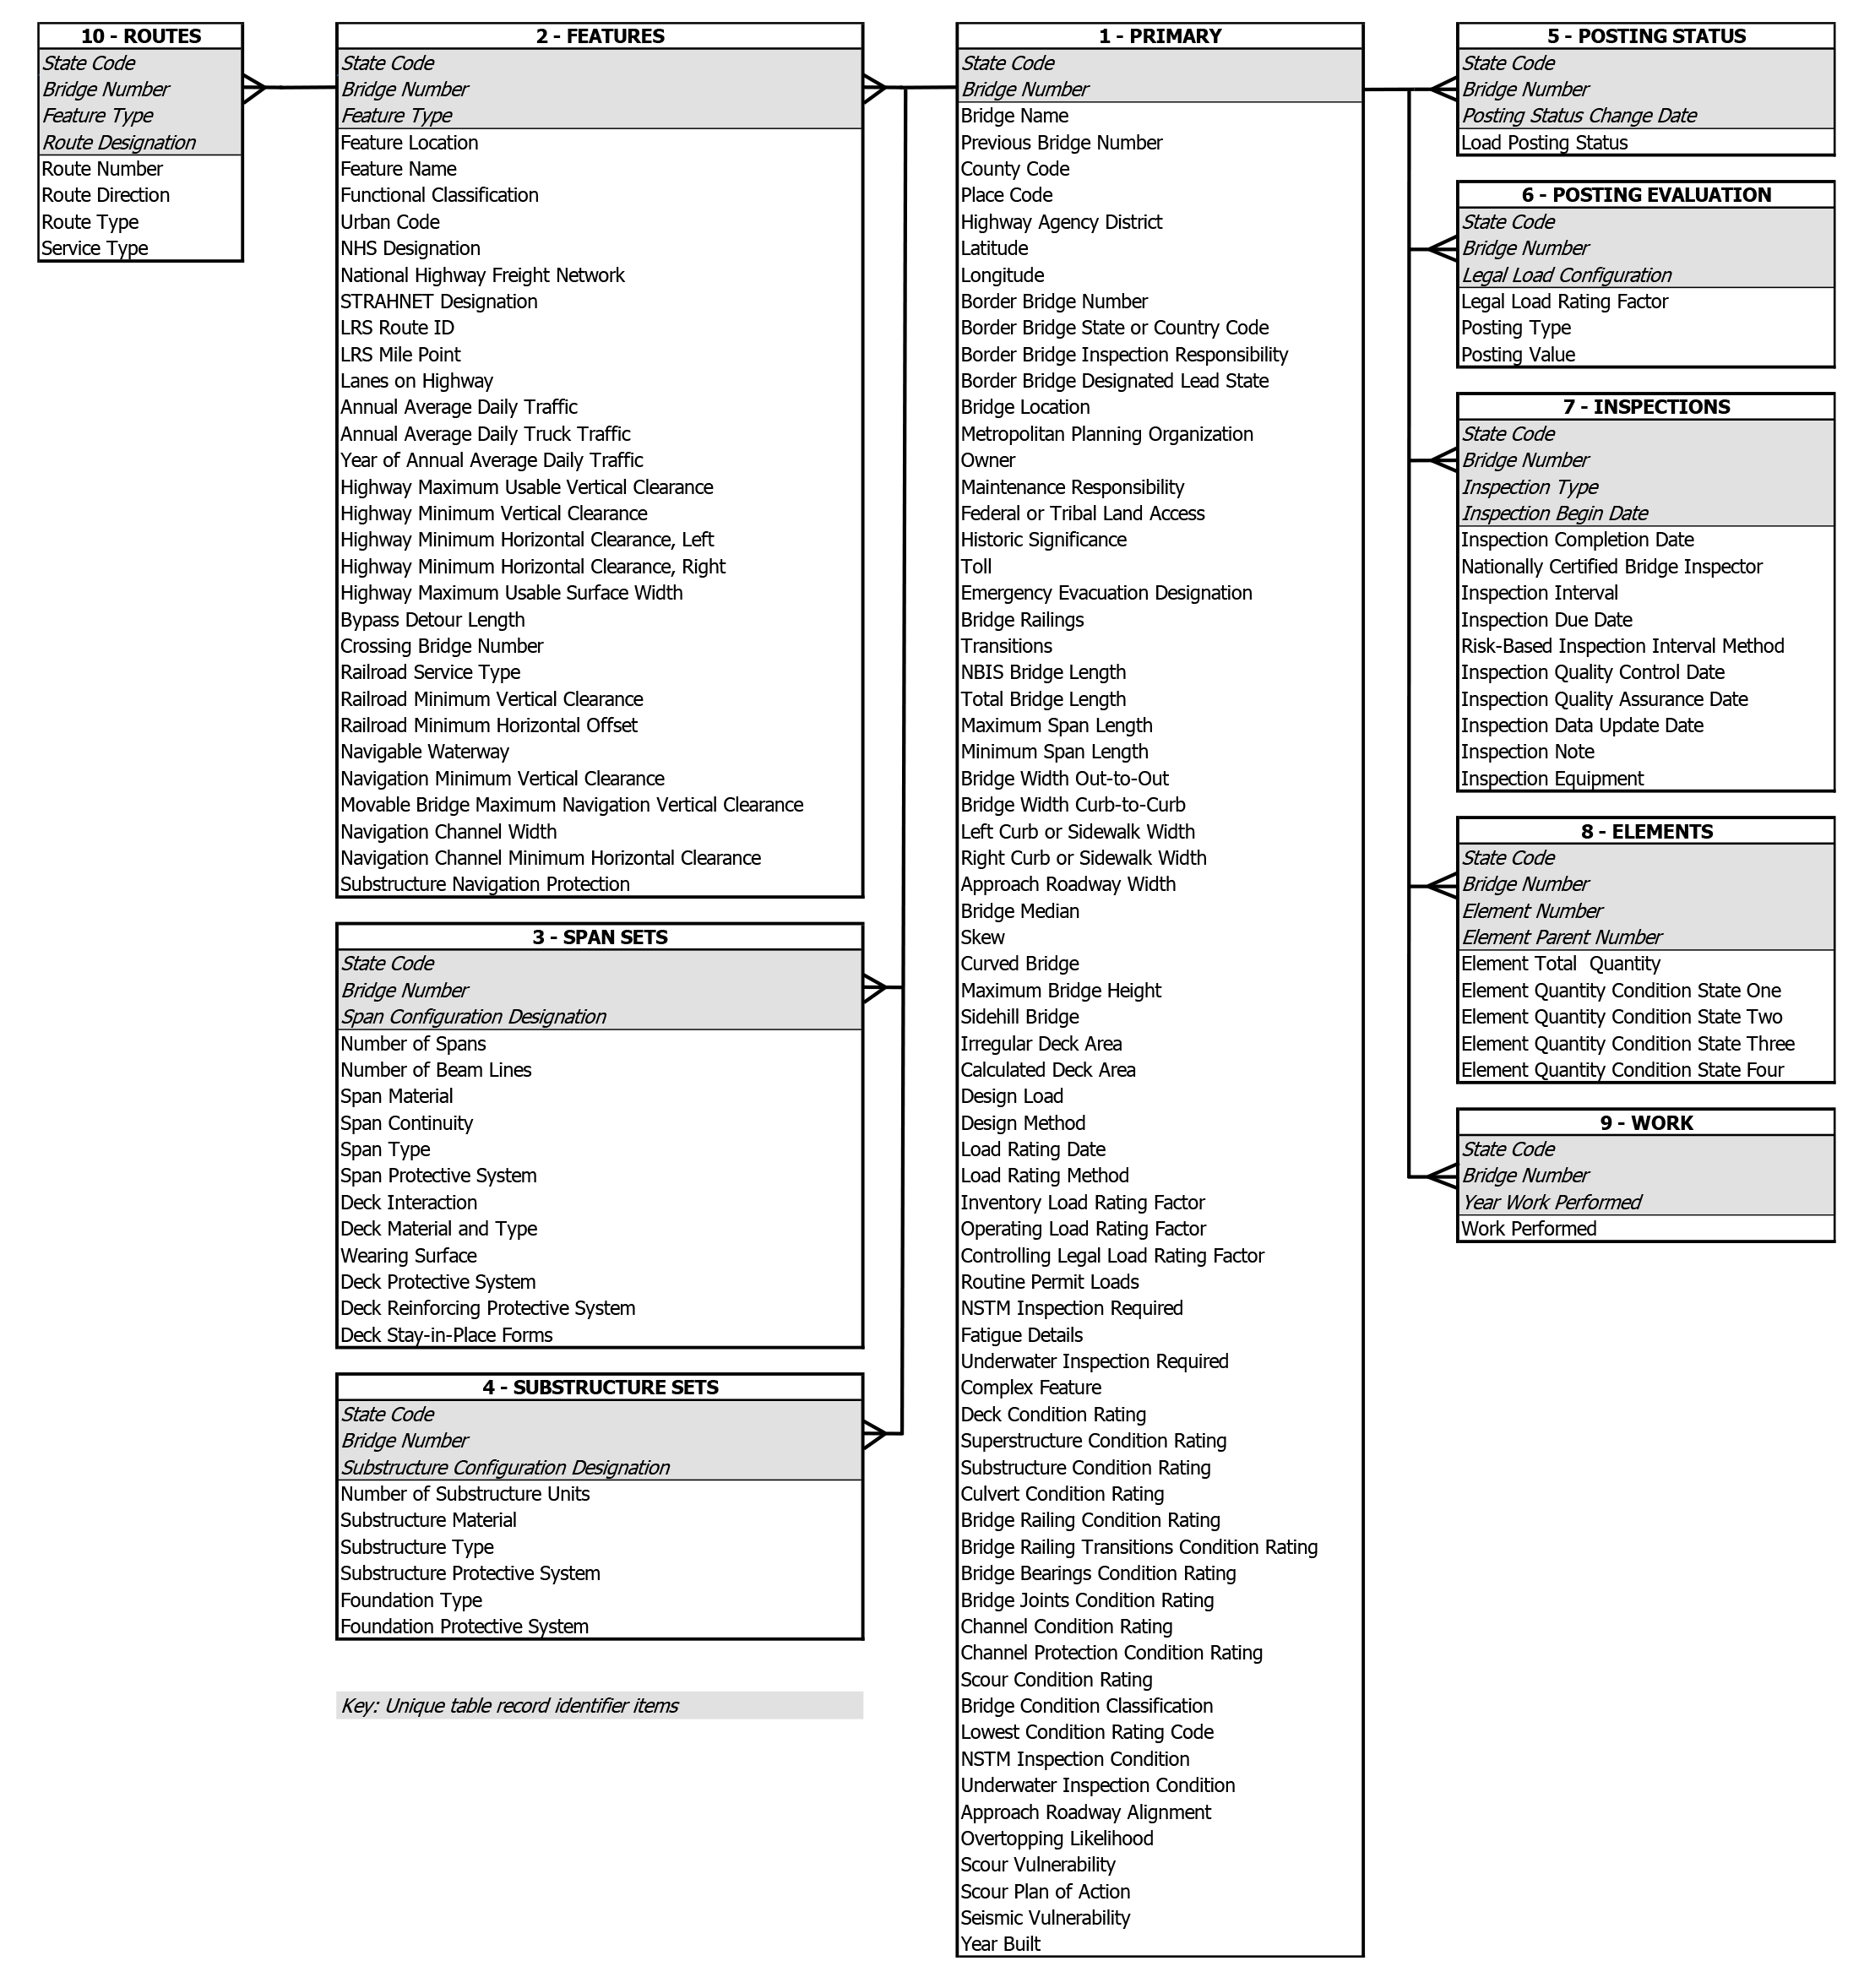

# Python Code to Extract Images from SNBI Document

This is how I pulled photos out of the SNBI Document, it's not perfect. Images are labeled `image#_#.png` where the first number is the page and the second is the sequence for that page. Images that didn't extract for whatever reason, are labeled as `fig_#.png` where the number is their figure number in the standard.

# Python Objects to Mirror Tables

In [ ]:
from __future__ import annotations


class SNBIRoutesDefinition:
    def __init__(self):
        self.PK_STATE_CODE: int | None = None  # 2 characters, no decimal, B.L.01
        self.PK_BRIDGE_NUMBER: str | None = None  # 15 characters, B.ID.01
        self.PK_FEATURE_TYPE: str | None = None  # 3 characters, B.F.01
        self.PK_ROUTE_DESIGNATION: str | None = None  # 3 characters, B.RT.01
        self.ROUTE_NUMBER: str | None = None  # 15 characters, B.RT.02
        self.ROUTE_DIRECTION: str | None = None  # 2 characters, B.RT.03
        self.ROUTE_TYPE: str | None = None  # 1 character, B.RT.04
        self.SERVICE_TYPE: str | None = None  # 1 character, B.RT.05

In [ ]:
class SNBIFeaturesDefinition:
    def __init__(self):
        self.PK_STATE_CODE: int | None = None  # 2 characters, no decimal, B.L.01
        self.PK_BRIDGE_NUMBER: str | None = None  # 15 characters, B.ID.01
        self.PK_FEATURE_TYPE: str | None = None  # 3 characters, B.F.01
        self.FEATURE_LOCATION: str | None = None  # 1 character, B.F.02
        self.FEATURE_NAME: str | None = None  # 300 characters, B.F.03
        self.FUNCTION_CLASSIFICATION: str | None = None  # 1 character, B.H.01
        self.URBAN_CODE: str | None = None  # 5 characters, B.H.02
        self.NHS_DESIGNATION: str | None = None  # 1 character, B.H.03
        self.NATIONAL_HIGHWAY_FREIGHT_NETWORK: str | None = None  # 1 character, B.H.04
        self.STRAHNET_DESIGNATION: str | None = None  # 1 character, B.H.05
        self.LRS_ROUTE_ID: str | None = None  # 120 characters, B.H.06
        self.LRS_MILE_POINT: float | None = (
            None  # 8 characters, 3 decimal places, B.H.07
        )
        self.LANES_ON_HIGHWAY: int | None = (
            None  # 2 characters, 0 decimal places, B.H.08
        )
        self.ANNUAL_AVERAGE_DAILY_TRAFFIC: int | None = (
            None  # 8 characters, 0 decimal places, B.H.09
        )
        self.ANNUAL_AVERAGE_DAILY_TRUCK_TRAFFIC: int | None = (
            None  # 8 characters, 0 decimal places, B.H.10
        )
        self.YEAR_OF_ANNUAL_AVERAGE_DAILY_TRAFFIC: int | None = (
            None  # 4 characters, 0 decimal places, B.H.11
        )
        self.HIGHWAY_MAXIMUM_USABLE_VERTICAL_CLEARANCE: float | None = (
            None  # 3 characters, 1 decimal place, B.H.12
        )
        self.HIGHWAY_MINIMUM_VERTICAL_CLEARANCE: float | None = (
            None  # 3 characters, 1 decimal place, B.H.13
        )
        self.HIGHWAY_MINIMUM_HORIZONTAL_CLEARANCE_LEFT: float | None = (
            None  # 3 characters, 1 decimal place, B.H.14
        )
        self.HIGHWAY_MINIMUM_HORIZONTAL_CLEARANCE_RIGHT: float | None = (
            None  # 3 characters, 1 decimal place, B.H.15
        )
        self.HIGHWAY_MAXIMUM_USABLE_SURFACE_WIDTH: float | None = (
            None  # 3 characters, 1 decimal place, B.H.12
        )
        self.BYPASS_DETOUR_LENGTH: int | None = None  # 3 characters, B.H.17
        self.CROSSING_BRIDGE_NUMBER: str | None = None  # 15 characters, B.H.18
        self.RAILROAD_SERVICE_TYPE: str | None = None  # 2 characters, B.RR.01
        self.RAILROAD_MINIMUM_VERTICAL_CLEARANCE: float | None = (
            None  # 3 characters, 1 decimal place, B.RR.02
        )
        self.RAILROAD_MINIMUM_HORIZONTAL_OFFSET: float | None = (
            None  # 3 characters, 1 decimal place, B.RR.03
        )
        self.NAVIGABLE_WATERWAY: str | None = None  # 1 character, B.N.01
        self.NAVIGATION_MINIMUM_VERTICAL_CLEARANCE: float | None = (
            None  # 4 characters, 1 decimal place, B.N.02
        )
        self.MOVABLE_BRIDGE_MAXIMUM_NAVIGATION_VERTICAL_CLEARANCE: float | None = (
            None  # 4 characters, 1 decimal place, B.N.03
        )
        self.NAVIGATION_CHANNEL_WIDTH: float | None = (
            None  # 5 characters, 1 decimal place, B.N.04
        )
        self.NAVIGATION_CHANNEL_MINIMUM_HORIZONTAL_CLEARANCE: float | None = (
            None  # 5 characters, 1 decimal, B.N.05
        )
        self.SUBSTRUCTURE_NAVIGATION_PROTECTION: str | None = (
            None  # 1 character, B.N.06
        )

In [ ]:
class SNBISpanSetsDefinition:
    def __init__(self):
        self.PK_STATE_CODE: int | None = None  # 2 characters, no decimal, B.L.01
        self.PK_BRIDGE_NUMBER: str | None = None  # 15 characters, B.ID.01
        self.PK_SPAN_CONFIGURATION_DESIGNATION: str | None = (
            None  # 3 characters, B.SP.01
        )
        self.NUMBER_OF_SPANS: int | None = None  # 4 characters, B.SP.02
        self.NUMBER_OF_BEAM_LINES: int | None = None  # 3 characters, B.SP.03
        self.SPAN_MATERIAL: int | None = None  # 3 characters, B.SP.04
        self.SPAN_CONTINUITY: str | None = None  # 1 characters, B.SP.05
        self.SPAN_TYPE: str | None = None  # 3 characters, B.SP.06
        self.SPAN_PROTECTIVE_SYSTEM: str | None = None  # 3 characters, B.SP.07
        self.DECK_INTERACTION: str | None = None  # 2 characters, B.SP.08
        self.DECK_MATERIAL_AND_TYPE: str | None = None  # 3 characters, B.SP.09
        self.WEARING_SURFACE: str | None = None  # 3 characters, B.SP.10
        self.DECK_PROTECTIVE_SYSTEM: str | None = None  # 3 characters, B.SP.11
        self.DECK_REINFORCING_PROTECTIVE_SYSTEM: str | None = (
            None  # 3 characters, B.SP.12
        )
        self.DECK_STAY_IN_PLACE_FORMS: str | None = None  # 3 characters, B.SP.13

In [ ]:
class SNBISubstructureSetsDefinition:
    def __init__(self):
        self.PK_STATE_CODE: int | None = None  # 2 characters, no decimal, B.L.01
        self.PK_BRIDGE_NUMBER: str | None = None  # 15 characters, B.ID.01
        self.PK_SUBSTRUCTURE_CONFIGURATION_DESIGNATION: str | None = (
            None  # 3 characters, B.SP.01
        )
        self.NUMBER_OF_SUBSTRUCTURE_UNITS: str | None = None  # 3 characters, B.SB.01
        self.SUBSTRUCTURE_MATERIAL: str | None = None  # 3 characters, B.SB.03
        self.SUBSTRUCTURE_TYPE: str | None = None  # 3 characters, B.SB.04
        self.SUBSTRUCTURE_PROTECTIVE_SYSTEM: str | None = None  # 3 characters, B.SB.05
        self.FOUNDATION_TYPE: str | None = None  # 3 characters, B.SB.06
        self.FOUNDATION_PROTECTIVE_SYSTEM: str | None = None  # 3 characters, B.SB.07

In [ ]:
class SNBIPrimaryValuesDefinition:
    def __init__(self):
        self.PK_STATE_CODE: int | None = None  # 2 characters, no decimal, B.L.01
        self.PK_BRIDGE_NUMBER: str | None = None  # 15 characters, B.ID.01
        self.BRIDGE_NAME: str | None = None  # 300 characters, B.ID.02
        self.PREVIOUS_BRIDGE_NUMBER: str | None = None  # 15 characters, B.ID.03
        self.COUNTY_CODE: int | None = None  # 3 characters, B.L.02
        self.PLACE_CODE: int | None = None  # 5 characters, B.L.03
        self.HIGHWAY_AGENCY_DISTRICT: str | None = None  # 2 characters, B.L.04
        self.LATITUDE: float | None = None  # 9 characters, 6 decimal places, B.L.05
        self.LONGITUDE: float | None = None  # 10 characters, 6 decimal places, B.L.06
        self.BORDER_BRIDGE_NUMBER: str | None = None  # 15 characters, B.L.07
        self.BORDER_BRIDGE_STATE_OR_COUNTY_CODE: str | None = (
            None  # 2 characters, B.L.08
        )
        self.BORDER_BRIDGE_INSPECTION_RESPONSIBILITY: str | None = (
            None  # 1 character, B.L.09
        )
        self.BORDER_BRIDGE_DESIGNATED_LEAD_STATE: int | None = (
            None  # 2 characters, no decimal, B.L.10
        )
        self.BRIDGE_LOCATION: str | None = None  # 300 characters, B.L.11
        self.METROPOLITAN_PLANNING_ORGANIZATION: str | None = (
            None  # 300 characters, B.L.12
        )
        self.OWNER: str | None = None  # 4 characters, B.CL.01
        self.MAINTENANCE_RESPONSIBILITY: str | None = None  # 4 characters, B.CL.02
        self.FEDERAL_OR_TRIBAL_LAND_ACCESS: str | None = None  # 30 characters, B.CL.03
        self.HISTORIC_SIGNIFICANCE: str | None = None  # 1 character, B.CL.04
        self.TOLL: str | None = None  # 1 character, B.CL.05
        self.EMERGENCY_EVACUATION_DESIGNATION: str | None = None  # 1 character, B.CL.06
        self.BRIDGE_RAILINGS: str | None = None  # 4 characters, B.RH.01
        self.TRANSITIONS: str | None = None  # 4 characters, B.RH.02
        self.NBIS_BRIDGE_LENGTH: float | None = (
            None  # 7 characters, 1 decimal place, B.G.01
        )
        self.TOTAL_BRIDGE_LENGTH: float | None = (
            None  # 7 characters, 1 decimal place, B.G.02
        )
        self.MAXIMUM_SPAN_LENGTH: float | None = (
            None  # 5 characters, 1 decimal place, B.G.03
        )
        self.MINIMUM_SPAN_LENGTH: float | None = (
            None  # 5 characters, 1 decimal place, B.G.04
        )
        self.BRIDGE_WIDTH_OUT_TO_OUT: float | None = (
            None  # 4 characters, 1 decimal place, B.G.05
        )
        self.BRIDGE_WIDTH_CURB_TO_CURB: float | None = (
            None  # 4 characters, 1 decimal place, B.G.06
        )
        self.LEFT_CURB_OR_SIDEWALK_WIDTH: float | None = (
            None  # 3 characters, 1 decimal place, B.G.07
        )
        self.RIGHT_CURB_OR_SIDEWALK_WIDTH: float | None = (
            None  # 3 characters, 1 decimal place, B.G.08
        )
        self.APPROACH_ROADWAY_WIDTH: float | None = (
            None  # 4 characters, 1 decimal places, B.G. 09
        )
        self.BRIDGE_MEDIAN: str | None = None  # 1 character, B.G.10
        self.SKEW: int | None = None  # 2 characters, 0 decimal places, B.G.11
        self.CURVED_BRIDGE: str | None = None  # 2 characters, B.G.12
        self.MAXIMUM_BRIDGE_HEIGHT: int | None = (
            None  # 4 characters, 0 decimal places, B.G.13
        )
        self.SIDEHILL_BRIDGE: str | None = None  # 1 character, B.G.14
        self.IRREGULAR_DECK_AREA: float | None = (
            None  # 10 characters, 1 decimal, B.G.15
        )
        self.CALCULATED_DECK_AREA: float | None = (
            None  # 10 characters, 1 decimal, B.G.16
        )
        self.DESIGN_LOAD: str | None = None  # 8 characters, B.LR.01
        self.DESIGN_METHOD: str | None = None  # 4 characters, B.LR.02
        self.LOAD_RATING_DATE: str | None = (
            None  # 8 characters, B.LR.03 //TODO - Switch to YYYYMMDD datetime format
        )
        self.LOAD_RATING_METHOD: str | None = None  # 4 characters, B.LR.04
        self.INVENTORY_LOAD_RATING_FACTOR: float | None = (
            None  # 4 characters, 2 decimals, B.LR.05
        )
        self.OPERATING_LOAD_RATING_FACTOR: float | None = (
            None  # 4 characters, 2 decimals, B.LR.06
        )
        self.CONTROLLING_LEGAL_LOAD_RATING_FACTOR: float | None = (
            None  # 4 characters, 2 decimals, B.LR.07
        )
        self.ROUTINE_PERMIT_LOADS: str | None = None  # 1 character, B.LR.08
        self.NSTM_INSPECTION_REQUIRED: str | None = None  # 1 character, B.IR.01
        self.FATIGUE_DETAILS: str | None = None  # 1 character, B.IR.01
        self.FATIGUE_DETAILS: str | None = None  # 1 character, B.IR.02
        self.UNDERWATER_INSPECTION_REQUIRED: str | None = None  # 1 character, B.IR.03
        self.COMPLEX_FEATURE: str | None = None  # 1 character, B.IR.04
        self.DECK_CONDITION_RATING: str | None = None  # 1 character, B.C.01
        self.SUPERSTRUCTURE_CONDITION_RATING: str | None = None  # 1 character, B.C.02
        self.SUBSTRUCTURE_CONDITION_RATING: str | None = None  # 1 character, B.C.03
        self.CULVERT_CONDITION_RATING: str | None = None  # 1 character, B.C.04
        self.BRIDGE_RAILING_CONDITION_RATING: str | None = None  # 1 character, B.C.05
        self.BRIDGE_RAILING_TRANSITIONS_CONDITION_RATING: str | None = (
            None  # 1 character, B.C.06
        )
        self.BRIDGE_BEARINGS_CONDITION_RATING: str | None = None  # 1 character, B.C.07
        self.BRIDGE_JOINTS_CONDITION_RATING: str | None = None  # 1 character, B.C.08
        self.CHANNEL_CONDITION_RATING: str | None = None  # 1 character, B.C.09
        self.CHANNEL_PROTECTION_CONDITION_RATING: str | None = (
            None  # 1 character, B.C.10
        )
        self.SCOUR_CONDITION_RATING: str | None = None  # 1 character, B.C.11
        self.BRIDGE_CONDITION_CLASSIFICATION: str | None = None  # 1 character, B.C.12
        self.LOWEST_CONDITION_RATING_CODE: str | None = None  # 1 character, B.C.13
        self.NSTM_INSPECTION_CONDITION: str | None = None  # 1 character, B.C.14
        self.UNDERWATER_INSPECTION_CONDITION: str | None = None  # 1 character, B.C.15
        self.APPROACH_ROADWAY_ALIGNMENT: str | None = None  # 1 character, B.AP.01
        self.OVERTOPPING_LIKELIHOOD: str | None = None  # 1 character, B.AP.02
        self.SCOUR_VULNERABILITY: str | None = None  # 1 character, B.AP.03
        self.SCOUR_PLAN_OF_ACTION: str | None = None  # 1 character, B.AP.04
        self.SEISMIC_VULNERABILTIY: str | None = None  # 1 character, B.AP.05
        self.YEAR_BUILT: int | None = None  # 4 characters, no decimals, B.W.01

In [ ]:
class SNBIPostingStatusDefinition:
    def __init__(self):
        self.PK_STATE_CODE: int | None = None  # 2 characters, no decimal, B.L.01
        self.PK_BRIDGE_NUMBER: str | None = None  # 15 characters, B.ID.01
        self.PK_POSTING_STATUS_CHANGE_DATE: str | None = None  # 15 characters, B.ID.01
        self.LOAD_POSTING_STATUS: str | None = None  # 2 characters, B.PS.01

In [ ]:
class SNBIPostingEvaluationDefinition:
    def __init__(self):
        self.PK_STATE_CODE: int | None = None  # 2 characters, no decimal, B.L.01
        self.PK_BRIDGE_NUMBER: str | None = None  # 15 characters, B.ID.01
        self.PK_LEGAL_LOAD_CONFIGURATION: str | None = None  # 3 characters, B.EP.01
        self.LEGAL_LOAD_RATING_FACTOR: float | None = (
            None  # 4 characters, 2 decimals, B.EP.02
        )
        self.POSTING_TYPE: str | None = None  # 1 character, B.EP.03
        self.POSTING_VALUE: int | None = None  # 2 characters, B.EP.04

In [ ]:
class SNBIInspectionsDefinition:
    def __init__(self):
        self.PK_STATE_CODE: int | None = None  # 2 characters, no decimal, B.L.01
        self.PK_BRIDGE_NUMBER: str | None = None  # 15 characters, B.ID.01
        self.PK_INSPECTION_TYPE: str | None = None  # 1 character, B.IE.01
        self.PK_INSPECTION_BEGIN_DATE: str | None = (
            None  # 8 characters, B.IE.02 //TODO - Switch to YYYYMMDD datetime format
        )
        self.INSPECTION_COMPLETION_DATE: str | None = (
            None  # 8 characters, B.IE.03 //TODO - Switch to YYYYMMDD datetime format
        )
        self.NATIONALLY_CERTIFIED_BRIDGE_INSPECTOR: str | None = (
            None  # 15 characters, B.IE.04
        )
        self.INSPECTION_INTERVAL: int | None = None  # 2 characters, B.IE.05
        self.INSPECTION_DUE_DATE: str | None = (
            None  # 8 characters, B.IE.06 //TODO - Switch to YYYYMMDD datetime format
        )
        self.RISK_BASED_INSPECTION_INTERVAL_METHOD: str | None = (
            None  # 1 character, B.IE.07
        )
        self.INSPECTION_QUALITY_CONTROL_DATE: str | None = (
            None  # 8 characters, B.IE.08 //TODO - Switch to YYYYMMDD datetime format
        )
        self.INSPECTION_QUALITY_ASSURANCE_DATE: str | None = (
            None  # 8 characters, B.IE.09 //TODO - Switch to YYYYMMDD datetime format
        )
        self.INSPECTION_DATA_UPDATE_DATE: str | None = (
            None  # 8 characters, B.IE.10 //TODO - Switch to YYYYMMDD datetime format
        )
        self.INSPECTION_NOTE: str | None = None  # 300 characters, B.IE.11
        self.INSPECTION_EQUIPMENT: str | None = None  # 120 characters, B.IE.12

In [ ]:
class SNBIElementsDefinition:
    def __init__(self):
        self.PK_STATE_CODE: int | None = None  # 2 characters, no decimal, B.L.01
        self.PK_BRIDGE_NUMBER: str | None = None  # 15 characters, B.ID.01
        self.PK_ELEMENT_NUMBER: int | None = None  # 4 characters, B.E.01
        self.PK_ELEMENT_PARENT_NUMBER: int | None = None  # 4 characters, B.E.02
        self.ELEMENT_TOTAL_QUANTITY: int | None = None  # 8 characters, B.E.03
        self.ELEMENT_QUANTITY_CONDITION_STATE_ONE: int | None = (
            None  # 8 characters, B.CS.01
        )
        self.ELEMENT_QUANTITY_CONDITION_STATE_TWO: int | None = (
            None  # 8 characters, B.CS.02
        )
        self.ELEMENT_QUANTITY_CONDITION_STATE_THREE: int | None = (
            None  # 8 characters, B.CS.03
        )
        self.ELEMENT_QUANTITY_CONDITION_STATE_FOUR: int | None = (
            None  # 8 characters, B.CS.04
        )

In [ ]:
class SNBIWorkDefinition:
    def __init__(self):
        self.PK_STATE_CODE: int | None = None  # 2 characters, no decimal, B.L.01
        self.PK_BRIDGE_NUMBER: str | None = None  # 15 characters, B.ID.01
        self.PK_YEAR_WORK_PERFORMED: int | None = None  # 4 characters, B.W.02
        self.WORK_PERFORMED: str | None = None  # 120 characters, B.W.03

In [ ]:
class BorderBridgeDefinition:
    def __init__(self):
        self.BRIDGE_NUMBER: str | None = None  # 15 character, B.ID.01
        self.PREVIOUS_BRIDGE_NUMBER: str | None = None  # 15 characters, B.ID.03
        self.STATE_CODE: int | None = None  # 2 characters, no decimal, B.L.01
        self.COUNTY_CODE: int | None = None  # 3 characters, B.L.02
        self.PLACE_CODE: int | None = None  # 5 characters, B.L.03
        self.HIGHWAY_AGENCY_DISTRICT: str | None = None  # 2 characters, B.L.04
        self.BORDER_BRIDGE_NUMBER: str | None = None  # 15 characters, B.L.07
        self.BORDER_BRIDGE_STATE_OR_COUNTRY_CODE: str | None = (
            None  # 2 characters, B.L.08
        )
        self.BORDER_BRIDGE_INSPECTION_RESPONSIBILITY: str | None = (
            None  # 1 character, B.L.09
        )
        self.BORDER_BRIDGE_DESIGNATED_LEAD_STATE: int | None = (
            None  # 2 characters, no decimal, B.L.10
        )
        self.METROPOLITAN_PLANNING_ORGANIZATION: str | None = (
            None  # 300 characters, B.L.12
        )
        self.FEATURE_TYPE: str | None = None  # 3 characters, B.F.01
        self.FEATURE_LOCATION: str | None = None  # 1 character, B.F.02
        self.FEATURE_NAME: str | None = None  # 300 characters, B.F.03
        self.ROUTE_DESIGNATION: str | None = None  # 3 characters, B.RT.01
        self.ROUTE_NUMBER: str | None = None  # 15 characters, B.RT.02
        self.ROUTE_DIRECTION: str | None = None  # 2 characters, B.RT.03
        self.ROUTE_TYPE: str | None = None  # 1 character, B.RT.04
        self.SERVICE_TYPE: str | None = None  # 1 character, B.RT.05
        self.NHS_DESIGNATION: str | None = None  # 1 character, B.H.03
        self.LRS_ROUTE_ID: str | None = None  # 120 characters, B.H.06
        self.LRS_MILE_POINT: float | None = (
            None  # 8 characters, 3 decimal places, B.H.07
        )
        self.CROSSING_BRIDGE_NUMBER: str | None = None  # 15 characters, B.H.18

In [ ]:
# Previous defintions that may no longer be needed (Added to CivilPy)
ohio_counties = {
    "ADAMS": "ADA",
    "ALLEN": "ALL",
    "ASHLAND": "ASD",
    "ASHTABULA": "ATB",
    "ATHENS": "ATH",
    "AUGLAIZE": "AUG",
    "BELMONT": "BEL",
    "BROWN": "BRO",
    "BUTLER": "BUT",
    "CARROLL": "CAR",
    "CHAMPAIGN": "CHP",
    "CLARK": "CLA",
    "CLERMONT": "CLE",
    "CLINTON": "CLI",
    "COLUMBIANA": "COL",
    "COSHOCTON": "COS",
    "CRAWFORD": "CRA",
    "CUYAHOGA": "CUY",
    "DARKE": "DAR",
    "DEFIANCE": "DEF",
    "DELAWARE": "DEL",
    "ERIE": "ERI",
    "FAIRFIELD": "FAI",
    "FAYETTE": "FAY",
    "FRANKLIN": "FRA",
    "FULTON": "FUL",
    "GALLIA": "GAL",
    "GEAUGA": "GEA",
    "GREENE": "GRE",
    "GUERNSEY": "GUE",
    "HAMILTON": "HAM",
    "HANCOCK": "HAN",
    "HARDIN": "HAR",
    "HARRISON": "HAS",
    "HENRY": "HEN",
    "HIGHLAND": "HIG",
    "HOCKING": "HOC",
    "HOLMES": "HOL",
    "HURON": "HUR",
    "JACKSON": "JAC",
    "JEFFERSON": "JEF",
    "KNOX": "KNO",
    "LAKE": "LAK",
    "LAWRENCE": "LAW",
    "LICKING": "LIC",
    "LOGAN": "LOG",
    "LORAIN": "LOR",
    "LUCAS": "LUC",
    "MADISON": "MAD",
    "MAHONING": "MAH",
    "MARION": "MAR",
    "MEDINA": "MED",
    "MEIGS": "MEG",
    "MERCER": "MER",
    "MIAMI": "MIA",
    "MONROE": "MOE",
    "MONTGOMERY": "MOT",
    "MORGAN": "MRG",
    "MORROW": "MRW",
    "MUSKINGUM": "MUS",
    "NOBLE": "NOB",
    "OTTAWA": "OTT",
    "PAULDING": "PAU",
    "PERRY": "PER",
    "PICKAWAY": "PIC",
    "PIKE": "PIK",
    "PORTAGE": "POR",
    "PREBLE": "PRE",
    "PUTNAM": "PUT",
    "RICHLAND": "RIC",
    "ROSS": "ROS",
    "SANDUSKY": "SAN",
    "SCIOTO": "SCI",
    "SENECA": "SEN",
    "SHELBY": "SHE",
    "STARK": "STA",
    "SUMMIT": "SUM",
    "TRUMBULL": "TRU",
    "TUSCARAWAS": "TUS",
    "UNION": "UNI",
    "VAN WERT": "VAN",
    "VINTON": "VIN",
    "WARREN": "WAR",
    "WASHINGTON": "WAS",
    "WAYNE": "WAY",
    "WILLIAMS": "WIL",
    "WOOD": "WOO",
    "WYANDOT": "WYA",
}

In [ ]:
NBIS_state_codes = {
    "014": "Alabama",
    "308": "Montana",
    "020": "Alaska",
    "317": "Nebraska",
    "049": "Arizona",
    "329": "Nevada",
    "056": "Arkansas",
    "331": "New Hampshire",
    "069": "Californ",
    "342": "New Jersey",
    "088": "Colorado",
    "356": "New Mexico",
    "091": "Connecti",
    "362": "New York",
    "103": "Delaware",
    "374": "North Carolina",
    "113": "District of Columbia",
    "388": "North Dakota",
    "124": "Florida",
    "395": "Ohio",
    "134": "Georgia",
    "406": "Oklahoma",
    "159": "Hawaii",
    "410": "Oregon",
    "160": "Idaho",
    "423": "Pennsylvania",
    "175": "Illinois",
    "441": "Rhode Island",
    "185": "Indiana",
    "454": "South Carolina",
    "197": "Iowa",
    "468": "South Dakota",
    "207": "Kansas",
    "474": "Tennessee",
    "214": "Kentucky",
    "486": "Texas",
    "226": "Louisiana",
    "498": "Utah",
    "231": "Maine",
    "501": "Vermont",
    "243": "Maryland",
    "513": "Virginia",
    "251": "Massachusetts",
    "530": "Washington",
    "265": "Michigan",
    "543": "West Virginia",
    "275": "Minnesota",
    "555": "Wisconsin",
    "284": "Mississippi",
    "568": "Wyoming",
    "297": "Missouri",
    "721": "Puerto Rico",
}

In [ ]:
url = "https://daneparks.com"

In [ ]:
import qrcode
from qrcode.image.styledpil import StyledPilImage
from qrcode.image.styles.moduledrawers.pil import RoundedModuleDrawer
from qrcode.image.styles.colormasks import RadialGradiantColorMask

# Set up the QRCode
qr = qrcode.QRCode(error_correction=qrcode.constants.ERROR_CORRECT_L)
qr.add_data(url)
qr.make(fit=True)

# Generate QR code images with advanced styles
img_1 = qr.make_image(image_factory=StyledPilImage, module_drawer=RoundedModuleDrawer())
img_2 = qr.make_image(
    image_factory=StyledPilImage, color_mask=RadialGradiantColorMask()
)

# Save the images
img_1.save("qr_code_1.png")
img_2.save("qr_code_2.png")